In [ ]:
pip install scikeras

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 54.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
from keras.src import optimizers
from keras.src.utils import plot_model
from keras.src.models import Sequential, Model
from keras.src.layers.convolutional.conv1d import Conv1D
from keras.src.layers.pooling.max_pooling1d import MaxPooling1D
from keras.src.layers import Dense, LSTM, RepeatVector, TimeDistributed, Flatten
from keras.src import metrics
from keras.layers import Input
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date
import sklearn
from sklearn.model_selection import train_test_split

import math
from sklearn.preprocessing import MinMaxScaler

from datetime import datetime as dt, date, timedelta
import pickle
# from meteostat import Point, Daily

In [ ]:
# data = pd.read_csv('/content/preprocessed_main_data_dki1_kemayoran.csv')
data = pd.read_csv('/content/preprocessed_main_data_dki1_kemayoran_v2.csv', sep=';')
data = data.set_index('tanggal')
data.sort_index(inplace=True)
data

,pm10,pm25,so2,co,o3,no2,Tavg,RH_avg,RR,ss,ff_avg,DDD_CAR_cos,DDD_CAR_sin
tanggal,,,,,,,,,,,,,
2023-01-01,44.0,55.0,47.0,10.0,24.0,9.0,26.3,87.0,14.5,0.0,1.0,0.000000e+00,0.000000
2023-01-02,32.0,43.0,52.0,9.0,24.0,8.0,27.5,81.0,31.5,0.7,2.0,7.071068e-01,-0.707107
2023-01-03,31.0,35.0,49.0,9.0,12.0,7.0,26.6,82.0,0.5,0.0,1.0,0.000000e+00,0.000000
2023-01-04,30.0,47.0,53.0,11.0,15.0,9.0,26.4,86.0,2.4,2.1,1.0,0.000000e+00,0.000000
2023-01-05,38.0,50.0,50.0,13.0,26.0,11.0,27.4,83.0,35.3,4.9,2.0,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,53.0,83.0,12.0,10.0,11.0,36.0,29.2,78.0,7.5,1.2,2.0,0.000000e+00,0.000000
2024-12-28,64.0,101.0,14.0,9.0,11.0,35.0,30.0,70.0,0.6,3.8,2.0,0.000000e+00,0.000000
2024-12-29,51.0,21.0,13.0,10.0,13.0,35.0,29.7,73.0,0.0,3.0,1.0,0.000000e+00,0.000000


In [ ]:
WINDOW_SIZE = 7
HORIZON = 7

scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

In [ ]:
# x_temp = []
# y_temp = []

# for i in range(len(data) - WINDOW_SIZE - HORIZON + 1):
#     x_temp.append(data[i:i+WINDOW_SIZE])
#     y_temp.append(data[i+WINDOW_SIZE:i+WINDOW_SIZE + HORIZON])

# training_data_len_temp = math.ceil(len(x_temp)* 0.80)

# #splitting train
# x_train_temp = x_temp[:training_data_len_temp]
# y_train_temp = y_temp[:training_data_len_temp]

# # Val set
# val_test_len_temp = len(x_temp[training_data_len_temp:])
# val_len_temp = math.ceil(val_test_len_temp/2)

# x_val_temp = x_temp[training_data_len_temp: training_data_len_temp+val_len_temp]
# y_val_temp = y_temp[training_data_len_temp: training_data_len_temp+val_len_temp]

# # Test set
# x_test_temp = x_temp[training_data_len_temp+val_len_temp: ]
# y_test_temp = y_temp[training_data_len_temp+val_len_temp: ]

In [ ]:
# train = 92
# val   = 4
# test  = 4
# feats = polutan + meteorologi

features = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'Tavg', 'RH_avg', 'RR','ss', 'ff_avg', 'DDD_CAR_cos', 'DDD_CAR_sin']

targets = ['pm25']

data_x = data[features]
data_y = data[targets]

data_x_scaled = scaler_x.fit_transform(data_x)
data_y_scaled = scaler_y.fit_transform(data_y)

X = []
y = []

for i in range(len(data) - WINDOW_SIZE - HORIZON + 1):
    X.append(data_x_scaled[i:i+WINDOW_SIZE])
    y.append(data_y_scaled[i+WINDOW_SIZE:i+WINDOW_SIZE + HORIZON])

training_data_len = math.ceil(len(X)* 0.92)

#splitting train
x_train = X[:training_data_len]
y_train = y[:training_data_len]

# Val set
val_test_len = len(X[training_data_len:])
val_len = math.ceil(val_test_len/2)

x_val = X[training_data_len: training_data_len+val_len]
y_val = y[training_data_len: training_data_len+val_len]

# Test set
x_test = X[training_data_len+val_len: ]
y_test = y[training_data_len+val_len: ]

# Reshaping
x_train, y_train = np.array(x_train), np.array(y_train)

x_val, y_val = np.array(x_val), np.array(y_val)

x_test, y_test = np.array(x_test), np.array(y_test)

y_train = y_train.reshape((y_train.shape[0], y_train.shape[1]))
y_val = y_val.reshape((y_val.shape[0], y_val.shape[1]))
y_test = y_test.reshape((y_test.shape[0], y_test.shape[1]))

In [ ]:
# prompt: code to save scaler_x, scaler_y to local

# Save the scalers
with open('scaler_x.pkl', 'wb') as f:
    pickle.dump(scaler_x, f)

with open('scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

print("Scalers saved successfully.")


Scalers saved successfully.


In [ ]:
y_train.shape, y_val.shape, y_test.shape
# ((575, 7, 1), (72, 7, 1), (71, 7, 1))

((661, 7), (29, 7), (28, 7))

In [ ]:
scaler_y.inverse_transform(y_test)

array([[ 42.,  32.,  40.,  65.,  52.,  31.,  45.],
       [ 32.,  40.,  65.,  52.,  31.,  45.,  26.],
       [ 40.,  65.,  52.,  31.,  45.,  26.,  47.],
       [ 65.,  52.,  31.,  45.,  26.,  47., 103.],
       [ 52.,  31.,  45.,  26.,  47., 103.,  67.],
       [ 31.,  45.,  26.,  47., 103.,  67.,  69.],
       [ 45.,  26.,  47., 103.,  67.,  69.,  56.],
       [ 26.,  47., 103.,  67.,  69.,  56.,  26.],
       [ 47., 103.,  67.,  69.,  56.,  26.,  40.],
       [103.,  67.,  69.,  56.,  26.,  40.,  52.],
       [ 67.,  69.,  56.,  26.,  40.,  52.,  40.],
       [ 69.,  56.,  26.,  40.,  52.,  40.,  40.],
       [ 56.,  26.,  40.,  52.,  40.,  40.,  48.],
       [ 26.,  40.,  52.,  40.,  40.,  48.,  37.],
       [ 40.,  52.,  40.,  40.,  48.,  37.,  67.],
       [ 52.,  40.,  40.,  48.,  37.,  67.,  35.],
       [ 40.,  40.,  48.,  37.,  67.,  35.,  46.],
       [ 40.,  48.,  37.,  67.,  35.,  46.,  53.],
       [ 48.,  37.,  67.,  35.,  46.,  53.,  80.],
       [ 37.,  67.,  35.,  46.,

In [ ]:
y_train

array([[0.34821429, 0.25892857, 0.30357143, ..., 0.52678571, 0.60714286,
        0.53571429],
       [0.25892857, 0.30357143, 0.49107143, ..., 0.60714286, 0.53571429,
        0.41964286],
       [0.30357143, 0.49107143, 0.52678571, ..., 0.53571429, 0.41964286,
        0.26785714],
       ...,
       [0.60714286, 0.65178571, 0.58035714, ..., 0.60714286, 0.6875    ,
        0.6875    ],
       [0.65178571, 0.58035714, 0.67857143, ..., 0.6875    , 0.6875    ,
        0.53571429],
       [0.58035714, 0.67857143, 0.60714286, ..., 0.6875    , 0.53571429,
        0.44642857]])

In [ ]:
scaler_y.inverse_transform(y_train)

array([[49., 39., 44., ..., 69., 78., 70.],
       [39., 44., 65., ..., 78., 70., 57.],
       [44., 65., 69., ..., 70., 57., 40.],
       ...,
       [78., 83., 75., ..., 78., 87., 87.],
       [83., 75., 86., ..., 87., 87., 70.],
       [75., 86., 78., ..., 87., 70., 60.]])

# Define Evaluate Error

In [ ]:
from math import sqrt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred):
  y_true, y_pred = np.array(y_true), np.array(y_pred)
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_preds(y_true, y_pred):
  y_pred = y_pred.reshape(y_pred.shape[0], -1)
  y_true = y_true.reshape(y_true.shape[0], -1)
  mape = mean_absolute_percentage_error(y_true, y_pred)

  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = sqrt(mse)

  return {
          "Mean Squared Error: ": mse,
          "Mean Absolute Error: ": mae,
          "Root Mean Absolute Error: ": rmse,
          "Mean Absolute Percentage Error: ": mape
          }

# CNN Only

## model 1 (64)

In [ ]:
lr = 0.0003

model_cnn_1 = Sequential()
model_cnn_1.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_1.add(Flatten())
model_cnn_1.add(Dense(7))
model_cnn_1.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 7, 64)          │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,039 (15.78 KB)

 Trainable params: 4,039 (15.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_1.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.3693 - mean_absolute_error: 0.5150 - mean_absolute_percentage_error: 89.8284 - root_mean_squared_error: 0.6013 - val_loss: 0.0639 - val_mean_absolute_error: 0.2082 - val_mean_absolute_percentage_error: 45.7747 - val_root_mean_squared_error: 0.2529
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0440 - mean_absolute_error: 0.1659 - mean_absolute_percentage_error: 43.2118 - root_mean_squared_error: 0.2097 - val_loss: 0.0408 - val_mean_absolute_error: 0.1650 - val_mean_absolute_percentage_error: 37.0244 - val_root_mean_squared_error: 0.2020
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0306 - mean_absolute_error: 0.1391 - mean_absolute_percentage_error: 33.3265 - root_mean_squared_error: 0.1749 - val_loss: 0.0393 - val_mean_absolute_error: 0.1666 - val_mean_absolute_percentage_error: 37.1416 - val_root_mean_squared_error: 0.1982
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0227 - mean_

In [ ]:
y_pred = model_cnn_1.predict(x_test)
evaluation_cnn_1 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


{'Mean Squared Error: ': np.float64(532.042162602127),
 'Mean Absolute Error: ': np.float64(18.05839681138798),
 'Root Mean Absolute Error: ': 23.066039161549323,
 'Mean Absolute Percentage Error: ': np.float64(40.3891448863133)}

In [ ]:
loss, mae, mape, rmse = model_cnn_1.evaluate(x_test, y_test)
print("model cnn 1")
print("Mean Absolute Error:", mae)
print("Mean Square Error:", loss)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0424 - mean_absolute_error: 0.1612 - mean_absolute_percentage_error: 3458854.5000 - root_mean_squared_error: 0.2059
model cnn 1
Mean Absolute Error: 0.16123569011688232
Mean Square Error: 0.04241407662630081
Mean Absolute Percentage Error: 3458854.5
Root Mean Squared Error: 0.20594678819179535


## model 2 (128 & 32)
 erornya tinggi

In [ ]:
lr = 0.0003

model_cnn_2 = Sequential()
model_cnn_2.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_2.add(Conv1D(filters=32, kernel_size=1, activation='relu'))
model_cnn_2.add(Flatten())
model_cnn_2.add(Dense(7))
model_cnn_2.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 7, 128)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,495 (29.28 KB)

 Trainable params: 7,495 (29.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_2.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.3470 - mean_absolute_error: 0.5456 - mean_absolute_percentage_error: 96.1147 - root_mean_squared_error: 0.5877 - val_loss: 0.1033 - val_mean_absolute_error: 0.2620 - val_mean_absolute_percentage_error: 48.8594 - val_root_mean_squared_error: 0.3214
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0801 - mean_absolute_error: 0.2336 - mean_absolute_percentage_error: 48.0839 - root_mean_squared_error: 0.2810 - val_loss: 0.0504 - val_mean_absolute_error: 0.1915 - val_mean_absolute_percentage_error: 46.0369 - val_root_mean_squared_error: 0.2244
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0288 - mean_absolute_error: 0.1347 - mean_absolute_percentage_error: 33.4147 - root_mean_squared_error: 0.1696 - val_loss: 0.0466 - val_mean_absolute_error: 0.1855 - val_mean_absolute_percentage_error: 44.5780 - val_root_mean_squared_error: 0.2159
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0211 - mean_abs

In [ ]:
y_pred = model_cnn_2.predict(x_test)

evaluation_cnn_2 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


{'Mean Squared Error: ': np.float64(522.863172200329),
 'Mean Absolute Error: ': np.float64(18.375318760774572),
 'Root Mean Absolute Error: ': 22.866201525402705,
 'Mean Absolute Percentage Error: ': np.float64(41.28086729600959)}

In [ ]:
loss, mae, mape, rmse = model_cnn_2.evaluate(x_test, y_test)
print("model cnn 2")
print("Mean Absolute Error:", mae)
print("Mean Square Error:", loss)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0417 - mean_absolute_error: 0.1641 - mean_absolute_percentage_error: 4078386.0000 - root_mean_squared_error: 0.2042
model cnn 2
Mean Absolute Error: 0.16406536102294922
Mean Square Error: 0.04168232902884483
Mean Absolute Percentage Error: 4078386.0
Root Mean Squared Error: 0.20416250824928284


## model 3 (64 64)

In [ ]:
lr = 0.0003

model_cnn_3 = Sequential()
model_cnn_3.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_3.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_3.add(Flatten())
model_cnn_3.add(Dense(7))
model_cnn_3.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_3.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 7, 64)          │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 7, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,199 (32.03 KB)

 Trainable params: 8,199 (32.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_3.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1771 - mean_absolute_error: 0.3533 - mean_absolute_percentage_error: 65.7290 - root_mean_squared_error: 0.4128 - val_loss: 0.0814 - val_mean_absolute_error: 0.2482 - val_mean_absolute_percentage_error: 60.5633 - val_root_mean_squared_error: 0.2854
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0303 - mean_absolute_error: 0.1397 - mean_absolute_percentage_error: 33.5766 - root_mean_squared_error: 0.1739 - val_loss: 0.0459 - val_mean_absolute_error: 0.1806 - val_mean_absolute_percentage_error: 41.9847 - val_root_mean_squared_error: 0.2141
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0210 - mean_absolute_error: 0.1143 - mean_absolute_percentage_error: 27.5713 - root_mean_squared_error: 0.1448 - val_loss: 0.0449 - val_mean_absolute_error: 0.1802 - val_mean_absolute_percentage_error: 42.6365 - val_root_mean_squared_error: 0.2118
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0179 - mean_a

In [ ]:
y_pred = model_cnn_3.predict(x_test)

evaluation_cnn_3 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


{'Mean Squared Error: ': np.float64(539.8290936655992),
 'Mean Absolute Error: ': np.float64(18.721059254237584),
 'Root Mean Absolute Error: ': 23.23422246742075,
 'Mean Absolute Percentage Error: ': np.float64(45.57124469294801)}

In [ ]:
loss, mae, mape, rmse = model_cnn_3.evaluate(x_test, y_test)
print("model cnn 3")
print("Mean Absolute Error:", mae)
print("Mean Square Error:", loss)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0430 - mean_absolute_error: 0.1672 - mean_absolute_percentage_error: 4273929.0000 - root_mean_squared_error: 0.2074
model cnn 3
Mean Absolute Error: 0.1671523004770279
Mean Square Error: 0.04303484410047531
Mean Absolute Percentage Error: 4273929.0
Root Mean Squared Error: 0.20744840800762177


## model 4 (256 64)

In [ ]:
lr = 0.0003

model_cnn_4 = Sequential()
model_cnn_4.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_4.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_4.add(Flatten())
model_cnn_4.add(Dense(7))
model_cnn_4.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_4.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 7, 64)          │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,175 (90.53 KB)

 Trainable params: 23,175 (90.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_4.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2352 - mean_absolute_error: 0.4181 - mean_absolute_percentage_error: 76.0473 - root_mean_squared_error: 0.4761 - val_loss: 0.0675 - val_mean_absolute_error: 0.2331 - val_mean_absolute_percentage_error: 57.2444 - val_root_mean_squared_error: 0.2599
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0289 - mean_absolute_error: 0.1358 - mean_absolute_percentage_error: 32.9977 - root_mean_squared_error: 0.1699 - val_loss: 0.0422 - val_mean_absolute_error: 0.1753 - val_mean_absolute_percentage_error: 40.9342 - val_root_mean_squared_error: 0.2054
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0208 - mean_absolute_error: 0.1144 - mean_absolute_percentage_error: 28.1071 - root_mean_squared_error: 0.1444 - val_loss: 0.0345 - val_mean_absolute_error: 0.1563 - val_mean_absolute_percentage_error: 35.7614 - val_root_mean_squared_error: 0.1858
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0176 - mean_a

In [ ]:
y_pred = model_cnn_4.predict(x_test)

evaluation_cnn_4 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


{'Mean Squared Error: ': np.float64(590.5178886797438),
 'Mean Absolute Error: ': np.float64(18.51145773517842),
 'Root Mean Absolute Error: ': 24.300573834371562,
 'Mean Absolute Percentage Error: ': np.float64(39.775080625347584)}

In [ ]:
loss, mae, mape, rmse = model_cnn_4.evaluate(x_test, y_test)
print("model cnn 4")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0471 - mean_absolute_error: 0.1653 - mean_absolute_percentage_error: 3923793.7500 - root_mean_squared_error: 0.2170
model cnn 4
Mean Square Error: 0.047075722366571426
Mean Absolute Error: 0.16528086364269257
Mean Absolute Percentage Error: 3923793.75
Root Mean Squared Error: 0.21696940064430237


## model 5 (256 256)

In [ ]:
lr = 0.0003

model_cnn_5 = Sequential()
model_cnn_5.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_5.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_5.add(Flatten())
model_cnn_5.add(Dense(7))
model_cnn_5.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_5.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 7, 256)         │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │        12,551 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,927 (320.03 KB)

 Trainable params: 81,927 (320.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_5.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.1249 - mean_absolute_error: 0.2818 - mean_absolute_percentage_error: 55.7301 - root_mean_squared_error: 0.3431 - val_loss: 0.0347 - val_mean_absolute_error: 0.1488 - val_mean_absolute_percentage_error: 31.6018 - val_root_mean_squared_error: 0.1862
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0212 - mean_absolute_error: 0.1153 - mean_absolute_percentage_error: 26.6695 - root_mean_squared_error: 0.1454 - val_loss: 0.0346 - val_mean_absolute_error: 0.1518 - val_mean_absolute_percentage_error: 33.3205 - val_root_mean_squared_error: 0.1861
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0181 - mean_absolute_error: 0.1063 - mean_absolute_percentage_error: 25.5228 - root_mean_squared_error: 0.1345 - val_loss: 0.0359 - val_mean_absolute_error: 0.1584 - val_mean_absolute_percentage_error: 35.6260 - val_root_mean_squared_error: 0.1895
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0156 - mean_

In [ ]:
y_pred = model_cnn_5.predict(x_test)
evaluation_cnn_5 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


{'Mean Squared Error: ': np.float64(685.8667750135855),
 'Mean Absolute Error: ': np.float64(19.555503533810985),
 'Root Mean Absolute Error: ': 26.18905830711722,
 'Mean Absolute Percentage Error: ': np.float64(39.36705665875165)}

In [ ]:
loss, mae, mape, rmse = model_cnn_5.evaluate(x_test, y_test)
print("model cnn 5")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0547 - mean_absolute_error: 0.1746 - mean_absolute_percentage_error: 3021670.7500 - root_mean_squared_error: 0.2338
model cnn 5
Mean Square Error: 0.05467687174677849
Mean Absolute Error: 0.1746027171611786
Mean Absolute Percentage Error: 3021670.75
Root Mean Squared Error: 0.23383085429668427


## model 6 (128 256)

In [ ]:
lr = 0.0003

model_cnn_6 = Sequential()
model_cnn_6.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_6.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_6.add(Flatten())
model_cnn_6.add(Dense(7))
model_cnn_6.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_6.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 7, 128)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 7, 256)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │        12,551 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,367 (185.03 KB)

 Trainable params: 47,367 (185.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_6.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.1537 - mean_absolute_error: 0.3196 - mean_absolute_percentage_error: 60.1257 - root_mean_squared_error: 0.3800 - val_loss: 0.0356 - val_mean_absolute_error: 0.1533 - val_mean_absolute_percentage_error: 33.5359 - val_root_mean_squared_error: 0.1886
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0257 - mean_absolute_error: 0.1306 - mean_absolute_percentage_error: 27.5494 - root_mean_squared_error: 0.1603 - val_loss: 0.0455 - val_mean_absolute_error: 0.1881 - val_mean_absolute_percentage_error: 45.2399 - val_root_mean_squared_error: 0.2134
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0188 - mean_absolute_error: 0.1086 - mean_absolute_percentage_error: 26.2390 - root_mean_squared_error: 0.1371 - val_loss: 0.0408 - val_mean_absolute_error: 0.1755 - val_mean_absolute_percentage_error: 41.3153 - val_root_mean_squared_error: 0.2019
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0181 - mean_ab

In [ ]:
y_pred = model_cnn_6.predict(x_test)
evaluation_cnn_6 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_6

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


{'Mean Squared Error: ': np.float64(578.937496383306),
 'Mean Absolute Error: ': np.float64(18.162398756766805),
 'Root Mean Absolute Error: ': 24.061120015146965,
 'Mean Absolute Percentage Error: ': np.float64(39.10720755715191)}

In [ ]:
# y_pred = model_cnn_6.predict(x_test)
loss, mae, mape, rmse = model_cnn_6.evaluate(x_test, y_test)
print("model cnn 6")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0462 - mean_absolute_error: 0.1622 - mean_absolute_percentage_error: 3737850.7500 - root_mean_squared_error: 0.2148
model cnn 6
Mean Square Error: 0.04615253955125809
Mean Absolute Error: 0.16216428577899933
Mean Absolute Percentage Error: 3737850.75
Root Mean Squared Error: 0.2148314267396927


## model 7 (256 128)

In [ ]:
lr = 0.0003

model_cnn_7 = Sequential()
model_cnn_7.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_7.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_7.add(Flatten())
model_cnn_7.add(Dense(7))
model_cnn_7.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_7.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 7, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │         6,279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,759 (167.03 KB)

 Trainable params: 42,759 (167.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_7.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.2414 - mean_absolute_error: 0.4144 - mean_absolute_percentage_error: 77.2544 - root_mean_squared_error: 0.4777 - val_loss: 0.0385 - val_mean_absolute_error: 0.1649 - val_mean_absolute_percentage_error: 38.3335 - val_root_mean_squared_error: 0.1961
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0253 - mean_absolute_error: 0.1299 - mean_absolute_percentage_error: 28.8987 - root_mean_squared_error: 0.1587 - val_loss: 0.0564 - val_mean_absolute_error: 0.2111 - val_mean_absolute_percentage_error: 51.6931 - val_root_mean_squared_error: 0.2374
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0198 - mean_absolute_error: 0.1115 - mean_absolute_percentage_error: 27.2826 - root_mean_squared_error: 0.1408 - val_loss: 0.0385 - val_mean_absolute_error: 0.1664 - val_mean_absolute_percentage_error: 38.9602 - val_root_mean_squared_error: 0.1963
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0167 - mean_a

In [ ]:
y_pred = model_cnn_7.predict(x_test)
evaluation_cnn_7 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


{'Mean Squared Error: ': np.float64(559.855202130034),
 'Mean Absolute Error: ': np.float64(18.190817171213578),
 'Root Mean Absolute Error: ': 23.661259521209644,
 'Mean Absolute Percentage Error: ': np.float64(40.47927419298179)}

In [ ]:
# y_pred = model_cnn_7.predict(x_test)
loss, mae, mape, rmse = model_cnn_7.evaluate(x_test, y_test)
print("model cnn 7")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0446 - mean_absolute_error: 0.1624 - mean_absolute_percentage_error: 3621696.5000 - root_mean_squared_error: 0.2113
model cnn 7
Mean Square Error: 0.044631313532590866
Mean Absolute Error: 0.16241800785064697
Mean Absolute Percentage Error: 3621696.5
Root Mean Squared Error: 0.21126124262809753


## model 8 (512 256)

In [ ]:
lr = 0.0003

model_cnn_8 = Sequential()
model_cnn_8.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_8.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_8.add(Flatten())
model_cnn_8.add(Dense(7))
model_cnn_8.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_8.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_13 (Conv1D)              │ (None, 7, 512)         │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 7, 256)         │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │        12,551 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,047 (590.03 KB)

 Trainable params: 151,047 (590.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_8.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1382 - mean_absolute_error: 0.3032 - mean_absolute_percentage_error: 60.6752 - root_mean_squared_error: 0.3605 - val_loss: 0.0346 - val_mean_absolute_error: 0.1470 - val_mean_absolute_percentage_error: 30.2616 - val_root_mean_squared_error: 0.1861
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0231 - mean_absolute_error: 0.1218 - mean_absolute_percentage_error: 28.1548 - root_mean_squared_error: 0.1519 - val_loss: 0.0331 - val_mean_absolute_error: 0.1489 - val_mean_absolute_percentage_error: 32.0917 - val_root_mean_squared_error: 0.1820
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0190 - mean_absolute_error: 0.1099 - mean_absolute_percentage_error: 26.1766 - root_mean_squared_error: 0.1379 - val_loss: 0.0352 - val_mean_absolute_error: 0.1584 - val_mean_absolute_percentage_error: 35.9519 - val_root_mean_squared_error: 0.1875
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0154 - mean_

In [ ]:
y_pred = model_cnn_8.predict(x_test)
evaluation_cnn_8 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_8

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


{'Mean Squared Error: ': np.float64(670.2200059098325),
 'Mean Absolute Error: ': np.float64(19.398508130287638),
 'Root Mean Absolute Error: ': 25.888607647183974,
 'Mean Absolute Percentage Error: ': np.float64(39.58068102588973)}

In [ ]:
# y_pred = model_cnn_8.predict(x_test)
loss, mae, mape, rmse = model_cnn_8.evaluate(x_test, y_test)
print("model cnn 8")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0534 - mean_absolute_error: 0.1732 - mean_absolute_percentage_error: 3058698.5000 - root_mean_squared_error: 0.2311
model cnn 8
Mean Square Error: 0.05342952534556389
Mean Absolute Error: 0.17320096492767334
Mean Absolute Percentage Error: 3058698.5
Root Mean Squared Error: 0.23114827275276184


## model 9 (512 512)

In [ ]:
lr = 0.0003

model_cnn_9 = Sequential()
model_cnn_9.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_9.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_9.add(Flatten())
model_cnn_9.add(Dense(7))
model_cnn_9.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_9.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 7, 512)         │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 7, 512)         │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │        25,095 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,919 (1.13 MB)

 Trainable params: 294,919 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_9.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.1248 - mean_absolute_error: 0.2819 - mean_absolute_percentage_error: 55.7552 - root_mean_squared_error: 0.3413 - val_loss: 0.0542 - val_mean_absolute_error: 0.2060 - val_mean_absolute_percentage_error: 49.6050 - val_root_mean_squared_error: 0.2328
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0252 - mean_absolute_error: 0.1254 - mean_absolute_percentage_error: 31.3881 - root_mean_squared_error: 0.1586 - val_loss: 0.0414 - val_mean_absolute_error: 0.1778 - val_mean_absolute_percentage_error: 42.0986 - val_root_mean_squared_error: 0.2035
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0171 - mean_absolute_error: 0.1029 - mean_absolute_percentage_error: 24.3798 - root_mean_squared_error: 0.1309 - val_loss: 0.0346 - val_mean_absolute_error: 0.1565 - val_mean_absolute_percentage_error: 35.8067 - val_root_mean_squared_error: 0.1861
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0168 - mean_

In [ ]:
y_pred = model_cnn_9.predict(x_test)
evaluation_cnn_9 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_9

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


{'Mean Squared Error: ': np.float64(609.0120534341462),
 'Mean Absolute Error: ': np.float64(18.809602182738637),
 'Root Mean Absolute Error: ': 24.678169572197735,
 'Mean Absolute Percentage Error: ': np.float64(40.184819943359976)}

In [ ]:
# y_pred = model_cnn_9.predict(x_test)
loss, mae, mape, rmse = model_cnn_9.evaluate(x_test, y_test)
print("model cnn 9")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0486 - mean_absolute_error: 0.1679 - mean_absolute_percentage_error: 3311910.5000 - root_mean_squared_error: 0.2203
model cnn 9
Mean Square Error: 0.048550065606832504
Mean Absolute Error: 0.16794288158416748
Mean Absolute Percentage Error: 3311910.5
Root Mean Squared Error: 0.2203407883644104


## model 10 (1024 512)

In [ ]:
lr = 0.0003

model_cnn_10 = Sequential()
model_cnn_10.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_10.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_10.add(Flatten())
model_cnn_10.add(Dense(7))
model_cnn_10.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_10.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)              │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 7, 512)         │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │        25,095 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,231 (2.15 MB)

 Trainable params: 564,231 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_10.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - loss: 0.1395 - mean_absolute_error: 0.3035 - mean_absolute_percentage_error: 59.4130 - root_mean_squared_error: 0.3619 - val_loss: 0.0707 - val_mean_absolute_error: 0.2399 - val_mean_absolute_percentage_error: 59.3258 - val_root_mean_squared_error: 0.2660
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0237 - mean_absolute_error: 0.1223 - mean_absolute_percentage_error: 31.3748 - root_mean_squared_error: 0.1540 - val_loss: 0.0491 - val_mean_absolute_error: 0.1981 - val_mean_absolute_percentage_error: 47.6343 - val_root_mean_squared_error: 0.2216
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0177 - mean_absolute_error: 0.1042 - mean_absolute_percentage_error: 25.0859 - root_mean_squared_error: 0.1329 - val_loss: 0.0359 - val_mean_absolute_error: 0.1603 - val_mean_absolute_percentage_error: 36.7491 - val_root_mean_squared_error: 0.1895
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0170 - mean

In [ ]:
y_pred = model_cnn_10.predict(x_test)
evaluation_cnn_10 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_10

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


{'Mean Squared Error: ': np.float64(613.8880619842431),
 'Mean Absolute Error: ': np.float64(18.038094997406006),
 'Root Mean Absolute Error: ': 24.77676455843747,
 'Mean Absolute Percentage Error: ': np.float64(35.018666135732005)}

In [ ]:
# y_pred = model_cnn_10.predict(x_test)
loss, mae, mape, rmse = model_cnn_10.evaluate(x_test, y_test)
print("model cnn 10")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0489 - mean_absolute_error: 0.1611 - mean_absolute_percentage_error: 2948433.2500 - root_mean_squared_error: 0.2212
model cnn 10
Mean Square Error: 0.048938777297735214
Mean Absolute Error: 0.16105441749095917
Mean Absolute Percentage Error: 2948433.25
Root Mean Squared Error: 0.22122110426425934


## model 11 (128 256 128)

In [ ]:
lr = 0.0003

model_cnn_11 = Sequential()
model_cnn_11.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_11.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_11.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_11.add(Flatten())
model_cnn_11.add(Dense(7))
model_cnn_11.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_11.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_19 (Conv1D)              │ (None, 7, 128)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 7, 256)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 7, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │         6,279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,991 (289.03 KB)

 Trainable params: 73,991 (289.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_11.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1595 - mean_absolute_error: 0.3299 - mean_absolute_percentage_error: 62.0657 - root_mean_squared_error: 0.3885 - val_loss: 0.0387 - val_mean_absolute_error: 0.1501 - val_mean_absolute_percentage_error: 29.2659 - val_root_mean_squared_error: 0.1968
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0287 - mean_absolute_error: 0.1381 - mean_absolute_percentage_error: 30.4623 - root_mean_squared_error: 0.1693 - val_loss: 0.0352 - val_mean_absolute_error: 0.1552 - val_mean_absolute_percentage_error: 34.2909 - val_root_mean_squared_error: 0.1876
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0180 - mean_absolute_error: 0.1061 - mean_absolute_percentage_error: 24.6131 - root_mean_squared_error: 0.1341 - val_loss: 0.0354 - val_mean_absolute_error: 0.1570 - val_mean_absolute_percentage_error: 35.1318 - val_root_mean_squared_error: 0.1880
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0157 - mean_

In [ ]:
y_pred = model_cnn_11.predict(x_test)
evaluation_cnn_11 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_11

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


{'Mean Squared Error: ': np.float64(517.7249244759885),
 'Mean Absolute Error: ': np.float64(17.318717722990076),
 'Root Mean Absolute Error: ': 22.753569488675584,
 'Mean Absolute Percentage Error: ': np.float64(38.152588384294546)}

In [ ]:
# y_pred = model_cnn_11.predict(x_test)
loss, mae, mape, rmse = model_cnn_11.evaluate(x_test, y_test)
print("model cnn 11")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0413 - mean_absolute_error: 0.1546 - mean_absolute_percentage_error: 3434006.2500 - root_mean_squared_error: 0.2032
model cnn 11
Mean Square Error: 0.041272711008787155
Mean Absolute Error: 0.15463140606880188
Mean Absolute Percentage Error: 3434006.25
Root Mean Squared Error: 0.20315685868263245


## model 12 (256 128 64)

In [ ]:
lr = 0.0003

model_cnn_12 = Sequential()
model_cnn_12.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_12.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_12.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_12.add(Flatten())
model_cnn_12.add(Dense(7))
model_cnn_12.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_12.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 7, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 7, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,879 (187.03 KB)

 Trainable params: 47,879 (187.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_12.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.1820 - mean_absolute_error: 0.3573 - mean_absolute_percentage_error: 65.5917 - root_mean_squared_error: 0.4163 - val_loss: 0.0361 - val_mean_absolute_error: 0.1509 - val_mean_absolute_percentage_error: 31.7816 - val_root_mean_squared_error: 0.1899
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0285 - mean_absolute_error: 0.1382 - mean_absolute_percentage_error: 29.8162 - root_mean_squared_error: 0.1687 - val_loss: 0.0407 - val_mean_absolute_error: 0.1734 - val_mean_absolute_percentage_error: 41.3053 - val_root_mean_squared_error: 0.2017
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0191 - mean_absolute_error: 0.1085 - mean_absolute_percentage_error: 28.1172 - root_mean_squared_error: 0.1382 - val_loss: 0.0388 - val_mean_absolute_error: 0.1699 - val_mean_absolute_percentage_error: 40.1665 - val_root_mean_squared_error: 0.1971
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0167 - mean_a

In [ ]:
y_pred = model_cnn_12.predict(x_test)
evaluation_cnn_12 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_12

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


{'Mean Squared Error: ': np.float64(544.4284911419445),
 'Mean Absolute Error: ': np.float64(17.909180952578176),
 'Root Mean Absolute Error: ': 23.332991474346887,
 'Mean Absolute Percentage Error: ': np.float64(39.20051342022215)}

In [ ]:
# y_pred = model_cnn_12.predict(x_test)
loss, mae, mape, rmse = model_cnn_12.evaluate(x_test, y_test)
print("model cnn 12")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0434 - mean_absolute_error: 0.1599 - mean_absolute_percentage_error: 3565591.7500 - root_mean_squared_error: 0.2083
model cnn 12
Mean Square Error: 0.043401505798101425
Mean Absolute Error: 0.1599034070968628
Mean Absolute Percentage Error: 3565591.75
Root Mean Squared Error: 0.20833027362823486


## model 13 (256 128 256)

In [ ]:
lr = 0.0003

model_cnn_13 = Sequential()
model_cnn_13.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_13.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_13.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_13.add(Flatten())
model_cnn_13.add(Dense(7))
model_cnn_13.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_13.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 7, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 7, 256)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │        12,551 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,055 (320.53 KB)

 Trainable params: 82,055 (320.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_13.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=50,
    batch_size=42
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.1526 - mean_absolute_error: 0.3241 - mean_absolute_percentage_error: 60.8047 - root_mean_squared_error: 0.3793 - val_loss: 0.0333 - val_mean_absolute_error: 0.1379 - val_mean_absolute_percentage_error: 27.4999 - val_root_mean_squared_error: 0.1824
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0235 - mean_absolute_error: 0.1222 - mean_absolute_percentage_error: 28.6334 - root_mean_squared_error: 0.1530 - val_loss: 0.0330 - val_mean_absolute_error: 0.1490 - val_mean_absolute_percentage_error: 33.4522 - val_root_mean_squared_error: 0.1817
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0173 - mean_absolute_error: 0.1029 - mean_absolute_percentage_error: 25.3562 - root_mean_squared_error: 0.1317 - val_loss: 0.0337 - val_mean_absolute_error: 0.1524 - val_mean_absolute_percentage_error: 34.3995 - val_root_mean_squared_error: 0.1837
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0161 - mean_

In [ ]:
y_pred = model_cnn_13.predict(x_test)
evaluation_cnn_13 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_13

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


{'Mean Squared Error: ': np.float64(545.0683632987154),
 'Mean Absolute Error: ': np.float64(17.99078778344758),
 'Root Mean Absolute Error: ': 23.34669919493365,
 'Mean Absolute Percentage Error: ': np.float64(40.52336360568911)}

In [ ]:
# y_pred = model_cnn_13.predict(x_test)
loss, mae, mape, rmse = model_cnn_13.evaluate(x_test, y_test)
print("model cnn 13")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0435 - mean_absolute_error: 0.1606 - mean_absolute_percentage_error: 2549831.2500 - root_mean_squared_error: 0.2085
model cnn 13
Mean Square Error: 0.043452512472867966
Mean Absolute Error: 0.16063202917575836
Mean Absolute Percentage Error: 2549831.25
Root Mean Squared Error: 0.20845265686511993


## model 14 (256 128 64, epoch 50)

In [ ]:
lr = 0.0003

model_cnn_14 = Sequential()
model_cnn_14.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_14.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_14.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_14.add(Flatten())
model_cnn_14.add(Dense(7))
model_cnn_14.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_14.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_28 (Conv1D)              │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 7, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 7, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,879 (187.03 KB)

 Trainable params: 47,879 (187.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_14.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=30,
    batch_size=42
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1543 - mean_absolute_error: 0.3296 - mean_absolute_percentage_error: 61.4697 - root_mean_squared_error: 0.3847 - val_loss: 0.0361 - val_mean_absolute_error: 0.1469 - val_mean_absolute_percentage_error: 29.5589 - val_root_mean_squared_error: 0.1901
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0269 - mean_absolute_error: 0.1333 - mean_absolute_percentage_error: 29.0542 - root_mean_squared_error: 0.1638 - val_loss: 0.0388 - val_mean_absolute_error: 0.1674 - val_mean_absolute_percentage_error: 38.3815 - val_root_mean_squared_error: 0.1970
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0188 - mean_absolute_error: 0.1073 - mean_absolute_percentage_error: 27.0744 - root_mean_squared_error: 0.1372 - val_loss: 0.0349 - val_mean_absolute_error: 0.1547 - val_mean_absolute_percentage_error: 34.6081 - val_root_mean_squared_error: 0.1867
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0174 - mean_

In [ ]:
y_pred = model_cnn_14.predict(x_test)
evaluation_cnn_14 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_14

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


{'Mean Squared Error: ': np.float64(571.2181323509042),
 'Mean Absolute Error: ': np.float64(19.01679721170542),
 'Root Mean Absolute Error: ': 23.90017013225856,
 'Mean Absolute Percentage Error: ': np.float64(43.44694394302565)}

In [ ]:
# y_pred = model_cnn_14.predict(x_test)
loss, mae, mape, rmse = model_cnn_14.evaluate(x_test, y_test)
print("model cnn 14")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0455 - mean_absolute_error: 0.1698 - mean_absolute_percentage_error: 3560645.2500 - root_mean_squared_error: 0.2134
model cnn 14
Mean Square Error: 0.045537155121564865
Mean Absolute Error: 0.16979281604290009
Mean Absolute Percentage Error: 3560645.25
Root Mean Squared Error: 0.21339435875415802


## model 15 (1024 1024)

In [ ]:
lr = 0.0003

model_cnn_15 = Sequential()
model_cnn_15.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_15.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_15.add(Flatten())
model_cnn_15.add(Dense(7))
model_cnn_15.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_15.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_31 (Conv1D)              │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 7, 1024)        │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 7168)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │        50,183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,114,119 (4.25 MB)

 Trainable params: 1,114,119 (4.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_15.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 335ms/step - loss: 0.1224 - mean_absolute_error: 0.2729 - mean_absolute_percentage_error: 53.1039 - root_mean_squared_error: 0.3358 - val_loss: 0.0431 - val_mean_absolute_error: 0.1823 - val_mean_absolute_percentage_error: 43.6322 - val_root_mean_squared_error: 0.2076
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - loss: 0.0194 - mean_absolute_error: 0.1114 - mean_absolute_percentage_error: 26.5788 - root_mean_squared_error: 0.1393 - val_loss: 0.0346 - val_mean_absolute_error: 0.1563 - val_mean_absolute_percentage_error: 35.2802 - val_root_mean_squared_error: 0.1861
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - loss: 0.0170 - mean_absolute_error: 0.1017 - mean_absolute_percentage_error: 24.2419 - root_mean_squared_error: 0.1304 - val_loss: 0.0367 - val_mean_absolute_error: 0.1640 - val_mean_absolute_percentage_error: 37.8096 - val_root_mean_squared_error: 0.1916
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 240ms/step - loss: 0.0159 - m

In [ ]:
y_pred = model_cnn_15.predict(x_test)
evaluation_cnn_15 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_15

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


{'Mean Squared Error: ': np.float64(564.4542464312927),
 'Mean Absolute Error: ': np.float64(18.380690837393),
 'Root Mean Absolute Error: ': 23.758245861832744,
 'Mean Absolute Percentage Error: ': np.float64(41.12912129435453)}

In [ ]:
# y_pred = model_cnn_15.predict(x_test)
loss, mae, mape, rmse = model_cnn_15.evaluate(x_test, y_test)
print("model cnn 15")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0450 - mean_absolute_error: 0.1641 - mean_absolute_percentage_error: 3279820.0000 - root_mean_squared_error: 0.2121
model cnn 15
Mean Square Error: 0.044997941702604294
Mean Absolute Error: 0.16411329805850983
Mean Absolute Percentage Error: 3279820.0
Root Mean Squared Error: 0.2121271789073944


## model 16 (2048 512)

In [ ]:
lr = 0.0003

model_cnn_16 = Sequential()
model_cnn_16.add(Conv1D(filters=2048, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_16.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_16.add(Flatten())
model_cnn_16.add(Dense(7))
model_cnn_16.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_16.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 7, 2048)        │        28,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 7, 512)         │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │        25,095 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,102,855 (4.21 MB)

 Trainable params: 1,102,855 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_16.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - loss: 0.1045 - mean_absolute_error: 0.2588 - mean_absolute_percentage_error: 54.1787 - root_mean_squared_error: 0.3129 - val_loss: 0.0330 - val_mean_absolute_error: 0.1459 - val_mean_absolute_percentage_error: 31.5004 - val_root_mean_squared_error: 0.1817
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step - loss: 0.0236 - mean_absolute_error: 0.1240 - mean_absolute_percentage_error: 27.0332 - root_mean_squared_error: 0.1536 - val_loss: 0.0349 - val_mean_absolute_error: 0.1584 - val_mean_absolute_percentage_error: 36.2456 - val_root_mean_squared_error: 0.1869
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step - loss: 0.0182 - mean_absolute_error: 0.1052 - mean_absolute_percentage_error: 25.2492 - root_mean_squared_error: 0.1348 - val_loss: 0.0377 - val_mean_absolute_error: 0.1680 - val_mean_absolute_percentage_error: 39.1837 - val_root_mean_squared_error: 0.1941
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - loss: 0.0157 - m

In [ ]:
y_pred = model_cnn_16.predict(x_test)
evaluation_cnn_16 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_16

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


{'Mean Squared Error: ': np.float64(627.698624531339),
 'Mean Absolute Error: ': np.float64(18.390981562283574),
 'Root Mean Absolute Error: ': 25.05391435547226,
 'Mean Absolute Percentage Error: ': np.float64(37.00942963123247)}

In [ ]:
# y_pred = model_cnn_15.predict(x_test)
loss, mae, mape, rmse = model_cnn_16.evaluate(x_test, y_test)
print("model cnn 16")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0500 - mean_absolute_error: 0.1642 - mean_absolute_percentage_error: 3008327.5000 - root_mean_squared_error: 0.2237
model cnn 16
Mean Square Error: 0.05003974959254265
Mean Absolute Error: 0.16420519351959229
Mean Absolute Percentage Error: 3008327.5
Root Mean Squared Error: 0.22369566559791565


## model 17 (1024 512)

In [ ]:
lr = 0.0003

model_cnn_17 = Sequential()
model_cnn_17.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_17.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_17.add(Flatten())
model_cnn_17.add(Dense(7))
model_cnn_17.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_17.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_35 (Conv1D)              │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 7, 512)         │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 7)              │        25,095 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,231 (2.15 MB)

 Trainable params: 564,231 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_17.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=40,
    batch_size=42
)

Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.1134 - mean_absolute_error: 0.2656 - mean_absolute_percentage_error: 54.3141 - root_mean_squared_error: 0.3250 - val_loss: 0.0545 - val_mean_absolute_error: 0.2104 - val_mean_absolute_percentage_error: 51.3407 - val_root_mean_squared_error: 0.2335
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0210 - mean_absolute_error: 0.1145 - mean_absolute_percentage_error: 28.1143 - root_mean_squared_error: 0.1448 - val_loss: 0.0361 - val_mean_absolute_error: 0.1614 - val_mean_absolute_percentage_error: 37.1198 - val_root_mean_squared_error: 0.1900
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0165 - mean_absolute_error: 0.1005 - mean_absolute_percentage_error: 22.9048 - root_mean_squared_error: 0.1283 - val_loss: 0.0364 - val_mean_absolute_error: 0.1629 - val_mean_absolute_percentage_error: 37.5164 - val_root_mean_squared_error: 0.1909
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0150 - mea

In [ ]:
y_pred = model_cnn_17.predict(x_test)
evaluation_cnn_17 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_17

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


{'Mean Squared Error: ': np.float64(556.2937894028606),
 'Mean Absolute Error: ': np.float64(17.754642048660592),
 'Root Mean Absolute Error: ': 23.58588114535602,
 'Mean Absolute Percentage Error: ': np.float64(37.22366303834172)}

In [ ]:
# y_pred = model_cnn_17.predict(x_test)
loss, mae, mape, rmse = model_cnn_17.evaluate(x_test, y_test)
print("model cnn 17")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0443 - mean_absolute_error: 0.1585 - mean_absolute_percentage_error: 3105672.5000 - root_mean_squared_error: 0.2106
model cnn 17
Mean Square Error: 0.04434739798307419
Mean Absolute Error: 0.1585235893726349
Mean Absolute Percentage Error: 3105672.5
Root Mean Squared Error: 0.2105882167816162


## model 18 (1024 512)

In [ ]:
lr = 0.0003

model_cnn_18 = Sequential()
model_cnn_18.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_18.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_18.add(Flatten())
model_cnn_18.add(Dense(7))
model_cnn_18.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_18.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_37 (Conv1D)              │ (None, 7, 128)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_38 (Conv1D)              │ (None, 7, 256)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │        12,551 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,367 (185.03 KB)

 Trainable params: 47,367 (185.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_18.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=15,
    batch_size=64
)

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1861 - mean_absolute_error: 0.3545 - mean_absolute_percentage_error: 68.0525 - root_mean_squared_error: 0.4214 - val_loss: 0.0465 - val_mean_absolute_error: 0.1826 - val_mean_absolute_percentage_error: 42.5237 - val_root_mean_squared_error: 0.2156
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0297 - mean_absolute_error: 0.1400 - mean_absolute_percentage_error: 31.8897 - root_mean_squared_error: 0.1722 - val_loss: 0.0384 - val_mean_absolute_error: 0.1642 - val_mean_absolute_percentage_error: 37.1439 - val_root_mean_squared_error: 0.1959
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0233 - mean_absolute_error: 0.1204 - mean_absolute_percentage_error: 31.5940 - root_mean_squared_error: 0.1525 - val_loss: 0.0366 - val_mean_absolute_error: 0.1615 - val_mean_absolute_percentage_error: 37.0724 - val_root_mean_squared_error: 0.1913
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0195 - mean_

In [ ]:
y_pred = model_cnn_18.predict(x_test)
evaluation_cnn_18 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_18

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


{'Mean Squared Error: ': np.float64(511.3143003710753),
 'Mean Absolute Error: ': np.float64(17.694421709800253),
 'Root Mean Absolute Error: ': 22.612259957179763,
 'Mean Absolute Percentage Error: ': np.float64(41.173049732716336)}

In [ ]:
# y_pred = model_cnn_18.predict(x_test)
loss, mae, mape, rmse = model_cnn_18.evaluate(x_test, y_test)
print("model cnn 18")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0408 - mean_absolute_error: 0.1580 - mean_absolute_percentage_error: 4358165.5000 - root_mean_squared_error: 0.2019
model cnn 18
Mean Square Error: 0.040761660784482956
Mean Absolute Error: 0.15798591077327728
Mean Absolute Percentage Error: 4358165.5
Root Mean Squared Error: 0.20189517736434937


## model 19 (256 128 512, epoch 50)

In [ ]:
lr = 0.0003

model_cnn_19 = Sequential()
model_cnn_19.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_19.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_19.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_19.add(Flatten())
model_cnn_19.add(Dense(7))
model_cnn_19.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_19.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_39 (Conv1D)              │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_40 (Conv1D)              │ (None, 7, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_41 (Conv1D)              │ (None, 7, 512)         │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │        25,095 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,623 (498.53 KB)

 Trainable params: 127,623 (498.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_19.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=50,
    batch_size=42
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.1437 - mean_absolute_error: 0.3128 - mean_absolute_percentage_error: 60.1502 - root_mean_squared_error: 0.3686 - val_loss: 0.0337 - val_mean_absolute_error: 0.1465 - val_mean_absolute_percentage_error: 31.6563 - val_root_mean_squared_error: 0.1837
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0215 - mean_absolute_error: 0.1163 - mean_absolute_percentage_error: 29.2560 - root_mean_squared_error: 0.1468 - val_loss: 0.0362 - val_mean_absolute_error: 0.1603 - val_mean_absolute_percentage_error: 36.9978 - val_root_mean_squared_error: 0.1903
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0162 - mean_absolute_error: 0.0999 - mean_absolute_percentage_error: 24.2549 - root_mean_squared_error: 0.1272 - val_loss: 0.0365 - val_mean_absolute_error: 0.1618 - val_mean_absolute_percentage_error: 36.8960 - val_root_mean_squared_error: 0.1910
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0155 - mean_

In [ ]:
y_pred = model_cnn_19.predict(x_test)
evaluation_cnn_19 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_19

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


{'Mean Squared Error: ': np.float64(681.5028697648614),
 'Mean Absolute Error: ': np.float64(21.816665678608178),
 'Root Mean Absolute Error: ': 26.105609928995367,
 'Mean Absolute Percentage Error: ': np.float64(50.03772697949026)}

In [ ]:
# y_pred = model_cnn_13.predict(x_test)
loss, mae, mape, rmse = model_cnn_19.evaluate(x_test, y_test)
print("model cnn 19")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0543 - mean_absolute_error: 0.1948 - mean_absolute_percentage_error: 3601816.2500 - root_mean_squared_error: 0.2331
model cnn 19
Mean Square Error: 0.05432898551225662
Mean Absolute Error: 0.19479164481163025
Mean Absolute Percentage Error: 3601816.25
Root Mean Squared Error: 0.23308579623699188


## model 20 (256 128 512, epoch 50)

In [ ]:
lr = 0.0003

model_cnn_20 = Sequential()
model_cnn_20.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_20.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_20.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_cnn_20.add(Flatten())
model_cnn_20.add(Dense(7))
model_cnn_20.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_cnn_20.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_42 (Conv1D)              │ (None, 7, 512)         │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_43 (Conv1D)              │ (None, 7, 128)         │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_44 (Conv1D)              │ (None, 7, 512)         │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │        25,095 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,975 (640.53 KB)

 Trainable params: 163,975 (640.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn_20.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=50,
    batch_size=42
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1381 - mean_absolute_error: 0.3062 - mean_absolute_percentage_error: 59.6278 - root_mean_squared_error: 0.3610 - val_loss: 0.0372 - val_mean_absolute_error: 0.1643 - val_mean_absolute_percentage_error: 38.3856 - val_root_mean_squared_error: 0.1928
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0239 - mean_absolute_error: 0.1216 - mean_absolute_percentage_error: 32.3231 - root_mean_squared_error: 0.1546 - val_loss: 0.0437 - val_mean_absolute_error: 0.1841 - val_mean_absolute_percentage_error: 44.0982 - val_root_mean_squared_error: 0.2092
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0187 - mean_absolute_error: 0.1078 - mean_absolute_percentage_error: 27.9104 - root_mean_squared_error: 0.1367 - val_loss: 0.0379 - val_mean_absolute_error: 0.1667 - val_mean_absolute_percentage_error: 38.8122 - val_root_mean_squared_error: 0.1946
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0164 - mean_

In [ ]:
y_pred = model_cnn_20.predict(x_test)
evaluation_cnn_20 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_cnn_20

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


{'Mean Squared Error: ': np.float64(620.0513636092197),
 'Mean Absolute Error: ': np.float64(19.482707461532282),
 'Root Mean Absolute Error: ': 24.900830580709947,
 'Mean Absolute Percentage Error: ': np.float64(41.890352391041546)}

In [ ]:
# y_pred = model_cnn_13.predict(x_test)
loss, mae, mape, rmse = model_cnn_20.evaluate(x_test, y_test)
print("model cnn 20")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0494 - mean_absolute_error: 0.1740 - mean_absolute_percentage_error: 2923841.7500 - root_mean_squared_error: 0.2223
model cnn 20
Mean Square Error: 0.04943011328577995
Mean Absolute Error: 0.17395272850990295
Mean Absolute Percentage Error: 2923841.75
Root Mean Squared Error: 0.22232884168624878


# CNN Hyperparameter

## gridsearch

In [ ]:
# from keras.callbacks import EarlyStopping
# from sklearn.model_selection import GridSearchCV
# from scikeras.wrappers import KerasRegressor

# # 1. Define your model builder function
# def build_model(filters1=64, filters2=32, kernel_size=1, lr=0.001):
#     model = Sequential()
#     model.add(Input(shape=(7, 11)))
#     model.add(Conv1D(filters=filters1, kernel_size=kernel_size, activation='relu'))
#     model.add(Conv1D(filters=filters2, kernel_size=kernel_size, activation='relu'))
#     model.add(Flatten())
#     model.add(Dense(7))
#     optimizer = Adam(learning_rate=lr)
#     model.compile(loss='mse', optimizer=optimizer,
#                   metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
#     return model

# # 2. Set up KerasRegressor
# model = KerasRegressor(model=build_model, verbose=0)

# # 3. Define early stopping
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # 4. Grid of parameters
# param_grid = {
#     'model__filters1': [256, 512, 1024],
#     'model__filters2': [32, 64, 128],
#     'model__kernel_size': [1],
#     'model__lr': [0.0003],
#     'batch_size': [42],
#     'epochs': [50]  # set high epochs so early stopping can interrupt early
# }

# # 5. GridSearchCV with early stopping passed via fit_params
# grid = GridSearchCV(estimator=model, param_grid=param_grid,
#                     scoring='neg_mean_squared_error',
#                     cv=3,
#                     refit=True)

# # 6. Fit with early stopping
# grid_result_cnn = grid.fit(x_train, y_train, callbacks=[early_stop], validation_data=(x_val, y_val))


In [ ]:
# print("Best parameters found: ", grid_result_cnn.best_params_)
# # print("Best MSE: ", -grid_result.best_score_)

In [ ]:
# best_model = grid_result_cnn.best_estimator_
# loss, mae, mape, rmse = best_model.model_.evaluate(x_test, y_test)
# print("Test MSE:", loss)
# print("Test MAE:", mae)
# print("Test MAPE:", mape)
# print("Test RMSE:", rmse)


# LSTM Only

## model 1 (LSTM=32)

In [ ]:
lr = 0.0003

model_lstm_1 = Sequential()
model_lstm_1.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_1.add(LSTM(32, activation='relu'))
model_lstm_1.add(Flatten())
model_lstm_1.add(Dense(7))
model_lstm_1.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_1.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,119 (23.90 KB)

 Trainable params: 6,119 (23.90 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_1.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.2798 - mean_absolute_error: 0.4950 - mean_absolute_percentage_error: 84.7709 - root_mean_squared_error: 0.5285 - val_loss: 0.1172 - val_mean_absolute_error: 0.2807 - val_mean_absolute_percentage_error: 49.1803 - val_root_mean_squared_error: 0.3424
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1122 - mean_absolute_error: 0.2857 - mean_absolute_percentage_error: 50.0071 - root_mean_squared_error: 0.3333 - val_loss: 0.0685 - val_mean_absolute_error: 0.2119 - val_mean_absolute_percentage_error: 49.0000 - val_root_mean_squared_error: 0.2617
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0405 - mean_absolute_error: 0.1612 - mean_absolute_percentage_error: 41.7657 - root_mean_squared_error: 0.2008 - val_loss: 0.0365 - val_mean_absolute_error: 0.1588 - val_mean_absolute_percentage_error: 36.3760 - val_root_mean_squared_error: 0.1911
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0283 - mean_a

In [ ]:
y_pred = model_lstm_1.predict(x_test)

evaluation_lstm_1 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


{'Mean Squared Error: ': np.float64(530.0661998992297),
 'Mean Absolute Error: ': np.float64(17.93082889245481),
 'Root Mean Absolute Error: ': 23.023166591484102,
 'Mean Absolute Percentage Error: ': np.float64(40.216526305409914)}

In [ ]:
loss, mae, mape, rmse = model_lstm_1.evaluate(x_test, y_test)
print("model lstm 1")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0423 - mean_absolute_error: 0.1601 - mean_absolute_percentage_error: 4351157.5000 - root_mean_squared_error: 0.2056
model lstm 1
Mean Square Error: 0.04225655272603035
Mean Absolute Error: 0.1600966900587082
Mean Absolute Percentage Error: 4351157.5
Root Mean Squared Error: 0.2055639922618866


## model 2 (LSTM=32. 32)

In [ ]:
lr = 0.0003

model_lstm_2 = Sequential()
model_lstm_2.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_2.add(LSTM(32, activation='relu', return_sequences=True))
model_lstm_2.add(LSTM(32, activation='relu'))
model_lstm_2.add(Flatten())
model_lstm_2.add(Dense(7))
model_lstm_2.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_2.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 7, 32)          │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,439 (56.40 KB)

 Trainable params: 14,439 (56.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_2.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.3434 - mean_absolute_error: 0.5594 - mean_absolute_percentage_error: 97.1405 - root_mean_squared_error: 0.5857 - val_loss: 0.2144 - val_mean_absolute_error: 0.4194 - val_mean_absolute_percentage_error: 77.2737 - val_root_mean_squared_error: 0.4631
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1918 - mean_absolute_error: 0.3910 - mean_absolute_percentage_error: 67.2981 - root_mean_squared_error: 0.4365 - val_loss: 0.0726 - val_mean_absolute_error: 0.2268 - val_mean_absolute_percentage_error: 52.1515 - val_root_mean_squared_error: 0.2695
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0410 - mean_absolute_error: 0.1626 - mean_absolute_percentage_error: 36.2352 - root_mean_squared_error: 0.2014 - val_loss: 0.0365 - val_mean_absolute_error: 0.1545 - val_mean_absolute_percentage_error: 34.2367 - val_root_mean_squared_error: 0.1911
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0229 - mean_

In [ ]:
y_pred = model_lstm_2.predict(x_test)

evaluation_lstm_2 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


{'Mean Squared Error: ': np.float64(595.5813301421102),
 'Mean Absolute Error: ': np.float64(19.38114356994629),
 'Root Mean Absolute Error: ': 24.40453503228673,
 'Mean Absolute Percentage Error: ': np.float64(40.86324763373429)}

In [ ]:
loss, mae, mape, rmse = model_lstm_2.evaluate(x_test, y_test)
print("model lstm 2")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0475 - mean_absolute_error: 0.1730 - mean_absolute_percentage_error: 3558380.0000 - root_mean_squared_error: 0.2179
model lstm 2
Mean Square Error: 0.047479383647441864
Mean Absolute Error: 0.17304591834545135
Mean Absolute Percentage Error: 3558380.0
Root Mean Squared Error: 0.21789763867855072


## model 3 (LSTM=256. 32)

In [ ]:
lr = 0.0003

model_lstm_3 = Sequential()
model_lstm_3.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_3.add(LSTM(256, activation='relu', return_sequences=True))
model_lstm_3.add(LSTM(32, activation='relu'))
model_lstm_3.add(Flatten())
model_lstm_3.add(Dense(7))
model_lstm_3.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_3.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 7, 256)         │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,703 (1.20 MB)

 Trainable params: 313,703 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_3.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.2646 - mean_absolute_error: 0.4703 - mean_absolute_percentage_error: 81.7045 - root_mean_squared_error: 0.5113 - val_loss: 0.0662 - val_mean_absolute_error: 0.2145 - val_mean_absolute_percentage_error: 45.0202 - val_root_mean_squared_error: 0.2573
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0483 - mean_absolute_error: 0.1737 - mean_absolute_percentage_error: 36.0116 - root_mean_squared_error: 0.2191 - val_loss: 0.0400 - val_mean_absolute_error: 0.1679 - val_mean_absolute_percentage_error: 38.7068 - val_root_mean_squared_error: 0.2001
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0216 - mean_absolute_error: 0.1158 - mean_absolute_percentage_error: 30.4175 - root_mean_squared_error: 0.1467 - val_loss: 0.0387 - val_mean_absolute_error: 0.1658 - val_mean_absolute_percentage_error: 38.6888 - val_root_mean_squared_error: 0.1966
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0193 - mean_

In [ ]:
y_pred = model_lstm_3.predict(x_test)

evaluation_lstm_3 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


{'Mean Squared Error: ': np.float64(513.6083719742597),
 'Mean Absolute Error: ': np.float64(17.94730098880067),
 'Root Mean Absolute Error: ': 22.662929465853697,
 'Mean Absolute Percentage Error: ': np.float64(39.04384519748355)}

In [ ]:
loss, mae, mape, rmse = model_lstm_3.evaluate(x_test, y_test)
print("model lstm 3")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0409 - mean_absolute_error: 0.1602 - mean_absolute_percentage_error: 3508132.2500 - root_mean_squared_error: 0.2023
model lstm 3
Mean Square Error: 0.04094454273581505
Mean Absolute Error: 0.16024374961853027
Mean Absolute Percentage Error: 3508132.25
Root Mean Squared Error: 0.20234757661819458


## model 4 (LSTM=256. 64)

In [ ]:
lr = 0.0003

model_lstm_4 = Sequential()
model_lstm_4.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_4.add(LSTM(256, activation='relu', return_sequences=True))
model_lstm_4.add(LSTM(64, activation='relu'))
model_lstm_4.add(Flatten())
model_lstm_4.add(Dense(7))
model_lstm_4.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_4.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 7, 256)         │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 359,111 (1.37 MB)

 Trainable params: 359,111 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_4.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.2248 - mean_absolute_error: 0.4213 - mean_absolute_percentage_error: 74.4311 - root_mean_squared_error: 0.4681 - val_loss: 0.0335 - val_mean_absolute_error: 0.1410 - val_mean_absolute_percentage_error: 28.8154 - val_root_mean_squared_error: 0.1830
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0305 - mean_absolute_error: 0.1423 - mean_absolute_percentage_error: 29.5053 - root_mean_squared_error: 0.1747 - val_loss: 0.0374 - val_mean_absolute_error: 0.1634 - val_mean_absolute_percentage_error: 37.9716 - val_root_mean_squared_error: 0.1934
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0203 - mean_absolute_error: 0.1129 - mean_absolute_percentage_error: 27.2615 - root_mean_squared_error: 0.1423 - val_loss: 0.0385 - val_mean_absolute_error: 0.1687 - val_mean_absolute_percentage_error: 39.7440 - val_root_mean_squared_error: 0.1962
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0179 - mean_

In [ ]:
y_pred = model_lstm_4.predict(x_test)

evaluation_lstm_4 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


{'Mean Squared Error: ': np.float64(589.8656006273108),
 'Mean Absolute Error: ': np.float64(19.060687123512732),
 'Root Mean Absolute Error: ': 24.287148878106517,
 'Mean Absolute Percentage Error: ': np.float64(39.13208615871196)}

In [ ]:
loss, mae, mape, rmse = model_lstm_4.evaluate(x_test, y_test)
print("model lstm 4")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0470 - mean_absolute_error: 0.1702 - mean_absolute_percentage_error: 3065094.5000 - root_mean_squared_error: 0.2168
model lstm 4
Mean Square Error: 0.0470237210392952
Mean Absolute Error: 0.17018470168113708
Mean Absolute Percentage Error: 3065094.5
Root Mean Squared Error: 0.21684953570365906


## model 5 (LSTM=512. 128)

In [ ]:
lr = 0.0003

model_lstm_5 = Sequential()
model_lstm_5.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_5.add(LSTM(512, activation='relu', return_sequences=True))
model_lstm_5.add(LSTM(128, activation='relu'))
model_lstm_5.add(Flatten())
model_lstm_5.add(Dense(7))
model_lstm_5.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_5.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 7, 512)         │     1,077,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 128)            │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,406,343 (5.36 MB)

 Trainable params: 1,406,343 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_5.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - loss: 0.1873 - mean_absolute_error: 0.3726 - mean_absolute_percentage_error: 67.0945 - root_mean_squared_error: 0.4241 - val_loss: 0.0396 - val_mean_absolute_error: 0.1554 - val_mean_absolute_percentage_error: 31.9282 - val_root_mean_squared_error: 0.1989
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0270 - mean_absolute_error: 0.1314 - mean_absolute_percentage_error: 31.1200 - root_mean_squared_error: 0.1643 - val_loss: 0.0351 - val_mean_absolute_error: 0.1565 - val_mean_absolute_percentage_error: 35.9236 - val_root_mean_squared_error: 0.1874
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0201 - mean_absolute_error: 0.1120 - mean_absolute_percentage_error: 28.6265 - root_mean_squared_error: 0.1418 - val_loss: 0.0396 - val_mean_absolute_error: 0.1715 - val_mean_absolute_percentage_error: 40.5664 - val_root_mean_squared_error: 0.1991
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0180 - m

In [ ]:
y_pred = model_lstm_5.predict(x_test)

evaluation_lstm_5 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


{'Mean Squared Error: ': np.float64(600.4808501285255),
 'Mean Absolute Error: ': np.float64(18.88463483537946),
 'Root Mean Absolute Error: ': 24.504710774227178,
 'Mean Absolute Percentage Error: ': np.float64(37.52125435695587)}

In [ ]:
loss, mae, mape, rmse = model_lstm_5.evaluate(x_test, y_test)
print("model lstm 5")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0479 - mean_absolute_error: 0.1686 - mean_absolute_percentage_error: 2954228.5000 - root_mean_squared_error: 0.2188
model lstm 5
Mean Square Error: 0.0478699617087841
Mean Absolute Error: 0.16861282289028168
Mean Absolute Percentage Error: 2954228.5
Root Mean Squared Error: 0.21879205107688904


## model 6 (LSTM=16)

In [ ]:
lr = 0.0003

model_lstm_6 = Sequential()
model_lstm_6.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_6.add(LSTM(16, activation='relu'))
model_lstm_6.add(Flatten())
model_lstm_6.add(Dense(7))
model_lstm_6.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_6.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 16)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,039 (7.96 KB)

 Trainable params: 2,039 (7.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_6.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.2998 - mean_absolute_error: 0.5069 - mean_absolute_percentage_error: 88.8076 - root_mean_squared_error: 0.5472 - val_loss: 0.1922 - val_mean_absolute_error: 0.3818 - val_mean_absolute_percentage_error: 70.0912 - val_root_mean_squared_error: 0.4384
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1917 - mean_absolute_error: 0.3883 - mean_absolute_percentage_error: 66.8922 - root_mean_squared_error: 0.4376 - val_loss: 0.0974 - val_mean_absolute_error: 0.2422 - val_mean_absolute_percentage_error: 46.0406 - val_root_mean_squared_error: 0.3121
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0959 - mean_absolute_error: 0.2496 - mean_absolute_percentage_error: 48.3334 - root_mean_squared_error: 0.3094 - val_loss: 0.0701 - val_mean_absolute_error: 0.2235 - val_mean_absolute_percentage_error: 50.3255 - val_root_mean_squared_error: 0.2647
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0533 - mean_ab

In [ ]:
y_pred = model_lstm_6.predict(x_test)

evaluation_lstm_6 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_6

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


{'Mean Squared Error: ': np.float64(528.7316495637045),
 'Mean Absolute Error: ': np.float64(18.315755260233978),
 'Root Mean Absolute Error: ': 22.994165554846834,
 'Mean Absolute Percentage Error: ': np.float64(41.0669563589731)}

In [ ]:
loss, mae, mape, rmse = model_lstm_6.evaluate(x_test, y_test)
print("model lstm 6")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0422 - mean_absolute_error: 0.1635 - mean_absolute_percentage_error: 3777311.7500 - root_mean_squared_error: 0.2053
model lstm 6
Mean Square Error: 0.042150165885686874
Mean Absolute Error: 0.1635335385799408
Mean Absolute Percentage Error: 3777311.75
Root Mean Squared Error: 0.2053050547838211


## model 7 (LSTM=16 16)

In [ ]:
lr = 0.0003

model_lstm_7 = Sequential()
model_lstm_7.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_7.add(LSTM(16, activation='relu', return_sequences=True))
model_lstm_7.add(LSTM(16, activation='relu'))
model_lstm_7.add(Flatten())
model_lstm_7.add(Dense(7))
model_lstm_7.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_7.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 7, 16)          │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,151 (16.21 KB)

 Trainable params: 4,151 (16.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_7.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.3834 - mean_absolute_error: 0.5916 - mean_absolute_percentage_error: 105.4438 - root_mean_squared_error: 0.6191 - val_loss: 0.2921 - val_mean_absolute_error: 0.5084 - val_mean_absolute_percentage_error: 96.1687 - val_root_mean_squared_error: 0.5405
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3334 - mean_absolute_error: 0.5505 - mean_absolute_percentage_error: 94.1129 - root_mean_squared_error: 0.5772 - val_loss: 0.2386 - val_mean_absolute_error: 0.4471 - val_mean_absolute_percentage_error: 82.7184 - val_root_mean_squared_error: 0.4885
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2560 - mean_absolute_error: 0.4684 - mean_absolute_percentage_error: 80.0208 - root_mean_squared_error: 0.5057 - val_loss: 0.1419 - val_mean_absolute_error: 0.3122 - val_mean_absolute_percentage_error: 59.5405 - val_root_mean_squared_error: 0.3767
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1295 - mean

In [ ]:
y_pred = model_lstm_7.predict(x_test)

evaluation_lstm_7 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


{'Mean Squared Error: ': np.float64(513.7071721867802),
 'Mean Absolute Error: ': np.float64(17.8652796842614),
 'Root Mean Absolute Error: ': 22.665109136882183,
 'Mean Absolute Percentage Error: ': np.float64(39.95314412148132)}

In [ ]:
loss, mae, mape, rmse = model_lstm_7.evaluate(x_test, y_test)
print("model lstm 7")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0410 - mean_absolute_error: 0.1595 - mean_absolute_percentage_error: 3898307.2500 - root_mean_squared_error: 0.2024
model lstm 7
Mean Square Error: 0.040952417999506
Mean Absolute Error: 0.15951143205165863
Mean Absolute Percentage Error: 3898307.25
Root Mean Squared Error: 0.20236703753471375


## model 8 (LSTM=16 16 16)

In [ ]:
lr = 0.0003

model_lstm_8 = Sequential()
model_lstm_8.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_8.add(LSTM(16, activation='relu', return_sequences=True))
model_lstm_8.add(LSTM(16, activation='relu', return_sequences=True))
model_lstm_8.add(LSTM(16, activation='relu'))
model_lstm_8.add(Flatten())
model_lstm_8.add(Dense(7))
model_lstm_8.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_8.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 7, 16)          │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 7, 16)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,263 (24.46 KB)

 Trainable params: 6,263 (24.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_8.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.3320 - mean_absolute_error: 0.5488 - mean_absolute_percentage_error: 96.9604 - root_mean_squared_error: 0.5762 - val_loss: 0.2481 - val_mean_absolute_error: 0.4579 - val_mean_absolute_percentage_error: 85.1332 - val_root_mean_squared_error: 0.4981
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2578 - mean_absolute_error: 0.4680 - mean_absolute_percentage_error: 79.7708 - root_mean_squared_error: 0.5070 - val_loss: 0.1341 - val_mean_absolute_error: 0.2941 - val_mean_absolute_percentage_error: 60.3014 - val_root_mean_squared_error: 0.3662
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1012 - mean_absolute_error: 0.2555 - mean_absolute_percentage_error: 50.8115 - root_mean_squared_error: 0.3175 - val_loss: 0.0583 - val_mean_absolute_error: 0.1961 - val_mean_absolute_percentage_error: 40.5548 - val_root_mean_squared_error: 0.2414
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0477 - mean_

In [ ]:
y_pred = model_lstm_8.predict(x_test)

evaluation_lstm_8 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_8

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


{'Mean Squared Error: ': np.float64(504.28048539382087),
 'Mean Absolute Error: ': np.float64(17.94338146521121),
 'Root Mean Absolute Error: ': 22.45619035797971,
 'Mean Absolute Percentage Error: ': np.float64(40.11229740902198)}

In [ ]:
loss, mae, mape, rmse = model_lstm_8.evaluate(x_test, y_test)
print("model lstm 8")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0402 - mean_absolute_error: 0.1602 - mean_absolute_percentage_error: 3771667.5000 - root_mean_squared_error: 0.2005
model lstm 8
Mean Square Error: 0.04020093008875847
Mean Absolute Error: 0.1602087765932083
Mean Absolute Percentage Error: 3771667.5
Root Mean Squared Error: 0.2005016952753067


## model 9 (LSTM=32 16)

In [ ]:
lr = 0.0003

model_lstm_9 = Sequential()
model_lstm_9.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_9.add(LSTM(32, activation='relu', return_sequences=True))
model_lstm_9.add(LSTM(16, activation='relu'))
model_lstm_9.add(Flatten())
model_lstm_9.add(Dense(7))
model_lstm_9.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_9.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 7, 32)          │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,143 (35.71 KB)

 Trainable params: 9,143 (35.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_9.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.3432 - mean_absolute_error: 0.5595 - mean_absolute_percentage_error: 98.5124 - root_mean_squared_error: 0.5858 - val_loss: 0.2634 - val_mean_absolute_error: 0.4759 - val_mean_absolute_percentage_error: 88.8113 - val_root_mean_squared_error: 0.5132
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2568 - mean_absolute_error: 0.4638 - mean_absolute_percentage_error: 81.8880 - root_mean_squared_error: 0.5066 - val_loss: 0.1660 - val_mean_absolute_error: 0.3267 - val_mean_absolute_percentage_error: 62.3117 - val_root_mean_squared_error: 0.4074
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1557 - mean_absolute_error: 0.3158 - mean_absolute_percentage_error: 58.1526 - root_mean_squared_error: 0.3935 - val_loss: 0.0624 - val_mean_absolute_error: 0.2007 - val_mean_absolute_percentage_error: 41.7497 - val_root_mean_squared_error: 0.2498
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0468 - mean_

In [ ]:
y_pred = model_lstm_9.predict(x_test)

evaluation_lstm_9 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_9

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


{'Mean Squared Error: ': np.float64(540.6318072764099),
 'Mean Absolute Error: ': np.float64(18.121214594159806),
 'Root Mean Absolute Error: ': 23.251490431290847,
 'Mean Absolute Percentage Error: ': np.float64(38.39009672383116)}

In [ ]:
loss, mae, mape, rmse = model_lstm_9.evaluate(x_test, y_test)
print("model lstm 9")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0431 - mean_absolute_error: 0.1618 - mean_absolute_percentage_error: 3528851.5000 - root_mean_squared_error: 0.2076
model lstm 9
Mean Square Error: 0.04309883341193199
Mean Absolute Error: 0.16179655492305756
Mean Absolute Percentage Error: 3528851.5
Root Mean Squared Error: 0.2076025903224945


## model 10 (LSTM=128. 64)

In [ ]:
lr = 0.0003

model_lstm_10 = Sequential()
model_lstm_10.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_10.add(LSTM(128, activation='relu', return_sequences=True))
model_lstm_10.add(LSTM(64, activation='relu'))
model_lstm_10.add(Flatten())
model_lstm_10.add(Dense(7))
model_lstm_10.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_10.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                  │ (None, 7, 128)         │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,567 (478.78 KB)

 Trainable params: 122,567 (478.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_10.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.2749 - mean_absolute_error: 0.4834 - mean_absolute_percentage_error: 83.8977 - root_mean_squared_error: 0.5216 - val_loss: 0.0928 - val_mean_absolute_error: 0.2439 - val_mean_absolute_percentage_error: 56.9764 - val_root_mean_squared_error: 0.3046
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0363 - mean_absolute_error: 0.1508 - mean_absolute_percentage_error: 33.6497 - root_mean_squared_error: 0.1898 - val_loss: 0.0476 - val_mean_absolute_error: 0.1885 - val_mean_absolute_percentage_error: 45.4955 - val_root_mean_squared_error: 0.2183
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0212 - mean_absolute_error: 0.1158 - mean_absolute_percentage_error: 28.2210 - root_mean_squared_error: 0.1455 - val_loss: 0.0401 - val_mean_absolute_error: 0.1722 - val_mean_absolute_percentage_error: 40.6854 - val_root_mean_squared_error: 0.2003
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0184 - mean_

In [ ]:
y_pred = model_lstm_10.predict(x_test)

evaluation_lstm_10 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_10

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


{'Mean Squared Error: ': np.float64(527.5935355087382),
 'Mean Absolute Error: ': np.float64(18.020657870234277),
 'Root Mean Absolute Error: ': 22.96940433508754,
 'Mean Absolute Percentage Error: ': np.float64(39.03182918517613)}

In [ ]:
loss, mae, mape, rmse = model_lstm_10.evaluate(x_test, y_test)
print("model lstm 10")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0421 - mean_absolute_error: 0.1609 - mean_absolute_percentage_error: 3658268.7500 - root_mean_squared_error: 0.2051
model lstm 10
Mean Square Error: 0.042059432715177536
Mean Absolute Error: 0.16089873015880585
Mean Absolute Percentage Error: 3658268.75
Root Mean Squared Error: 0.205083966255188


## model 11 (LSTM=128 128)

In [ ]:
lr = 0.0003

model_lstm_11 = Sequential()
model_lstm_11.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_11.add(LSTM(128, activation='relu', return_sequences=True))
model_lstm_11.add(LSTM(128, activation='relu'))
model_lstm_11.add(Flatten())
model_lstm_11.add(Dense(7))
model_lstm_11.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_11.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 7, 128)         │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,191 (801.53 KB)

 Trainable params: 205,191 (801.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_11.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.2635 - mean_absolute_error: 0.4720 - mean_absolute_percentage_error: 82.8385 - root_mean_squared_error: 0.5101 - val_loss: 0.0788 - val_mean_absolute_error: 0.2477 - val_mean_absolute_percentage_error: 62.0828 - val_root_mean_squared_error: 0.2807
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0302 - mean_absolute_error: 0.1403 - mean_absolute_percentage_error: 32.2111 - root_mean_squared_error: 0.1737 - val_loss: 0.0522 - val_mean_absolute_error: 0.1997 - val_mean_absolute_percentage_error: 48.9101 - val_root_mean_squared_error: 0.2285
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0214 - mean_absolute_error: 0.1163 - mean_absolute_percentage_error: 28.8764 - root_mean_squared_error: 0.1462 - val_loss: 0.0414 - val_mean_absolute_error: 0.1753 - val_mean_absolute_percentage_error: 41.8473 - val_root_mean_squared_error: 0.2035
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0199 - mean_

In [ ]:
y_pred = model_lstm_11.predict(x_test)

evaluation_lstm_11 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_11

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


{'Mean Squared Error: ': np.float64(508.2342483760943),
 'Mean Absolute Error: ': np.float64(17.830967163553044),
 'Root Mean Absolute Error: ': 22.54405128578478,
 'Mean Absolute Percentage Error: ': np.float64(39.84347916872177)}

In [ ]:
loss, mae, mape, rmse = model_lstm_11.evaluate(x_test, y_test)
print("model lstm 11")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0405 - mean_absolute_error: 0.1592 - mean_absolute_percentage_error: 3783076.5000 - root_mean_squared_error: 0.2013
model lstm 11
Mean Square Error: 0.040516119450330734
Mean Absolute Error: 0.15920506417751312
Mean Absolute Percentage Error: 3783076.5
Root Mean Squared Error: 0.2012861669063568


## model 12 (LSTM=64 128)

In [ ]:
lr = 0.0003

model_lstm_12 = Sequential()
model_lstm_12.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_12.add(LSTM(64, activation='relu', return_sequences=True))
model_lstm_12.add(LSTM(128, activation='relu'))
model_lstm_12.add(Flatten())
model_lstm_12.add(Dense(7))
model_lstm_12.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_12.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 7, 64)          │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_31 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,687 (467.53 KB)

 Trainable params: 119,687 (467.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
;model_lstm_12.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.2856 - mean_absolute_error: 0.4989 - mean_absolute_percentage_error: 86.3147 - root_mean_squared_error: 0.5321 - val_loss: 0.0916 - val_mean_absolute_error: 0.2603 - val_mean_absolute_percentage_error: 64.2550 - val_root_mean_squared_error: 0.3027
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0445 - mean_absolute_error: 0.1688 - mean_absolute_percentage_error: 41.8222 - root_mean_squared_error: 0.2103 - val_loss: 0.0359 - val_mean_absolute_error: 0.1534 - val_mean_absolute_percentage_error: 33.6603 - val_root_mean_squared_error: 0.1896
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0234 - mean_absolute_error: 0.1219 - mean_absolute_percentage_error: 31.3636 - root_mean_squared_error: 0.1528 - val_loss: 0.0370 - val_mean_absolute_error: 0.1611 - val_mean_absolute_percentage_error: 37.2234 - val_root_mean_squared_error: 0.1924
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0199 - mean_

In [ ]:
y_pred = model_lstm_12.predict(x_test)

evaluation_lstm_12 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_12

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


{'Mean Squared Error: ': np.float64(589.0032530710514),
 'Mean Absolute Error: ': np.float64(19.392055550400094),
 'Root Mean Absolute Error: ': 24.269389219159418,
 'Mean Absolute Percentage Error: ': np.float64(41.32674628654471)}

In [ ]:
loss, mae, mape, rmse = model_lstm_12.evaluate(x_test, y_test)
print("model lstm 12")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0470 - mean_absolute_error: 0.1731 - mean_absolute_percentage_error: 3389513.5000 - root_mean_squared_error: 0.2167
model lstm 12
Mean Square Error: 0.04695498198270798
Mean Absolute Error: 0.17314335703849792
Mean Absolute Percentage Error: 3389513.5
Root Mean Squared Error: 0.21669098734855652


## model 13 (LSTM=128)

In [ ]:
lr = 0.0003

model_lstm_13 = Sequential()
model_lstm_13.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_13.add(LSTM(128, activation='relu', return_sequences=True))
model_lstm_13.add(Flatten())
model_lstm_13.add(Dense(7))
model_lstm_13.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_13.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_23 (LSTM)                  │ (None, 7, 128)         │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_32 (Flatten)            │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 7)              │         6,279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,983 (308.53 KB)

 Trainable params: 78,983 (308.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_13.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.2149 - mean_absolute_error: 0.4075 - mean_absolute_percentage_error: 72.7844 - root_mean_squared_error: 0.4571 - val_loss: 0.0612 - val_mean_absolute_error: 0.2231 - val_mean_absolute_percentage_error: 54.9646 - val_root_mean_squared_error: 0.2473
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0249 - mean_absolute_error: 0.1275 - mean_absolute_percentage_error: 28.7423 - root_mean_squared_error: 0.1579 - val_loss: 0.0432 - val_mean_absolute_error: 0.1808 - val_mean_absolute_percentage_error: 43.5228 - val_root_mean_squared_error: 0.2080
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0216 - mean_absolute_error: 0.1172 - mean_absolute_percentage_error: 29.4176 - root_mean_squared_error: 0.1470 - val_loss: 0.0346 - val_mean_absolute_error: 0.1546 - val_mean_absolute_percentage_error: 35.3401 - val_root_mean_squared_error: 0.1860
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0180 - mean_

In [ ]:
y_pred = model_lstm_13.predict(x_test)

evaluation_lstm_13 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_13

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


{'Mean Squared Error: ': np.float64(560.951924743426),
 'Mean Absolute Error: ': np.float64(18.41129240697744),
 'Root Mean Absolute Error: ': 23.684423673448887,
 'Mean Absolute Percentage Error: ': np.float64(38.903951422823795)}

In [ ]:
loss, mae, mape, rmse = model_lstm_13.evaluate(x_test, y_test)
print("model lstm 13")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0447 - mean_absolute_error: 0.1644 - mean_absolute_percentage_error: 2710228.7500 - root_mean_squared_error: 0.2115
model lstm 13
Mean Square Error: 0.04471874237060547
Mean Absolute Error: 0.1643865406513214
Mean Absolute Percentage Error: 2710228.75
Root Mean Squared Error: 0.21146807074546814


## model 14 (LSTM=64)

In [ ]:
lr = 0.0003

model_lstm_14 = Sequential()
model_lstm_14.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_14.add(LSTM(64, activation='relu', return_sequences=True))
model_lstm_14.add(Flatten())
model_lstm_14.add(Dense(7))
model_lstm_14.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_14.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 7, 64)          │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_33 (Flatten)            │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,111 (90.28 KB)

 Trainable params: 23,111 (90.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_14.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.2813 - mean_absolute_error: 0.4836 - mean_absolute_percentage_error: 84.7693 - root_mean_squared_error: 0.5272 - val_loss: 0.0494 - val_mean_absolute_error: 0.1834 - val_mean_absolute_percentage_error: 41.1334 - val_root_mean_squared_error: 0.2222
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0370 - mean_absolute_error: 0.1542 - mean_absolute_percentage_error: 39.0473 - root_mean_squared_error: 0.1922 - val_loss: 0.0367 - val_mean_absolute_error: 0.1532 - val_mean_absolute_percentage_error: 33.4680 - val_root_mean_squared_error: 0.1916
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0244 - mean_absolute_error: 0.1265 - mean_absolute_percentage_error: 27.9723 - root_mean_squared_error: 0.1561 - val_loss: 0.0395 - val_mean_absolute_error: 0.1717 - val_mean_absolute_percentage_error: 41.0046 - val_root_mean_squared_error: 0.1988
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0201 - mean_

In [ ]:
y_pred = model_lstm_14.predict(x_test)

evaluation_lstm_14 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_14

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


{'Mean Squared Error: ': np.float64(573.9218083783503),
 'Mean Absolute Error: ': np.float64(19.136452071520747),
 'Root Mean Absolute Error: ': 23.956665218229983,
 'Mean Absolute Percentage Error: ': np.float64(41.45971266236565)}

In [ ]:
loss, mae, mape, rmse = model_lstm_14.evaluate(x_test, y_test)
print("model lstm 14")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0458 - mean_absolute_error: 0.1709 - mean_absolute_percentage_error: 3589729.2500 - root_mean_squared_error: 0.2139
model lstm 14
Mean Square Error: 0.04575269669294357
Mean Absolute Error: 0.1708611696958542
Mean Absolute Percentage Error: 3589729.25
Root Mean Squared Error: 0.21389879286289215


## model 15 (LSTM=256)

In [ ]:
lr = 0.0003

model_lstm_15 = Sequential()
model_lstm_15.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_15.add(LSTM(256, activation='relu', return_sequences=True))
model_lstm_15.add(Flatten())
model_lstm_15.add(Dense(7))
model_lstm_15.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_15.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 7, 256)         │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 7)              │        12,551 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,031 (1.10 MB)

 Trainable params: 289,031 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_15.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.2009 - mean_absolute_error: 0.3866 - mean_absolute_percentage_error: 70.4066 - root_mean_squared_error: 0.4390 - val_loss: 0.0329 - val_mean_absolute_error: 0.1441 - val_mean_absolute_percentage_error: 31.1723 - val_root_mean_squared_error: 0.1815
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0278 - mean_absolute_error: 0.1362 - mean_absolute_percentage_error: 27.0597 - root_mean_squared_error: 0.1667 - val_loss: 0.0482 - val_mean_absolute_error: 0.1943 - val_mean_absolute_percentage_error: 47.2951 - val_root_mean_squared_error: 0.2196
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0211 - mean_absolute_error: 0.1140 - mean_absolute_percentage_error: 31.6323 - root_mean_squared_error: 0.1452 - val_loss: 0.0423 - val_mean_absolute_error: 0.1789 - val_mean_absolute_percentage_error: 42.8781 - val_root_mean_squared_error: 0.2056
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0180 - mean_

In [ ]:
y_pred = model_lstm_15.predict(x_test)

evaluation_lstm_15 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_15

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step


{'Mean Squared Error: ': np.float64(572.4268505751421),
 'Mean Absolute Error: ': np.float64(18.457676653959314),
 'Root Mean Absolute Error: ': 23.925443581575287,
 'Mean Absolute Percentage Error: ': np.float64(37.16746899264427)}

In [ ]:
loss, mae, mape, rmse = model_lstm_15.evaluate(x_test, y_test)
print("model lstm 15")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.0456 - mean_absolute_error: 0.1648 - mean_absolute_percentage_error: 2503856.7500 - root_mean_squared_error: 0.2136
model lstm 15
Mean Square Error: 0.04563352093100548
Mean Absolute Error: 0.16480067372322083
Mean Absolute Percentage Error: 2503856.75
Root Mean Squared Error: 0.21362003684043884


## model 16 (LSTM=512)

In [ ]:
lr = 0.0003

model_lstm_16 = Sequential()
model_lstm_16.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_16.add(LSTM(512, activation='relu', return_sequences=True))
model_lstm_16.add(Flatten())
model_lstm_16.add(Dense(7))
model_lstm_16.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_16.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 7, 512)         │     1,077,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 7)              │        25,095 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,102,343 (4.21 MB)

 Trainable params: 1,102,343 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_16.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - loss: 0.1478 - mean_absolute_error: 0.3196 - mean_absolute_percentage_error: 59.6866 - root_mean_squared_error: 0.3739 - val_loss: 0.0345 - val_mean_absolute_error: 0.1427 - val_mean_absolute_percentage_error: 29.0525 - val_root_mean_squared_error: 0.1858
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0246 - mean_absolute_error: 0.1251 - mean_absolute_percentage_error: 30.8498 - root_mean_squared_error: 0.1568 - val_loss: 0.0343 - val_mean_absolute_error: 0.1518 - val_mean_absolute_percentage_error: 33.9030 - val_root_mean_squared_error: 0.1851
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - loss: 0.0188 - mean_absolute_error: 0.1084 - mean_absolute_percentage_error: 26.0486 - root_mean_squared_error: 0.1372 - val_loss: 0.0352 - val_mean_absolute_error: 0.1563 - val_mean_absolute_percentage_error: 35.8024 - val_root_mean_squared_error: 0.1877
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - loss: 0.0179 - m

In [ ]:
y_pred = model_lstm_16.predict(x_test)

evaluation_lstm_16 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_16

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


{'Mean Squared Error: ': np.float64(565.5244136593807),
 'Mean Absolute Error: ': np.float64(18.677247027961577),
 'Root Mean Absolute Error: ': 23.78075721375122,
 'Mean Absolute Percentage Error: ': np.float64(39.02808240330037)}

In [ ]:
loss, mae, mape, rmse = model_lstm_16.evaluate(x_test, y_test)
print("model lstm 16")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0451 - mean_absolute_error: 0.1668 - mean_absolute_percentage_error: 2894233.7500 - root_mean_squared_error: 0.2123
model lstm 16
Mean Square Error: 0.04508325830101967
Mean Absolute Error: 0.1667611300945282
Mean Absolute Percentage Error: 2894233.75
Root Mean Squared Error: 0.21232818067073822


## model 17 (LSTM=512 128)

In [ ]:
lr = 0.0003

model_lstm_17 = Sequential()
model_lstm_17.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_17.add(LSTM(512, activation='relu', return_sequences=True))
model_lstm_17.add(LSTM(128, activation='relu'))
model_lstm_17.add(Flatten())
model_lstm_17.add(Dense(7))
model_lstm_17.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_17.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 7, 512)         │     1,077,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 128)            │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_36 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,406,343 (5.36 MB)

 Trainable params: 1,406,343 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_17.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - loss: 0.2134 - mean_absolute_error: 0.4039 - mean_absolute_percentage_error: 71.9623 - root_mean_squared_error: 0.4539 - val_loss: 0.0414 - val_mean_absolute_error: 0.1531 - val_mean_absolute_percentage_error: 28.8703 - val_root_mean_squared_error: 0.2034
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0335 - mean_absolute_error: 0.1471 - mean_absolute_percentage_error: 32.6208 - root_mean_squared_error: 0.1823 - val_loss: 0.0354 - val_mean_absolute_error: 0.1534 - val_mean_absolute_percentage_error: 33.9737 - val_root_mean_squared_error: 0.1883
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0206 - mean_absolute_error: 0.1141 - mean_absolute_percentage_error: 29.0584 - root_mean_squared_error: 0.1433 - val_loss: 0.0355 - val_mean_absolute_error: 0.1581 - val_mean_absolute_percentage_error: 36.4486 - val_root_mean_squared_error: 0.1884
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0184 - m

In [ ]:
y_pred = model_lstm_17.predict(x_test)

evaluation_lstm_17 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_17

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


{'Mean Squared Error: ': np.float64(586.6174488568871),
 'Mean Absolute Error: ': np.float64(18.805067548946457),
 'Root Mean Absolute Error: ': 24.220186804747957,
 'Mean Absolute Percentage Error: ': np.float64(38.00546302279945)}

In [ ]:
loss, mae, mape, rmse = model_lstm_17.evaluate(x_test, y_test)
print("model lstm 17")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0468 - mean_absolute_error: 0.1679 - mean_absolute_percentage_error: 3040238.0000 - root_mean_squared_error: 0.2163
model lstm 17
Mean Square Error: 0.046764783561229706
Mean Absolute Error: 0.1679023802280426
Mean Absolute Percentage Error: 3040238.0
Root Mean Squared Error: 0.2162516713142395


## model 18 (LSTM=16 16 16)

In [ ]:
from keras.layers import LeakyReLU, ELU
lr = 0.0003

model_lstm_18 = Sequential()
model_lstm_18.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_18.add(LSTM(16, return_sequences=True))
model_lstm_18.add(LeakyReLU(alpha=0.1))  # or ELU(alpha=1.0)

model_lstm_18.add(LSTM(16, return_sequences=True))
model_lstm_18.add(LeakyReLU(alpha=0.1))  # or ELU(alpha=1.0)

model_lstm_18.add(LSTM(16))
model_lstm_18.add(Flatten())
model_lstm_18.add(Dense(7))
model_lstm_18.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_18.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_29 (LSTM)                  │ (None, 7, 16)          │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 7, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 7, 16)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_37 (Flatten)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,263 (24.46 KB)

 Trainable params: 6,263 (24.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_18.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 0.3048 - mean_absolute_error: 0.5227 - mean_absolute_percentage_error: 91.0711 - root_mean_squared_error: 0.5519 - val_loss: 0.1832 - val_mean_absolute_error: 0.3772 - val_mean_absolute_percentage_error: 67.5608 - val_root_mean_squared_error: 0.4281
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1709 - mean_absolute_error: 0.3718 - mean_absolute_percentage_error: 62.8454 - root_mean_squared_error: 0.4121 - val_loss: 0.0538 - val_mean_absolute_error: 0.1817 - val_mean_absolute_percentage_error: 35.7478 - val_root_mean_squared_error: 0.2320
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0433 - mean_absolute_error: 0.1703 - mean_absolute_percentage_error: 37.7511 - root_mean_squared_error: 0.2078 - val_loss: 0.0416 - val_mean_absolute_error: 0.1730 - val_mean_absolute_percentage_error: 41.2035 - val_root_mean_squared_error: 0.2040
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0304 - mean_

In [ ]:
y_pred = model_lstm_18.predict(x_test)

evaluation_lstm_18 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_18

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step


{'Mean Squared Error: ': np.float64(516.6743955178852),
 'Mean Absolute Error: ': np.float64(18.523692189430705),
 'Root Mean Absolute Error: ': 22.730472839734002,
 'Mean Absolute Percentage Error: ': np.float64(43.51817214497373)}

In [ ]:
loss, mae, mape, rmse = model_lstm_18.evaluate(x_test, y_test)
print("model lstm 18")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0412 - mean_absolute_error: 0.1654 - mean_absolute_percentage_error: 3816011.5000 - root_mean_squared_error: 0.2030
model lstm 18
Mean Square Error: 0.04118896275758743
Mean Absolute Error: 0.16539010405540466
Mean Absolute Percentage Error: 3816011.5
Root Mean Squared Error: 0.2029506415128708


## model 19 (LSTM=16 16 16)

In [ ]:
lr = 0.0003

model_lstm_19 = Sequential()
model_lstm_19.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_19.add(LSTM(16, return_sequences=True))
model_lstm_19.add(ELU(alpha=1.0))  # or ELU(alpha=1.0)

model_lstm_19.add(LSTM(16, return_sequences=True))
model_lstm_19.add(ELU(alpha=1.0))  # or ELU(alpha=1.0)

model_lstm_19.add(LSTM(16))
model_lstm_19.add(Flatten())
model_lstm_19.add(Dense(7))
model_lstm_19.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_19.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 7, 16)          │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu (ELU)                       │ (None, 7, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 7, 16)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_1 (ELU)                     │ (None, 7, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_38 (Flatten)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,263 (24.46 KB)

 Trainable params: 6,263 (24.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_19.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.3362 - mean_absolute_error: 0.5501 - mean_absolute_percentage_error: 95.7453 - root_mean_squared_error: 0.5794 - val_loss: 0.2033 - val_mean_absolute_error: 0.4078 - val_mean_absolute_percentage_error: 74.1688 - val_root_mean_squared_error: 0.4509
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1959 - mean_absolute_error: 0.4037 - mean_absolute_percentage_error: 68.2062 - root_mean_squared_error: 0.4417 - val_loss: 0.0637 - val_mean_absolute_error: 0.1949 - val_mean_absolute_percentage_error: 35.3273 - val_root_mean_squared_error: 0.2525
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0509 - mean_absolute_error: 0.1855 - mean_absolute_percentage_error: 37.6623 - root_mean_squared_error: 0.2247 - val_loss: 0.0481 - val_mean_absolute_error: 0.1918 - val_mean_absolute_percentage_error: 47.5813 - val_root_mean_squared_error: 0.2193
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0289 - mean

In [ ]:
y_pred = model_lstm_19.predict(x_test)

evaluation_lstm_19 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_19

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step


{'Mean Squared Error: ': np.float64(577.4361332637583),
 'Mean Absolute Error: ': np.float64(19.09951069890236),
 'Root Mean Absolute Error: ': 24.029900816769057,
 'Mean Absolute Percentage Error: ': np.float64(40.76669908383441)}

In [ ]:
loss, mae, mape, rmse = model_lstm_19.evaluate(x_test, y_test)
print("model lstm 19")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0460 - mean_absolute_error: 0.1705 - mean_absolute_percentage_error: 3514195.2500 - root_mean_squared_error: 0.2146
model lstm 19
Mean Square Error: 0.0460328534245491
Mean Absolute Error: 0.17053134739398956
Mean Absolute Percentage Error: 3514195.25
Root Mean Squared Error: 0.21455268561840057


## model 20 (LSTM=128 200)

In [ ]:
lr = 0.0003

model_lstm_20 = Sequential()
model_lstm_20.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_20.add(LSTM(128, activation='relu', return_sequences=True))
model_lstm_20.add(LSTM(200, activation='relu'))
model_lstm_20.add(Flatten())
model_lstm_20.add(Dense(7))
model_lstm_20.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_20.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_35 (LSTM)                  │ (None, 7, 128)         │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_36 (LSTM)                  │ (None, 200)            │       263,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_39 (Flatten)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 7)              │         1,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,311 (1.29 MB)

 Trainable params: 337,311 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_20.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.2383 - mean_absolute_error: 0.4386 - mean_absolute_percentage_error: 77.0147 - root_mean_squared_error: 0.4826 - val_loss: 0.0354 - val_mean_absolute_error: 0.1539 - val_mean_absolute_percentage_error: 34.6772 - val_root_mean_squared_error: 0.1882
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0300 - mean_absolute_error: 0.1422 - mean_absolute_percentage_error: 30.7851 - root_mean_squared_error: 0.1731 - val_loss: 0.0521 - val_mean_absolute_error: 0.2043 - val_mean_absolute_percentage_error: 49.9926 - val_root_mean_squared_error: 0.2283
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0222 - mean_absolute_error: 0.1174 - mean_absolute_percentage_error: 31.6944 - root_mean_squared_error: 0.1486 - val_loss: 0.0409 - val_mean_absolute_error: 0.1747 - val_mean_absolute_percentage_error: 41.6060 - val_root_mean_squared_error: 0.2022
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0181 - mean_

In [ ]:
y_pred = model_lstm_20.predict(x_test)

evaluation_lstm_20 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_20

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


{'Mean Squared Error: ': np.float64(561.6646312477263),
 'Mean Absolute Error: ': np.float64(19.19344880629559),
 'Root Mean Absolute Error: ': 23.699464788212545,
 'Mean Absolute Percentage Error: ': np.float64(42.90334829719345)}

In [ ]:
loss, mae, mape, rmse = model_lstm_20.evaluate(x_test, y_test)
print("model lstm 20")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0448 - mean_absolute_error: 0.1714 - mean_absolute_percentage_error: 3650914.5000 - root_mean_squared_error: 0.2116
model lstm 20
Mean Square Error: 0.04477555677294731
Mean Absolute Error: 0.17137007415294647
Mean Absolute Percentage Error: 3650914.5
Root Mean Squared Error: 0.2116023600101471


## model 21 (LSTM=128 256)

In [ ]:
lr = 0.0003

model_lstm_21 = Sequential()
model_lstm_21.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_21.add(LSTM(128, activation='relu', return_sequences=True))
model_lstm_21.add(LSTM(256, activation='relu'))
model_lstm_21.add(Flatten())
model_lstm_21.add(Dense(7))
model_lstm_21.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_21.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_37 (LSTM)                  │ (None, 7, 128)         │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_40 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,743 (1.79 MB)

 Trainable params: 468,743 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_21.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.2194 - mean_absolute_error: 0.4153 - mean_absolute_percentage_error: 74.8701 - root_mean_squared_error: 0.4627 - val_loss: 0.0373 - val_mean_absolute_error: 0.1451 - val_mean_absolute_percentage_error: 28.2344 - val_root_mean_squared_error: 0.1932
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0299 - mean_absolute_error: 0.1409 - mean_absolute_percentage_error: 29.3326 - root_mean_squared_error: 0.1725 - val_loss: 0.0348 - val_mean_absolute_error: 0.1527 - val_mean_absolute_percentage_error: 34.2544 - val_root_mean_squared_error: 0.1867
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0203 - mean_absolute_error: 0.1132 - mean_absolute_percentage_error: 28.2191 - root_mean_squared_error: 0.1424 - val_loss: 0.0357 - val_mean_absolute_error: 0.1577 - val_mean_absolute_percentage_error: 36.1998 - val_root_mean_squared_error: 0.1890
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0181 - mean_

In [ ]:
y_pred = model_lstm_21.predict(x_test)

evaluation_lstm_21 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_21

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


{'Mean Squared Error: ': np.float64(527.476652619497),
 'Mean Absolute Error: ': np.float64(18.030605569177748),
 'Root Mean Absolute Error: ': 22.966859877212144,
 'Mean Absolute Percentage Error: ': np.float64(38.8383797599127)}

In [ ]:
loss, mae, mape, rmse = model_lstm_21.evaluate(x_test, y_test)
print("model lstm 21")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0421 - mean_absolute_error: 0.1610 - mean_absolute_percentage_error: 3369491.2500 - root_mean_squared_error: 0.2051
model lstm 21
Mean Square Error: 0.04205011576414108
Mean Absolute Error: 0.16098754107952118
Mean Absolute Percentage Error: 3369491.25
Root Mean Squared Error: 0.20506124198436737


## model 22 (LSTM=128 512)

In [ ]:
lr = 0.0003

model_lstm_22 = Sequential()
model_lstm_22.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_22.add(LSTM(128, activation='relu', return_sequences=True))
model_lstm_22.add(LSTM(512, activation='relu'))
model_lstm_22.add(Flatten())
model_lstm_22.add(Dense(7))
model_lstm_22.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_22.summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_39 (LSTM)                  │ (None, 7, 128)         │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 512)            │     1,312,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_41 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,389,063 (5.30 MB)

 Trainable params: 1,389,063 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_22.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 216ms/step - loss: 0.2067 - mean_absolute_error: 0.3969 - mean_absolute_percentage_error: 71.4990 - root_mean_squared_error: 0.4466 - val_loss: 0.0420 - val_mean_absolute_error: 0.1514 - val_mean_absolute_percentage_error: 27.1525 - val_root_mean_squared_error: 0.2049
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0327 - mean_absolute_error: 0.1455 - mean_absolute_percentage_error: 31.1229 - root_mean_squared_error: 0.1804 - val_loss: 0.0348 - val_mean_absolute_error: 0.1510 - val_mean_absolute_percentage_error: 33.1031 - val_root_mean_squared_error: 0.1865
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.0212 - mean_absolute_error: 0.1176 - mean_absolute_percentage_error: 28.7005 - root_mean_squared_error: 0.1457 - val_loss: 0.0375 - val_mean_absolute_error: 0.1653 - val_mean_absolute_percentage_error: 38.7037 - val_root_mean_squared_error: 0.1936
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.0187 - m

In [ ]:
y_pred = model_lstm_22.predict(x_test)

evaluation_lstm_22 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_22

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step


{'Mean Squared Error: ': np.float64(520.7647255378022),
 'Mean Absolute Error: ': np.float64(18.462342690448374),
 'Root Mean Absolute Error: ': 22.820270058388928,
 'Mean Absolute Percentage Error: ': np.float64(42.191821912029354)}

In [ ]:
loss, mae, mape, rmse = model_lstm_22.evaluate(x_test, y_test)
print("model lstm 22")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0415 - mean_absolute_error: 0.1648 - mean_absolute_percentage_error: 3812083.2500 - root_mean_squared_error: 0.2038
model lstm 22
Mean Square Error: 0.0415150448679924
Mean Absolute Error: 0.16484235227108002
Mean Absolute Percentage Error: 3812083.25
Root Mean Squared Error: 0.20375241339206696


## model 23 (LSTM=500 250)

In [ ]:
lr = 0.0003

model_lstm_23 = Sequential()
model_lstm_23.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_23.add(LSTM(500, activation='relu', return_sequences=True))
model_lstm_23.add(LSTM(250, activation='relu'))
model_lstm_23.add(Flatten())
model_lstm_23.add(Dense(7))
model_lstm_23.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_23.summary()

Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_41 (LSTM)                  │ (None, 7, 500)         │     1,028,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_42 (LSTM)                  │ (None, 250)            │       751,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_42 (Flatten)            │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 7)              │         1,757 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,780,757 (6.79 MB)

 Trainable params: 1,780,757 (6.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_23.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 0.1682 - mean_absolute_error: 0.3429 - mean_absolute_percentage_error: 63.0990 - root_mean_squared_error: 0.3997 - val_loss: 0.0430 - val_mean_absolute_error: 0.1741 - val_mean_absolute_percentage_error: 41.0210 - val_root_mean_squared_error: 0.2074
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - loss: 0.0211 - mean_absolute_error: 0.1153 - mean_absolute_percentage_error: 28.7658 - root_mean_squared_error: 0.1454 - val_loss: 0.0388 - val_mean_absolute_error: 0.1694 - val_mean_absolute_percentage_error: 40.0555 - val_root_mean_squared_error: 0.1970
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - loss: 0.0176 - mean_absolute_error: 0.1047 - mean_absolute_percentage_error: 25.3938 - root_mean_squared_error: 0.1328 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 40.0717 - val_root_mean_squared_error: 0.1972
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0175 - m

In [ ]:
y_pred = model_lstm_23.predict(x_test)

evaluation_lstm_23 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_23

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step


{'Mean Squared Error: ': np.float64(560.2053792800393),
 'Mean Absolute Error: ': np.float64(18.735321064384614),
 'Root Mean Absolute Error: ': 23.668658163910333,
 'Mean Absolute Percentage Error: ': np.float64(40.44495723323156)}

In [ ]:
loss, mae, mape, rmse = model_lstm_23.evaluate(x_test, y_test)
print("model lstm 23")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0447 - mean_absolute_error: 0.1673 - mean_absolute_percentage_error: 3376577.7500 - root_mean_squared_error: 0.2113
model lstm 23
Mean Square Error: 0.04465923085808754
Mean Absolute Error: 0.16727964580059052
Mean Absolute Percentage Error: 3376577.75
Root Mean Squared Error: 0.21132731437683105


## model 24 (LSTM=512 256)

In [ ]:
lr = 0.0003

model_lstm_24 = Sequential()
model_lstm_24.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_24.add(LSTM(512, activation='relu', return_sequences=True))
model_lstm_24.add(LSTM(256, activation='relu'))
model_lstm_24.add(Flatten())
model_lstm_24.add(Dense(7))
model_lstm_24.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_24.summary()

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_43 (LSTM)                  │ (None, 7, 512)         │     1,077,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_44 (LSTM)                  │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_43 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,866,503 (7.12 MB)

 Trainable params: 1,866,503 (7.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_24.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - loss: 0.1879 - mean_absolute_error: 0.3702 - mean_absolute_percentage_error: 67.5286 - root_mean_squared_error: 0.4243 - val_loss: 0.0433 - val_mean_absolute_error: 0.1714 - val_mean_absolute_percentage_error: 37.9959 - val_root_mean_squared_error: 0.2081
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - loss: 0.0261 - mean_absolute_error: 0.1282 - mean_absolute_percentage_error: 31.9042 - root_mean_squared_error: 0.1615 - val_loss: 0.0418 - val_mean_absolute_error: 0.1755 - val_mean_absolute_percentage_error: 41.6276 - val_root_mean_squared_error: 0.2045
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - loss: 0.0194 - mean_absolute_error: 0.1089 - mean_absolute_percentage_error: 28.4759 - root_mean_squared_error: 0.1391 - val_loss: 0.0378 - val_mean_absolute_error: 0.1653 - val_mean_absolute_percentage_error: 38.4153 - val_root_mean_squared_error: 0.1944
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - loss: 0.0165 - m

In [ ]:
y_pred = model_lstm_24.predict(x_test)

evaluation_lstm_24 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_24

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step


{'Mean Squared Error: ': np.float64(532.7317640483731),
 'Mean Absolute Error: ': np.float64(18.294418354423676),
 'Root Mean Absolute Error: ': 23.080982735758308,
 'Mean Absolute Percentage Error: ': np.float64(39.82197034542471)}

In [ ]:
loss, mae, mape, rmse = model_lstm_24.evaluate(x_test, y_test)
print("model lstm 24")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0425 - mean_absolute_error: 0.1633 - mean_absolute_percentage_error: 3317854.0000 - root_mean_squared_error: 0.2061
model lstm 24
Mean Square Error: 0.042469050735235214
Mean Absolute Error: 0.16334304213523865
Mean Absolute Percentage Error: 3317854.0
Root Mean Squared Error: 0.20608019828796387


## model 25 (LSTM=1024 512)

In [ ]:
lr = 0.0003

model_lstm_25 = Sequential()
model_lstm_25.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model_lstm_25.add(LSTM(1024, activation='relu', return_sequences=True))
model_lstm_25.add(LSTM(512, activation='relu'))
model_lstm_25.add(Flatten())
model_lstm_25.add(Dense(7))
model_lstm_25.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_lstm_25.summary()

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_45 (LSTM)                  │ (None, 7, 1024)        │     4,251,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_46 (LSTM)                  │ (None, 512)            │     3,147,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_44 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,403,015 (28.24 MB)

 Trainable params: 7,403,015 (28.24 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm_25.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 730ms/step - loss: 0.1700 - mean_absolute_error: 0.3450 - mean_absolute_percentage_error: 63.0420 - root_mean_squared_error: 0.4022 - val_loss: 0.0710 - val_mean_absolute_error: 0.2375 - val_mean_absolute_percentage_error: 58.9413 - val_root_mean_squared_error: 0.2665
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 693ms/step - loss: 0.0263 - mean_absolute_error: 0.1289 - mean_absolute_percentage_error: 31.9211 - root_mean_squared_error: 0.1621 - val_loss: 0.0409 - val_mean_absolute_error: 0.1750 - val_mean_absolute_percentage_error: 41.8403 - val_root_mean_squared_error: 0.2021
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 716ms/step - loss: 0.0214 - mean_absolute_error: 0.1167 - mean_absolute_percentage_error: 29.0264 - root_mean_squared_error: 0.1462 - val_loss: 0.0369 - val_mean_absolute_error: 0.1625 - val_mean_absolute_percentage_error: 37.9617 - val_root_mean_squared_error: 0.1921
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 731ms/step - loss: 0.0177

In [ ]:
y_pred = model_lstm_25.predict(x_test)

evaluation_lstm_25 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_lstm_25

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step


{'Mean Squared Error: ': np.float64(524.9835655075933),
 'Mean Absolute Error: ': np.float64(18.366724014282227),
 'Root Mean Absolute Error: ': 22.912519841946526,
 'Mean Absolute Percentage Error: ': np.float64(40.173263014489685)}

In [ ]:
loss, mae, mape, rmse = model_lstm_25.evaluate(x_test, y_test)
print("model lstm 25")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0419 - mean_absolute_error: 0.1640 - mean_absolute_percentage_error: 3203879.5000 - root_mean_squared_error: 0.2046
model lstm 25
Mean Square Error: 0.04185136780142784
Mean Absolute Error: 0.1639886051416397
Mean Absolute Percentage Error: 3203879.5
Root Mean Squared Error: 0.20457607507705688


# LSTM Hyperparameter

## Gridsearch

In [ ]:
# from keras.callbacks import EarlyStopping
# from sklearn.model_selection import GridSearchCV
# from scikeras.wrappers import KerasRegressor
# from keras.optimizers import Adam

# # 1. Define your model builder function
# def build_model(units1=64, units2=32, lr=0.001):
#     model = Sequential()
#     model.add(Input(shape=(7, 11)))
#     model.add(LSTM(units=units1, activation='relu', return_sequences=True))
#     model.add(LSTM(units=units2, activation='relu'))
#     model.add(Flatten())
#     model.add(Dense(7))
#     optimizer = Adam(learning_rate=lr)
#     model.compile(loss='mse', optimizer=optimizer,
#                   metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
#     return model

# # 2. Set up KerasRegressor
# model = KerasRegressor(model=build_model, verbose=0)

# # 3. Define early stopping
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # 4. Grid of parameters
# param_grid = {
#     'model__units1': [16, 32, 64],
#     'model__units2': [32, 64, 128],
#     'model__lr': [0.0003, 0.0002],
#     'batch_size': [42],
#     'epochs': [50]  # set high epochs so early stopping can interrupt early
# }

# # 5. GridSearchCV with early stopping passed via fit_params
# grid = GridSearchCV(estimator=model, param_grid=param_grid,
#                     scoring='neg_mean_squared_error',
#                     cv=3,
#                     refit=True)

# # 6. Fit with early stopping
# grid_result_cnn = grid.fit(x_train, y_train, callbacks=[early_stop], validation_data=(x_val, y_val))


In [ ]:
# print("Best parameters found: ", grid_result_cnn.best_params_)
# print("Best MSE: ", -grid_result.best_score_)

In [ ]:
# best_model = grid_result_cnn.best_estimator_
# loss, mae, mape, rmse = best_model.model_.evaluate(x_test, y_test)
# print("Test MSE:", loss)
# print("Test MAE:", mae)
# print("Test MAPE:", mape)
# print("Test RMSE:", rmse)

# Hybrid

# Model 2 layer CNN > LSTM

## model 1 (CNN=64 LSTM=64)

In [ ]:
lr = 0.0003

model_hybrid_1 = Sequential()
model_hybrid_1.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_1.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_1.add(Flatten())
model_hybrid_1.add(Dense(7))
model_hybrid_1.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 7, 64)          │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,063 (144.78 KB)

 Trainable params: 37,063 (144.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_1.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.1834 - mean_absolute_error: 0.3758 - mean_absolute_percentage_error: 65.5870 - root_mean_squared_error: 0.4225 - val_loss: 0.0653 - val_mean_absolute_error: 0.2253 - val_mean_absolute_percentage_error: 56.0938 - val_root_mean_squared_error: 0.2556
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0259 - mean_absolute_error: 0.1299 - mean_absolute_percentage_error: 30.7102 - root_mean_squared_error: 0.1610 - val_loss: 0.0382 - val_mean_absolute_error: 0.1674 - val_mean_absolute_percentage_error: 39.0264 - val_root_mean_squared_error: 0.1953
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0195 - mean_absolute_error: 0.1102 - mean_absolute_percentage_error: 28.1022 - root_mean_squared_error: 0.1395 - val_loss: 0.0331 - val_mean_absolute_error: 0.1499 - val_mean_absolute_percentage_error: 33.0986 - val_root_mean_squared_error: 0.1818
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0179 - mean_

In [ ]:
y_pred = model_hybrid_1.predict(x_test)

evaluation_hybrid_1 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


{'Mean Squared Error: ': np.float64(537.9931244475199),
 'Mean Absolute Error: ': np.float64(18.183440695003586),
 'Root Mean Absolute Error: ': 23.1946787959549,
 'Mean Absolute Percentage Error: ': np.float64(39.283892366335856)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_1.evaluate(x_test, y_test)
print("model hybrid 1")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0429 - mean_absolute_error: 0.1624 - mean_absolute_percentage_error: 3270708.2500 - root_mean_squared_error: 0.2071
model hybrid 1
Mean Square Error: 0.04288848116993904
Mean Absolute Error: 0.16235215961933136
Mean Absolute Percentage Error: 3270708.25
Root Mean Squared Error: 0.20709533989429474


## model 2 (CNN=64 LSTM=32)

In [ ]:
lr = 0.0003

model_hybrid_2 = Sequential()
model_hybrid_2.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_2.add(LSTM(32, activation='tanh', return_sequences=True))
model_hybrid_2.add(Flatten())
model_hybrid_2.add(Dense(7))
model_hybrid_2.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 7, 64)          │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,887 (58.15 KB)

 Trainable params: 14,887 (58.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_2.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.2556 - mean_absolute_error: 0.4510 - mean_absolute_percentage_error: 78.3725 - root_mean_squared_error: 0.4998 - val_loss: 0.0524 - val_mean_absolute_error: 0.2022 - val_mean_absolute_percentage_error: 48.9277 - val_root_mean_squared_error: 0.2290
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0314 - mean_absolute_error: 0.1403 - mean_absolute_percentage_error: 37.1077 - root_mean_squared_error: 0.1770 - val_loss: 0.0364 - val_mean_absolute_error: 0.1534 - val_mean_absolute_percentage_error: 33.8830 - val_root_mean_squared_error: 0.1907
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0219 - mean_absolute_error: 0.1186 - mean_absolute_percentage_error: 29.3430 - root_mean_squared_error: 0.1479 - val_loss: 0.0389 - val_mean_absolute_error: 0.1704 - val_mean_absolute_percentage_error: 40.4825 - val_root_mean_squared_error: 0.1972
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0191 - mean_

In [ ]:
y_pred = model_hybrid_2.predict(x_test)

evaluation_hybrid_2 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


{'Mean Squared Error: ': np.float64(608.2287357925442),
 'Mean Absolute Error: ': np.float64(19.54998495140854),
 'Root Mean Absolute Error: ': 24.66229380638679,
 'Mean Absolute Percentage Error: ': np.float64(42.41782967490067)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_2.evaluate(x_test, y_test)
print("model hybrid 2")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0485 - mean_absolute_error: 0.1746 - mean_absolute_percentage_error: 4099016.2500 - root_mean_squared_error: 0.2202
model hybrid 2
Mean Square Error: 0.048487622290849686
Mean Absolute Error: 0.17455342411994934
Mean Absolute Percentage Error: 4099016.25
Root Mean Squared Error: 0.22019904851913452


## model 3 (CNN=32 LSTM=32)

In [ ]:
lr = 0.0003

model_hybrid_3 = Sequential()
model_hybrid_3.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_3.add(LSTM(32, activation='tanh', return_sequences=True))
model_hybrid_3.add(Flatten())
model_hybrid_3.add(Dense(7))
model_hybrid_3.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_3.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 7, 32)          │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 7, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,343 (40.40 KB)

 Trainable params: 10,343 (40.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_3.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.2103 - mean_absolute_error: 0.3970 - mean_absolute_percentage_error: 68.5082 - root_mean_squared_error: 0.4528 - val_loss: 0.0420 - val_mean_absolute_error: 0.1712 - val_mean_absolute_percentage_error: 40.4601 - val_root_mean_squared_error: 0.2050
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0329 - mean_absolute_error: 0.1412 - mean_absolute_percentage_error: 39.5039 - root_mean_squared_error: 0.1813 - val_loss: 0.0356 - val_mean_absolute_error: 0.1442 - val_mean_absolute_percentage_error: 29.7720 - val_root_mean_squared_error: 0.1886
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0230 - mean_absolute_error: 0.1211 - mean_absolute_percentage_error: 30.5539 - root_mean_squared_error: 0.1516 - val_loss: 0.0344 - val_mean_absolute_error: 0.1494 - val_mean_absolute_percentage_error: 33.3718 - val_root_mean_squared_error: 0.1853
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0191 - mean_a

In [ ]:
y_pred = model_hybrid_3.predict(x_test)

evaluation_hybrid_3 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


{'Mean Squared Error: ': np.float64(502.35023121528377),
 'Mean Absolute Error: ': np.float64(17.89903843159578),
 'Root Mean Absolute Error: ': 22.413170931737522,
 'Mean Absolute Percentage Error: ': np.float64(40.107464097110714)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_3.evaluate(x_test, y_test)
print("model hybrid 3")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0400 - mean_absolute_error: 0.1598 - mean_absolute_percentage_error: 3586675.2500 - root_mean_squared_error: 0.2001
model hybrid 3
Mean Square Error: 0.0400470532476902
Mean Absolute Error: 0.1598128378391266
Mean Absolute Percentage Error: 3586675.25
Root Mean Squared Error: 0.20011760294437408


## model 4 (CNN=24 LSTM=12)

In [ ]:
lr = 0.0003

model_hybrid_4 = Sequential()
model_hybrid_4.add(Conv1D(filters=24, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_4.add(LSTM(12, activation='tanh', return_sequences=True))
model_hybrid_4.add(Flatten())
model_hybrid_4.add(Dense(7))
model_hybrid_4.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_4.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 7, 24)          │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 7, 12)          │         1,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           595 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,707 (10.57 KB)

 Trainable params: 2,707 (10.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_4.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.2214 - mean_absolute_error: 0.4299 - mean_absolute_percentage_error: 74.9804 - root_mean_squared_error: 0.4683 - val_loss: 0.0519 - val_mean_absolute_error: 0.1729 - val_mean_absolute_percentage_error: 31.9619 - val_root_mean_squared_error: 0.2277
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0360 - mean_absolute_error: 0.1519 - mean_absolute_percentage_error: 33.9314 - root_mean_squared_error: 0.1893 - val_loss: 0.0439 - val_mean_absolute_error: 0.1793 - val_mean_absolute_percentage_error: 41.7532 - val_root_mean_squared_error: 0.2095
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0252 - mean_absolute_error: 0.1250 - mean_absolute_percentage_error: 32.9606 - root_mean_squared_error: 0.1587 - val_loss: 0.0362 - val_mean_absolute_error: 0.1569 - val_mean_absolute_percentage_error: 34.8455 - val_root_mean_squared_error: 0.1903
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0211 - mean_a

In [ ]:
y_pred = model_hybrid_4.predict(x_test)

evaluation_hybrid_4 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


{'Mean Squared Error: ': np.float64(534.7498430194612),
 'Mean Absolute Error: ': np.float64(18.68979346995451),
 'Root Mean Absolute Error: ': 23.124658765470706,
 'Mean Absolute Percentage Error: ': np.float64(42.078147201584656)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_4.evaluate(x_test, y_test)
print("model hybrid 4")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0426 - mean_absolute_error: 0.1669 - mean_absolute_percentage_error: 3582901.7500 - root_mean_squared_error: 0.2065
model hybrid 4
Mean Square Error: 0.04262992739677429
Mean Absolute Error: 0.16687314212322235
Mean Absolute Percentage Error: 3582901.75
Root Mean Squared Error: 0.20647016167640686


## model 5 (CNN=256 LSTM=128)

In [ ]:
lr = 0.0003

model_hybrid_5 = Sequential()
model_hybrid_5.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_5.add(LSTM(128, activation='tanh', return_sequences=True))
model_hybrid_5.add(Flatten())
model_hybrid_5.add(Dense(7))
model_hybrid_5.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_5.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 7, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │         6,279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,983 (808.53 KB)

 Trainable params: 206,983 (808.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_5.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.1729 - mean_absolute_error: 0.3450 - mean_absolute_percentage_error: 62.2737 - root_mean_squared_error: 0.4036 - val_loss: 0.0416 - val_mean_absolute_error: 0.1502 - val_mean_absolute_percentage_error: 27.1740 - val_root_mean_squared_error: 0.2040
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0276 - mean_absolute_error: 0.1346 - mean_absolute_percentage_error: 30.3566 - root_mean_squared_error: 0.1657 - val_loss: 0.0335 - val_mean_absolute_error: 0.1450 - val_mean_absolute_percentage_error: 31.0067 - val_root_mean_squared_error: 0.1829
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0192 - mean_absolute_error: 0.1100 - mean_absolute_percentage_error: 24.6291 - root_mean_squared_error: 0.1384 - val_loss: 0.0332 - val_mean_absolute_error: 0.1482 - val_mean_absolute_percentage_error: 32.7074 - val_root_mean_squared_error: 0.1822
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0167 - mean_

In [ ]:
y_pred = model_hybrid_5.predict(x_test)

evaluation_hybrid_5 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step


{'Mean Squared Error: ': np.float64(545.0492330134779),
 'Mean Absolute Error: ': np.float64(18.043857749627563),
 'Root Mean Absolute Error: ': 23.346289491340542,
 'Mean Absolute Percentage Error: ': np.float64(40.243886130924736)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_5.evaluate(x_test, y_test)
print("model hybrid 5")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0435 - mean_absolute_error: 0.1611 - mean_absolute_percentage_error: 3359259.2500 - root_mean_squared_error: 0.2084
model hybrid 5
Mean Square Error: 0.043450988829135895
Mean Absolute Error: 0.16110587120056152
Mean Absolute Percentage Error: 3359259.25
Root Mean Squared Error: 0.20844900608062744


## model 6 (CNN=256 LSTM=64)

In [ ]:
lr = 0.0003

model_hybrid_6 = Sequential()
model_hybrid_6.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_6.add(LSTM(64, activation='tanh', return_sequences=True))
model_hybrid_6.add(Flatten())
model_hybrid_6.add(Dense(7))
model_hybrid_6.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_6.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 7, 64)          │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,903 (347.28 KB)

 Trainable params: 88,903 (347.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_6.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.1307 - mean_absolute_error: 0.3021 - mean_absolute_percentage_error: 57.9280 - root_mean_squared_error: 0.3532 - val_loss: 0.0368 - val_mean_absolute_error: 0.1451 - val_mean_absolute_percentage_error: 28.2634 - val_root_mean_squared_error: 0.1918
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0268 - mean_absolute_error: 0.1325 - mean_absolute_percentage_error: 28.6213 - root_mean_squared_error: 0.1635 - val_loss: 0.0386 - val_mean_absolute_error: 0.1679 - val_mean_absolute_percentage_error: 39.2593 - val_root_mean_squared_error: 0.1965
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0189 - mean_absolute_error: 0.1091 - mean_absolute_percentage_error: 26.2679 - root_mean_squared_error: 0.1373 - val_loss: 0.0414 - val_mean_absolute_error: 0.1761 - val_mean_absolute_percentage_error: 41.6465 - val_root_mean_squared_error: 0.2036
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0169 - mean_

In [ ]:
y_pred = model_hybrid_6.predict(x_test)

evaluation_hybrid_6 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_6

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


{'Mean Squared Error: ': np.float64(497.07889397742923),
 'Mean Absolute Error: ': np.float64(17.594690828907243),
 'Root Mean Absolute Error: ': 22.29526617866289,
 'Mean Absolute Percentage Error: ': np.float64(41.395940660581914)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_6.evaluate(x_test, y_test)
print("model hybrid 6")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0396 - mean_absolute_error: 0.1571 - mean_absolute_percentage_error: 3877075.2500 - root_mean_squared_error: 0.1991
model hybrid 6
Mean Square Error: 0.0396268256008625
Mean Absolute Error: 0.15709546208381653
Mean Absolute Percentage Error: 3877075.25
Root Mean Squared Error: 0.19906488060951233


## model 7 (CNN=32 LSTM=64)

In [ ]:
lr = 0.0003

model_hybrid_7 = Sequential()
model_hybrid_7.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_7.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_7.add(Flatten())
model_hybrid_7.add(Dense(7))
model_hybrid_7.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_7.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 7, 32)          │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 7, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,423 (111.03 KB)

 Trainable params: 28,423 (111.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_7.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.2134 - mean_absolute_error: 0.4098 - mean_absolute_percentage_error: 71.8028 - root_mean_squared_error: 0.4560 - val_loss: 0.1152 - val_mean_absolute_error: 0.3052 - val_mean_absolute_percentage_error: 76.2476 - val_root_mean_squared_error: 0.3394
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0319 - mean_absolute_error: 0.1421 - mean_absolute_percentage_error: 35.1496 - root_mean_squared_error: 0.1783 - val_loss: 0.0366 - val_mean_absolute_error: 0.1591 - val_mean_absolute_percentage_error: 36.5398 - val_root_mean_squared_error: 0.1914
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0212 - mean_absolute_error: 0.1167 - mean_absolute_percentage_error: 27.7453 - root_mean_squared_error: 0.1457 - val_loss: 0.0419 - val_mean_absolute_error: 0.1766 - val_mean_absolute_percentage_error: 42.3072 - val_root_mean_squared_error: 0.2047
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0188 - mean_

In [ ]:
y_pred = model_hybrid_7.predict(x_test)

evaluation_hybrid_7 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


{'Mean Squared Error: ': np.float64(530.9634244663632),
 'Mean Absolute Error: ': np.float64(18.72821687192333),
 'Root Mean Absolute Error: ': 23.042643608456977,
 'Mean Absolute Percentage Error: ': np.float64(44.82081801117339)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_7.evaluate(x_test, y_test)
print("model hybrid 7")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0423 - mean_absolute_error: 0.1672 - mean_absolute_percentage_error: 4001604.2500 - root_mean_squared_error: 0.2057
model hybrid 7
Mean Square Error: 0.04232808202505112
Mean Absolute Error: 0.1672162115573883
Mean Absolute Percentage Error: 4001604.25
Root Mean Squared Error: 0.20573790371418


## model 8 (CNN=1024 LSTM=128)

In [ ]:
lr = 0.0003

model_hybrid_8 = Sequential()
model_hybrid_8.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_8.add(LSTM(128, activation='relu', return_sequences=True))
model_hybrid_8.add(Flatten())
model_hybrid_8.add(Dense(7))
model_hybrid_8.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_8.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 7, 128)         │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         6,279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610,951 (2.33 MB)

 Trainable params: 610,951 (2.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_8.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - loss: 0.1386 - mean_absolute_error: 0.3110 - mean_absolute_percentage_error: 59.5598 - root_mean_squared_error: 0.3623 - val_loss: 0.0337 - val_mean_absolute_error: 0.1490 - val_mean_absolute_percentage_error: 32.8459 - val_root_mean_squared_error: 0.1835
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0201 - mean_absolute_error: 0.1123 - mean_absolute_percentage_error: 28.8956 - root_mean_squared_error: 0.1419 - val_loss: 0.0353 - val_mean_absolute_error: 0.1573 - val_mean_absolute_percentage_error: 36.2435 - val_root_mean_squared_error: 0.1879
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0179 - mean_absolute_error: 0.1047 - mean_absolute_percentage_error: 26.7221 - root_mean_squared_error: 0.1338 - val_loss: 0.0359 - val_mean_absolute_error: 0.1592 - val_mean_absolute_percentage_error: 36.7070 - val_root_mean_squared_error: 0.1895
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0167 - mean

In [ ]:
y_pred = model_hybrid_8.predict(x_test)

evaluation_hybrid_8 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_8

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


{'Mean Squared Error: ': np.float64(543.6397226228272),
 'Mean Absolute Error: ': np.float64(18.346877662502987),
 'Root Mean Absolute Error: ': 23.316082917652082,
 'Mean Absolute Percentage Error: ': np.float64(40.1078825806362)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_8.evaluate(x_test, y_test)
print("model hybrid 8")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0433 - mean_absolute_error: 0.1638 - mean_absolute_percentage_error: 3474652.7500 - root_mean_squared_error: 0.2082
model hybrid 8
Mean Square Error: 0.04333862289786339
Mean Absolute Error: 0.16381141543388367
Mean Absolute Percentage Error: 3474652.75
Root Mean Squared Error: 0.20817930996418


# model 4 layer CNN > LSTM

## model 9 (CNN=1024, 512 LSTM=128, 64)

In [ ]:
lr = 0.0003

model_hybrid_9 = Sequential()
model_hybrid_9.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_9.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_9.add(LSTM(128, activation='relu', return_sequences=True))
model_hybrid_9.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_9.add(Flatten())
model_hybrid_9.add(Dense(7))
model_hybrid_9.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_9.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 7, 512)         │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 7, 128)         │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 7, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 919,879 (3.51 MB)

 Trainable params: 919,879 (3.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_9.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - loss: 0.2231 - mean_absolute_error: 0.4146 - mean_absolute_percentage_error: 74.0619 - root_mean_squared_error: 0.4653 - val_loss: 0.0597 - val_mean_absolute_error: 0.1905 - val_mean_absolute_percentage_error: 42.0745 - val_root_mean_squared_error: 0.2443
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - loss: 0.0306 - mean_absolute_error: 0.1370 - mean_absolute_percentage_error: 30.8731 - root_mean_squared_error: 0.1745 - val_loss: 0.0412 - val_mean_absolute_error: 0.1735 - val_mean_absolute_percentage_error: 40.7146 - val_root_mean_squared_error: 0.2029
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 0.0189 - mean_absolute_error: 0.1089 - mean_absolute_percentage_error: 26.3763 - root_mean_squared_error: 0.1375 - val_loss: 0.0388 - val_mean_absolute_error: 0.1671 - val_mean_absolute_percentage_error: 38.9719 - val_root_mean_squared_error: 0.1970
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - loss: 0.0176 - m

In [ ]:
y_pred = model_hybrid_9.predict(x_test)

evaluation_hybrid_9 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_9

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


{'Mean Squared Error: ': np.float64(510.51389272292363),
 'Mean Absolute Error: ': np.float64(18.259106674972845),
 'Root Mean Absolute Error: ': 22.59455449268526,
 'Mean Absolute Percentage Error: ': np.float64(42.857327859306885)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_9.evaluate(x_test, y_test)
print("model hybrid 9")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0407 - mean_absolute_error: 0.1630 - mean_absolute_percentage_error: 3741589.5000 - root_mean_squared_error: 0.2017
model hybrid 9
Mean Square Error: 0.0406978540122509
Mean Absolute Error: 0.16302774846553802
Mean Absolute Percentage Error: 3741589.5
Root Mean Squared Error: 0.20173709094524384


## model 10 (CNN=1024, 512 LSTM=128, 128)

In [ ]:
lr = 0.0003

model_hybrid_10 = Sequential()
model_hybrid_10.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_10.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_10.add(LSTM(128, activation='relu', return_sequences=True))
model_hybrid_10.add(LSTM(128, activation='relu', return_sequences=True))
model_hybrid_10.add(Flatten())
model_hybrid_10.add(Dense(7))
model_hybrid_10.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_10.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 7, 512)         │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 7, 128)         │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 7, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         6,279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,005,191 (3.83 MB)

 Trainable params: 1,005,191 (3.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_10.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - loss: 0.1805 - mean_absolute_error: 0.3602 - mean_absolute_percentage_error: 67.0540 - root_mean_squared_error: 0.4162 - val_loss: 0.0626 - val_mean_absolute_error: 0.2145 - val_mean_absolute_percentage_error: 52.6253 - val_root_mean_squared_error: 0.2502
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - loss: 0.0245 - mean_absolute_error: 0.1237 - mean_absolute_percentage_error: 31.4844 - root_mean_squared_error: 0.1562 - val_loss: 0.0371 - val_mean_absolute_error: 0.1630 - val_mean_absolute_percentage_error: 38.1264 - val_root_mean_squared_error: 0.1926
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0182 - mean_absolute_error: 0.1065 - mean_absolute_percentage_error: 25.8352 - root_mean_squared_error: 0.1350 - val_loss: 0.0405 - val_mean_absolute_error: 0.1735 - val_mean_absolute_percentage_error: 41.0951 - val_root_mean_squared_error: 0.2013
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 0.0168 - m

In [ ]:
y_pred = model_hybrid_10.predict(x_test)

evaluation_hybrid_10 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_10

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step


{'Mean Squared Error: ': np.float64(527.3669226942094),
 'Mean Absolute Error: ': np.float64(18.083816859186914),
 'Root Mean Absolute Error: ': 22.96447087773218,
 'Mean Absolute Percentage Error: ': np.float64(39.076767388951076)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_10.evaluate(x_test, y_test)
print("model hybrid 10")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0420 - mean_absolute_error: 0.1615 - mean_absolute_percentage_error: 3230484.5000 - root_mean_squared_error: 0.2050
model hybrid 10
Mean Square Error: 0.042041368782520294
Mean Absolute Error: 0.16146264970302582
Mean Absolute Percentage Error: 3230484.5
Root Mean Squared Error: 0.20503991842269897


## model 11 (CNN=1024, 512 LSTM=256, 128)

In [ ]:
lr = 0.0003

model_hybrid_11 = Sequential()
model_hybrid_11.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_11.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_11.add(LSTM(256, activation='relu', return_sequences=True))
model_hybrid_11.add(LSTM(128, activation='relu', return_sequences=True))
model_hybrid_11.add(Flatten())
model_hybrid_11.add(Dense(7))
model_hybrid_11.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_11.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 7, 512)         │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 7, 256)         │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 7, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │         6,279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,529,991 (5.84 MB)

 Trainable params: 1,529,991 (5.84 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_11.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - loss: 0.1904 - mean_absolute_error: 0.3720 - mean_absolute_percentage_error: 68.6228 - root_mean_squared_error: 0.4269 - val_loss: 0.0618 - val_mean_absolute_error: 0.2186 - val_mean_absolute_percentage_error: 53.9747 - val_root_mean_squared_error: 0.2487
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - loss: 0.0234 - mean_absolute_error: 0.1208 - mean_absolute_percentage_error: 31.0211 - root_mean_squared_error: 0.1530 - val_loss: 0.0368 - val_mean_absolute_error: 0.1607 - val_mean_absolute_percentage_error: 37.0392 - val_root_mean_squared_error: 0.1917
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 0.0188 - mean_absolute_error: 0.1074 - mean_absolute_percentage_error: 26.4364 - root_mean_squared_error: 0.1369 - val_loss: 0.0374 - val_mean_absolute_error: 0.1625 - val_mean_absolute_percentage_error: 37.6572 - val_root_mean_squared_error: 0.1935
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - loss: 0.0173 - m

In [ ]:
y_pred = model_hybrid_11.predict(x_test)

evaluation_hybrid_11 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_11

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step


{'Mean Squared Error: ': np.float64(508.10681839762526),
 'Mean Absolute Error: ': np.float64(17.664296636776047),
 'Root Mean Absolute Error: ': 22.541224864625818,
 'Mean Absolute Percentage Error: ': np.float64(37.98481999993459)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_11.evaluate(x_test, y_test)
print("model hybrid 11")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0405 - mean_absolute_error: 0.1577 - mean_absolute_percentage_error: 3196671.7500 - root_mean_squared_error: 0.2013
model hybrid 11
Mean Square Error: 0.04050596430897713
Mean Absolute Error: 0.15771691501140594
Mean Absolute Percentage Error: 3196671.75
Root Mean Squared Error: 0.20126093924045563


## model 12 (CNN=1024, 512 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_12 = Sequential()
model_hybrid_12.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_12.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_12.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_12.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_12.add(Flatten())
model_hybrid_12.add(Dense(7))
model_hybrid_12.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_12.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 7, 512)         │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 7, 64)          │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 700,839 (2.67 MB)

 Trainable params: 700,839 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_12.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - loss: 0.1883 - mean_absolute_error: 0.3712 - mean_absolute_percentage_error: 68.2687 - root_mean_squared_error: 0.4251 - val_loss: 0.0403 - val_mean_absolute_error: 0.1635 - val_mean_absolute_percentage_error: 35.4950 - val_root_mean_squared_error: 0.2008
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 0.0238 - mean_absolute_error: 0.1219 - mean_absolute_percentage_error: 29.5814 - root_mean_squared_error: 0.1541 - val_loss: 0.0400 - val_mean_absolute_error: 0.1704 - val_mean_absolute_percentage_error: 40.1148 - val_root_mean_squared_error: 0.1999
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - loss: 0.0187 - mean_absolute_error: 0.1074 - mean_absolute_percentage_error: 26.3806 - root_mean_squared_error: 0.1366 - val_loss: 0.0374 - val_mean_absolute_error: 0.1620 - val_mean_absolute_percentage_error: 37.5321 - val_root_mean_squared_error: 0.1934
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0173 - m

In [ ]:
y_pred = model_hybrid_12.predict(x_test)

evaluation_hybrid_12 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_12

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


{'Mean Squared Error: ': np.float64(495.62988329844495),
 'Mean Absolute Error: ': np.float64(18.14422035217285),
 'Root Mean Absolute Error: ': 22.262746535377097,
 'Mean Absolute Percentage Error: ': np.float64(44.26678289947889)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_12.evaluate(x_test, y_test)
print("model hybrid 12")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0395 - mean_absolute_error: 0.1620 - mean_absolute_percentage_error: 4020058.5000 - root_mean_squared_error: 0.1988
model hybrid 12
Mean Square Error: 0.039511311799287796
Mean Absolute Error: 0.16200196743011475
Mean Absolute Percentage Error: 4020058.5
Root Mean Squared Error: 0.1987745314836502


## model 13 (CNN=1024, 512 LSTM=32, 64)

In [ ]:
lr = 0.0003

model_hybrid_13 = Sequential()
model_hybrid_13.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_13.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_13.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_13.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_13.add(Flatten())
model_hybrid_13.add(Dense(7))
model_hybrid_13.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_13.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)              │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 7, 512)         │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 7, 32)          │        69,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 7, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │         3,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,871 (2.43 MB)

 Trainable params: 636,871 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_13.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - loss: 0.2543 - mean_absolute_error: 0.4509 - mean_absolute_percentage_error: 80.1366 - root_mean_squared_error: 0.4996 - val_loss: 0.0640 - val_mean_absolute_error: 0.2150 - val_mean_absolute_percentage_error: 51.7890 - val_root_mean_squared_error: 0.2529
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - loss: 0.0281 - mean_absolute_error: 0.1340 - mean_absolute_percentage_error: 31.9968 - root_mean_squared_error: 0.1677 - val_loss: 0.0338 - val_mean_absolute_error: 0.1489 - val_mean_absolute_percentage_error: 32.7663 - val_root_mean_squared_error: 0.1838
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 0.0182 - mean_absolute_error: 0.1058 - mean_absolute_percentage_error: 26.1148 - root_mean_squared_error: 0.1348 - val_loss: 0.0354 - val_mean_absolute_error: 0.1549 - val_mean_absolute_percentage_error: 35.1265 - val_root_mean_squared_error: 0.1881
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0171 - m

In [ ]:
y_pred = model_hybrid_13.predict(x_test)

evaluation_hybrid_13 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_13

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step


{'Mean Squared Error: ': np.float64(512.0968233564489),
 'Mean Absolute Error: ': np.float64(17.995813330825495),
 'Root Mean Absolute Error: ': 22.629556410951782,
 'Mean Absolute Percentage Error: ': np.float64(39.773131848386285)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_13.evaluate(x_test, y_test)
print("model hybrid 13")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0408 - mean_absolute_error: 0.1607 - mean_absolute_percentage_error: 3314828.0000 - root_mean_squared_error: 0.2020
model hybrid 13
Mean Square Error: 0.040824044495821
Mean Absolute Error: 0.16067691147327423
Mean Absolute Percentage Error: 3314828.0
Root Mean Squared Error: 0.2020496129989624


## model 14 (CNN=1024, 512 LSTM=64, 128)

In [ ]:
lr = 0.0003

model_hybrid_14 = Sequential()
model_hybrid_14.add(Conv1D(filters=1024, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_14.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_14.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_14.add(LSTM(128, activation='relu', return_sequences=True))
model_hybrid_14.add(Flatten())
model_hybrid_14.add(Dense(7))
model_hybrid_14.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_14.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 7, 1024)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 7, 512)         │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 7, 64)          │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 7, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │         6,279 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 791,943 (3.02 MB)

 Trainable params: 791,943 (3.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_14.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - loss: 0.2044 - mean_absolute_error: 0.3923 - mean_absolute_percentage_error: 71.9964 - root_mean_squared_error: 0.4448 - val_loss: 0.0435 - val_mean_absolute_error: 0.1722 - val_mean_absolute_percentage_error: 39.8096 - val_root_mean_squared_error: 0.2086
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - loss: 0.0278 - mean_absolute_error: 0.1329 - mean_absolute_percentage_error: 33.5848 - root_mean_squared_error: 0.1665 - val_loss: 0.0496 - val_mean_absolute_error: 0.1950 - val_mean_absolute_percentage_error: 47.6748 - val_root_mean_squared_error: 0.2226
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0202 - mean_absolute_error: 0.1124 - mean_absolute_percentage_error: 28.4853 - root_mean_squared_error: 0.1420 - val_loss: 0.0376 - val_mean_absolute_error: 0.1638 - val_mean_absolute_percentage_error: 38.3068 - val_root_mean_squared_error: 0.1940
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0171 - m

In [ ]:
y_pred = model_hybrid_14.predict(x_test)

evaluation_hybrid_14 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_14

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


{'Mean Squared Error: ': np.float64(582.3951099116614),
 'Mean Absolute Error: ': np.float64(19.086523873465403),
 'Root Mean Absolute Error: ': 24.132863690653487,
 'Mean Absolute Percentage Error: ': np.float64(40.742926240230254)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_14.evaluate(x_test, y_test)
print("model hybrid 14")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0464 - mean_absolute_error: 0.1704 - mean_absolute_percentage_error: 3376064.2500 - root_mean_squared_error: 0.2155
model hybrid 14
Mean Square Error: 0.04642817750573158
Mean Absolute Error: 0.17041538655757904
Mean Absolute Percentage Error: 3376064.25
Root Mean Squared Error: 0.21547198295593262


*italicized text*# Model 3 layer CNN > LSTM

## model 15 (CNN=16 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_15 = Sequential()
model_hybrid_15.add(Conv1D(filters=16, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_15.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_15.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_15.add(Flatten())
model_hybrid_15.add(Dense(7))
model_hybrid_15.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_15.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 7, 16)          │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 7, 64)          │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,951 (136.53 KB)

 Trainable params: 34,951 (136.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_15.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.3107 - mean_absolute_error: 0.5283 - mean_absolute_percentage_error: 92.2860 - root_mean_squared_error: 0.5567 - val_loss: 0.1002 - val_mean_absolute_error: 0.2521 - val_mean_absolute_percentage_error: 43.7576 - val_root_mean_squared_error: 0.3166
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0692 - mean_absolute_error: 0.2161 - mean_absolute_percentage_error: 43.4207 - root_mean_squared_error: 0.2613 - val_loss: 0.0338 - val_mean_absolute_error: 0.1436 - val_mean_absolute_percentage_error: 30.2836 - val_root_mean_squared_error: 0.1837
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0253 - mean_absolute_error: 0.1298 - mean_absolute_percentage_error: 30.8960 - root_mean_squared_error: 0.1592 - val_loss: 0.0416 - val_mean_absolute_error: 0.1751 - val_mean_absolute_percentage_error: 41.6931 - val_root_mean_squared_error: 0.2039
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0203 - mean_

In [ ]:
y_pred = model_hybrid_15.predict(x_test)

evaluation_hybrid_15 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_15

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


{'Mean Squared Error: ': np.float64(475.2747774979959),
 'Mean Absolute Error: ': np.float64(17.673022737308425),
 'Root Mean Absolute Error: ': 21.800797634444386,
 'Mean Absolute Percentage Error: ': np.float64(43.30322565577416)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_15.evaluate(x_test, y_test)
print("model hybrid 15")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0379 - mean_absolute_error: 0.1578 - mean_absolute_percentage_error: 4278757.0000 - root_mean_squared_error: 0.1946
model hybrid 15
Mean Square Error: 0.03788861259818077
Mean Absolute Error: 0.15779484808444977
Mean Absolute Percentage Error: 4278757.0
Root Mean Squared Error: 0.19464997947216034


## model 16 (CNN=32 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_16 = Sequential()
model_hybrid_16.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_16.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_16.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_16.add(Flatten())
model_hybrid_16.add(Dense(7))
model_hybrid_16.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_16.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 7, 32)          │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 7, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,271 (153.40 KB)

 Trainable params: 39,271 (153.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_16.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.2611 - mean_absolute_error: 0.4728 - mean_absolute_percentage_error: 82.0399 - root_mean_squared_error: 0.5087 - val_loss: 0.1350 - val_mean_absolute_error: 0.3015 - val_mean_absolute_percentage_error: 74.5292 - val_root_mean_squared_error: 0.3674
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0411 - mean_absolute_error: 0.1581 - mean_absolute_percentage_error: 37.1145 - root_mean_squared_error: 0.2016 - val_loss: 0.0431 - val_mean_absolute_error: 0.1721 - val_mean_absolute_percentage_error: 38.9469 - val_root_mean_squared_error: 0.2075
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0221 - mean_absolute_error: 0.1185 - mean_absolute_percentage_error: 27.8547 - root_mean_squared_error: 0.1486 - val_loss: 0.0431 - val_mean_absolute_error: 0.1770 - val_mean_absolute_percentage_error: 42.1059 - val_root_mean_squared_error: 0.2076
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0183 - mean_

In [ ]:
y_pred = model_hybrid_16.predict(x_test)

evaluation_hybrid_16 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_16

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step


{'Mean Squared Error: ': np.float64(538.7634961193205),
 'Mean Absolute Error: ': np.float64(19.051699035021723),
 'Root Mean Absolute Error: ': 23.21127950198611,
 'Mean Absolute Percentage Error: ': np.float64(46.306578507305936)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_16.evaluate(x_test, y_test)
print("model hybrid 16")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0429 - mean_absolute_error: 0.1701 - mean_absolute_percentage_error: 4110517.7500 - root_mean_squared_error: 0.2072
model hybrid 16
Mean Square Error: 0.042949896305799484
Mean Absolute Error: 0.17010445892810822
Mean Absolute Percentage Error: 4110517.75
Root Mean Squared Error: 0.20724356174468994


## model 17 (CNN=64 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_17 = Sequential()
model_hybrid_17.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_17.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_17.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_17.add(Flatten())
model_hybrid_17.add(Dense(7))
model_hybrid_17.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_17.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 7, 64)          │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 7, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,911 (187.15 KB)

 Trainable params: 47,911 (187.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_17.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.3060 - mean_absolute_error: 0.5229 - mean_absolute_percentage_error: 90.9991 - root_mean_squared_error: 0.5522 - val_loss: 0.0507 - val_mean_absolute_error: 0.1787 - val_mean_absolute_percentage_error: 36.6413 - val_root_mean_squared_error: 0.2252
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0563 - mean_absolute_error: 0.1875 - mean_absolute_percentage_error: 40.2043 - root_mean_squared_error: 0.2370 - val_loss: 0.0327 - val_mean_absolute_error: 0.1416 - val_mean_absolute_percentage_error: 29.6422 - val_root_mean_squared_error: 0.1809
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0268 - mean_absolute_error: 0.1327 - mean_absolute_percentage_error: 29.5113 - root_mean_squared_error: 0.1636 - val_loss: 0.0335 - val_mean_absolute_error: 0.1505 - val_mean_absolute_percentage_error: 33.5766 - val_root_mean_squared_error: 0.1831
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0207 - mean_

In [ ]:
y_pred = model_hybrid_17.predict(x_test)

evaluation_hybrid_17 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_17

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


{'Mean Squared Error: ': np.float64(565.1745265393563),
 'Mean Absolute Error: ': np.float64(19.089072480493662),
 'Root Mean Absolute Error: ': 23.77339955789572,
 'Mean Absolute Percentage Error: ': np.float64(41.617368432116066)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_17.evaluate(x_test, y_test)
print("model hybrid 17")
print("Mean Square E17rror:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0451 - mean_absolute_error: 0.1704 - mean_absolute_percentage_error: 3508564.0000 - root_mean_squared_error: 0.2123
model hybrid 17
Mean Square E17rror: 0.045055363327264786
Mean Absolute Error: 0.17043815553188324
Mean Absolute Percentage Error: 3508564.0
Root Mean Squared Error: 0.21226248145103455


## model 18 (CNN=128 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_18 = Sequential()
model_hybrid_18.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_18.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_18.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_18.add(Flatten())
model_hybrid_18.add(Dense(7))
model_hybrid_18.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_18.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_23 (Conv1D)              │ (None, 7, 128)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 7, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,191 (254.65 KB)

 Trainable params: 65,191 (254.65 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_18.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.2654 - mean_absolute_error: 0.4753 - mean_absolute_percentage_error: 83.0133 - root_mean_squared_error: 0.5127 - val_loss: 0.1059 - val_mean_absolute_error: 0.2784 - val_mean_absolute_percentage_error: 67.1933 - val_root_mean_squared_error: 0.3254
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0365 - mean_absolute_error: 0.1525 - mean_absolute_percentage_error: 38.8469 - root_mean_squared_error: 0.1901 - val_loss: 0.0481 - val_mean_absolute_error: 0.1888 - val_mean_absolute_percentage_error: 45.1389 - val_root_mean_squared_error: 0.2192
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0220 - mean_absolute_error: 0.1177 - mean_absolute_percentage_error: 29.5041 - root_mean_squared_error: 0.1484 - val_loss: 0.0385 - val_mean_absolute_error: 0.1670 - val_mean_absolute_percentage_error: 39.5019 - val_root_mean_squared_error: 0.1961
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0199 - mean_

In [ ]:
y_pred = model_hybrid_18.predict(x_test)

evaluation_hybrid_18 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_18

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


{'Mean Squared Error: ': np.float64(509.7313119663122),
 'Mean Absolute Error: ': np.float64(18.026918391792144),
 'Root Mean Absolute Error: ': 22.57722994448859,
 'Mean Absolute Percentage Error: ': np.float64(40.53112656499443)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_18.evaluate(x_test, y_test)
print("model hybrid 18")
print("Mean Square E17rror:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0406 - mean_absolute_error: 0.1610 - mean_absolute_percentage_error: 3664730.7500 - root_mean_squared_error: 0.2016
model hybrid 18
Mean Square E17rror: 0.04063546657562256
Mean Absolute Error: 0.16095460951328278
Mean Absolute Percentage Error: 3664730.75
Root Mean Squared Error: 0.2015824019908905


## model 19 (CNN=256 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_19 = Sequential()
model_hybrid_19.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_19.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_19.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_19.add(Flatten())
model_hybrid_19.add(Dense(7))
model_hybrid_19.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_19.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 7, 256)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 7, 64)          │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,751 (389.65 KB)

 Trainable params: 99,751 (389.65 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_19.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.2574 - mean_absolute_error: 0.4653 - mean_absolute_percentage_error: 83.0641 - root_mean_squared_error: 0.5046 - val_loss: 0.0682 - val_mean_absolute_error: 0.2185 - val_mean_absolute_percentage_error: 52.5369 - val_root_mean_squared_error: 0.2612
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0277 - mean_absolute_error: 0.1321 - mean_absolute_percentage_error: 30.4891 - root_mean_squared_error: 0.1663 - val_loss: 0.0438 - val_mean_absolute_error: 0.1769 - val_mean_absolute_percentage_error: 41.4512 - val_root_mean_squared_error: 0.2093
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0202 - mean_absolute_error: 0.1125 - mean_absolute_percentage_error: 27.9020 - root_mean_squared_error: 0.1420 - val_loss: 0.0413 - val_mean_absolute_error: 0.1737 - val_mean_absolute_percentage_error: 41.1663 - val_root_mean_squared_error: 0.2032
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0180 - mean_

In [ ]:
y_pred = model_hybrid_19.predict(x_test)

evaluation_hybrid_19 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_19

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step


{'Mean Squared Error: ': np.float64(512.6514564868461),
 'Mean Absolute Error: ': np.float64(18.098768331566635),
 'Root Mean Absolute Error: ': 22.64180771243423,
 'Mean Absolute Percentage Error: ': np.float64(40.069932011852934)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_19.evaluate(x_test, y_test)
print("model hybrid 19")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0409 - mean_absolute_error: 0.1616 - mean_absolute_percentage_error: 3280973.5000 - root_mean_squared_error: 0.2022
model hybrid 19
Mean Square Error: 0.040868259966373444
Mean Absolute Error: 0.1615961641073227
Mean Absolute Percentage Error: 3280973.5
Root Mean Squared Error: 0.20215900242328644


## model 20 (CNN=512 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_20 = Sequential()
model_hybrid_20.add(Conv1D(filters=512, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_20.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_20.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_20.add(Flatten())
model_hybrid_20.add(Dense(7))
model_hybrid_20.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_20.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 7, 512)         │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 7, 64)          │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,871 (659.65 KB)

 Trainable params: 168,871 (659.65 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_20.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.2503 - mean_absolute_error: 0.4544 - mean_absolute_percentage_error: 80.3453 - root_mean_squared_error: 0.4970 - val_loss: 0.0488 - val_mean_absolute_error: 0.1783 - val_mean_absolute_percentage_error: 38.0459 - val_root_mean_squared_error: 0.2208
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0331 - mean_absolute_error: 0.1456 - mean_absolute_percentage_error: 31.8057 - root_mean_squared_error: 0.1817 - val_loss: 0.0369 - val_mean_absolute_error: 0.1584 - val_mean_absolute_percentage_error: 36.0043 - val_root_mean_squared_error: 0.1921
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0219 - mean_absolute_error: 0.1190 - mean_absolute_percentage_error: 27.3548 - root_mean_squared_error: 0.1480 - val_loss: 0.0350 - val_mean_absolute_error: 0.1535 - val_mean_absolute_percentage_error: 34.6485 - val_root_mean_squared_error: 0.1871
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0183 - mean_

In [ ]:
y_pred = model_hybrid_20.predict(x_test)

evaluation_hybrid_20 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_20

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


{'Mean Squared Error: ': np.float64(574.2655390350728),
 'Mean Absolute Error: ': np.float64(18.997465698086483),
 'Root Mean Absolute Error: ': 23.963838153248172,
 'Mean Absolute Percentage Error: ': np.float64(40.833531928912755)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_20.evaluate(x_test, y_test)
print("model hybrid 20")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0458 - mean_absolute_error: 0.1696 - mean_absolute_percentage_error: 3294914.5000 - root_mean_squared_error: 0.2140
model hybrid 20
Mean Square Error: 0.04578009620308876
Mean Absolute Error: 0.16962024569511414
Mean Absolute Percentage Error: 3294914.5
Root Mean Squared Error: 0.2139628380537033


## model 21 (CNN=300 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_21 = Sequential()
model_hybrid_21.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_21.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_21.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_21.add(Flatten())
model_hybrid_21.add(Dense(7))
model_hybrid_21.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_21.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_26 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,631 (436.06 KB)

 Trainable params: 111,631 (436.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_21.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.2973 - mean_absolute_error: 0.5101 - mean_absolute_percentage_error: 89.3221 - root_mean_squared_error: 0.5438 - val_loss: 0.1545 - val_mean_absolute_error: 0.3275 - val_mean_absolute_percentage_error: 77.7699 - val_root_mean_squared_error: 0.3931
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0420 - mean_absolute_error: 0.1635 - mean_absolute_percentage_error: 35.4173 - root_mean_squared_error: 0.2036 - val_loss: 0.0612 - val_mean_absolute_error: 0.2105 - val_mean_absolute_percentage_error: 50.9236 - val_root_mean_squared_error: 0.2473
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0227 - mean_absolute_error: 0.1199 - mean_absolute_percentage_error: 29.7438 - root_mean_squared_error: 0.1506 - val_loss: 0.0433 - val_mean_absolute_error: 0.1794 - val_mean_absolute_percentage_error: 42.6031 - val_root_mean_squared_error: 0.2081
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0190 - mean_

In [ ]:
y_pred = model_hybrid_21.predict(x_test)

evaluation_21 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_21

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


{'Mean Squared Error: ': np.float64(508.8580427523104),
 'Mean Absolute Error: ': np.float64(18.426506256570622),
 'Root Mean Absolute Error: ': 22.55788205378134,
 'Mean Absolute Percentage Error: ': np.float64(42.489824109615576)}

In [ ]:
# loss, mae, mape, rmse = model_hybrid_21.evaluate(x_test, y_test)
# print("model hybrid 21")
# print("Mean Square Error:", loss)
# print("Mean Absolute Error:", mae)
# print("Mean Absolute Percentage Error:", mape)
# print("Root Mean Squared Error:", rmse)

## model 22 (CNN=350 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_22 = Sequential()
model_hybrid_22.add(Conv1D(filters=350, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_22.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_22.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_22.add(Flatten())
model_hybrid_22.add(Dense(7))
model_hybrid_22.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_22.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 7, 350)         │         4,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 7, 64)          │       106,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,131 (488.79 KB)

 Trainable params: 125,131 (488.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_22.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.2591 - mean_absolute_error: 0.4644 - mean_absolute_percentage_error: 82.5201 - root_mean_squared_error: 0.5058 - val_loss: 0.0389 - val_mean_absolute_error: 0.1637 - val_mean_absolute_percentage_error: 37.9357 - val_root_mean_squared_error: 0.1971
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0265 - mean_absolute_error: 0.1305 - mean_absolute_percentage_error: 29.0378 - root_mean_squared_error: 0.1626 - val_loss: 0.0406 - val_mean_absolute_error: 0.1706 - val_mean_absolute_percentage_error: 39.9763 - val_root_mean_squared_error: 0.2016
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0194 - mean_absolute_error: 0.1096 - mean_absolute_percentage_error: 27.3645 - root_mean_squared_error: 0.1394 - val_loss: 0.0385 - val_mean_absolute_error: 0.1646 - val_mean_absolute_percentage_error: 38.2764 - val_root_mean_squared_error: 0.1963
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0183 - mean_

In [ ]:
y_pred = model_hybrid_22.predict(x_test)

evaluation_hybrid_22 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_22

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


{'Mean Squared Error: ': np.float64(536.9066444742635),
 'Mean Absolute Error: ': np.float64(18.27799438943668),
 'Root Mean Absolute Error: ': 23.171246070815087,
 'Mean Absolute Percentage Error: ': np.float64(39.34425412794255)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_22.evaluate(x_test, y_test)
print("model hybrid 22")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0428 - mean_absolute_error: 0.1632 - mean_absolute_percentage_error: 3326135.7500 - root_mean_squared_error: 0.2069
model hybrid 22
Mean Square Error: 0.0428018681704998
Mean Absolute Error: 0.1631963700056076
Mean Absolute Percentage Error: 3326135.75
Root Mean Squared Error: 0.20688612759113312


## model 23 (CNN=320 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_23 = Sequential()
model_hybrid_23.add(Conv1D(filters=320, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_23.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_23.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_23.add(Flatten())
model_hybrid_23.add(Dense(7))
model_hybrid_23.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_23.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_28 (Conv1D)              │ (None, 7, 320)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_36 (LSTM)                  │ (None, 7, 64)          │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,031 (457.15 KB)

 Trainable params: 117,031 (457.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_23.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.2986 - mean_absolute_error: 0.5117 - mean_absolute_percentage_error: 89.4365 - root_mean_squared_error: 0.5449 - val_loss: 0.0918 - val_mean_absolute_error: 0.2447 - val_mean_absolute_percentage_error: 57.6830 - val_root_mean_squared_error: 0.3030
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0363 - mean_absolute_error: 0.1526 - mean_absolute_percentage_error: 34.4613 - root_mean_squared_error: 0.1902 - val_loss: 0.0423 - val_mean_absolute_error: 0.1728 - val_mean_absolute_percentage_error: 40.3369 - val_root_mean_squared_error: 0.2056
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0213 - mean_absolute_error: 0.1163 - mean_absolute_percentage_error: 27.4160 - root_mean_squared_error: 0.1461 - val_loss: 0.0375 - val_mean_absolute_error: 0.1613 - val_mean_absolute_percentage_error: 37.1338 - val_root_mean_squared_error: 0.1938
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0186 - mean_

In [ ]:
y_pred = model_hybrid_23.predict(x_test)

evaluation_hybrid_23 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_23

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step


{'Mean Squared Error: ': np.float64(638.1107919757007),
 'Mean Absolute Error: ': np.float64(19.83867726034048),
 'Root Mean Absolute Error: ': 25.260854933586486,
 'Mean Absolute Percentage Error: ': np.float64(39.770572349470825)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_23.evaluate(x_test, y_test)
print("model hybrid 23")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0509 - mean_absolute_error: 0.1771 - mean_absolute_percentage_error: 2782918.0000 - root_mean_squared_error: 0.2255
model hybrid 23
Mean Square Error: 0.05086980015039444
Mean Absolute Error: 0.1771310418844223
Mean Absolute Percentage Error: 2782918.0
Root Mean Squared Error: 0.22554334998130798


## model 24 gridsearch & early stopping (CNN=300, LSTM= 64, 32)

In [ ]:
# from keras.callbacks import EarlyStopping
# from sklearn.model_selection import GridSearchCV
# from scikeras.wrappers import KerasRegressor
# from keras.optimizers import Adam

# # 1. Define your model builder function
# def build_model(filters1=300, units1=64, units2=32, kernel_size=1, lr=0.001):
#     model = Sequential()
#     model.add(Input(shape=(7, 11)))
#     model.add(Conv1D(filters=filters1, kernel_size=kernel_size, activation='relu'))
#     model.add(LSTM(units=units1, activation='relu', return_sequences=True))
#     model.add(LSTM(units=units2, activation='relu'))
#     model.add(Flatten())
#     model.add(Dense(7))
#     optimizer = Adam(learning_rate=lr)
#     model.compile(loss='mse', optimizer=optimizer,
#                   metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
#     return model

# # 2. Set up KerasRegressor
# model = KerasRegressor(model=build_model, verbose=0)

# # 3. Define early stopping
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # 4. Grid of parameters
# param_grid = {
#     'model__filters1': [300],
#     'model__units1': [64],
#     'model__units2': [32],
#     'model__kernel_size': [1],
#     'model__lr': [0.0002, 0.0003, 0.0004],
#     'batch_size': [32, 42, 64],
#     'epochs': [50]  # set high epochs so early stopping can interrupt early
# }

# # 5. GridSearchCV with early stopping passed via fit_params
# grid = GridSearchCV(estimator=model, param_grid=param_grid,
#                     scoring='neg_mean_squared_error',
#                     cv=3,
#                     refit=True)

# # 6. Fit with early stopping
# grid_result_cnn = grid.fit(x_train, y_train, callbacks=[early_stop], validation_data=(x_val, y_val))


In [ ]:
# print("Best parameters found: ", grid_result_cnn.best_params_)
# # print("Best MSE: ", -grid_result.best_score_)

In [ ]:
# best_model = grid_result_cnn.best_estimator_
# loss, mae, mape, rmse = best_model.model_.evaluate(x_test, y_test)
# print("Test MSE:", loss)
# print("Test MAE:", mae)
# print("Test MAPE:", mape)
# print("Test RMSE:", rmse)


## model 25 (CNN=300 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_25 = Sequential()
model_hybrid_25.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_25.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_25.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_25.add(Flatten())
model_hybrid_25.add(Dense(7))
model_hybrid_25.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_25.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_29 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,631 (436.06 KB)

 Trainable params: 111,631 (436.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_25.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=30,
    batch_size=64
)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.2544 - mean_absolute_error: 0.4654 - mean_absolute_percentage_error: 80.7916 - root_mean_squared_error: 0.5020 - val_loss: 0.1223 - val_mean_absolute_error: 0.3005 - val_mean_absolute_percentage_error: 71.6561 - val_root_mean_squared_error: 0.3498
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0515 - mean_absolute_error: 0.1810 - mean_absolute_percentage_error: 46.1475 - root_mean_squared_error: 0.2246 - val_loss: 0.0359 - val_mean_absolute_error: 0.1486 - val_mean_absolute_percentage_error: 31.0277 - val_root_mean_squared_error: 0.1896
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0254 - mean_absolute_error: 0.1289 - mean_absolute_percentage_error: 28.9969 - root_mean_squared_error: 0.1592 - val_loss: 0.0379 - val_mean_absolute_error: 0.1630 - val_mean_absolute_percentage_error: 37.9910 - val_root_mean_squared_error: 0.1946
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0200 - mean_

In [ ]:
y_pred = model_hybrid_25.predict(x_test)

evaluation_hybrid_25 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_25

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


{'Mean Squared Error: ': np.float64(559.6171332316387),
 'Mean Absolute Error: ': np.float64(18.446098911518952),
 'Root Mean Absolute Error: ': 23.65622821228352,
 'Mean Absolute Percentage Error: ': np.float64(38.43688503601839)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_25.evaluate(x_test, y_test)
print("model hybrid 25")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0446 - mean_absolute_error: 0.1647 - mean_absolute_percentage_error: 2841809.7500 - root_mean_squared_error: 0.2112
model hybrid 25
Mean Square Error: 0.044612329453229904
Mean Absolute Error: 0.1646973043680191
Mean Absolute Percentage Error: 2841809.75
Root Mean Squared Error: 0.21121631562709808


## model 26 (CNN=300 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_26 = Sequential()
model_hybrid_26.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_26.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_26.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_26.add(Flatten())
model_hybrid_26.add(Dense(7))
model_hybrid_26.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_26.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_30 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,631 (436.06 KB)

 Trainable params: 111,631 (436.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_26.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=64
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 0.3273 - mean_absolute_error: 0.5418 - mean_absolute_percentage_error: 93.3702 - root_mean_squared_error: 0.5714 - val_loss: 0.1591 - val_mean_absolute_error: 0.3147 - val_mean_absolute_percentage_error: 62.0715 - val_root_mean_squared_error: 0.3989
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1262 - mean_absolute_error: 0.2693 - mean_absolute_percentage_error: 52.6394 - root_mean_squared_error: 0.3541 - val_loss: 0.0459 - val_mean_absolute_error: 0.1719 - val_mean_absolute_percentage_error: 38.1606 - val_root_mean_squared_error: 0.2141
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0285 - mean_absolute_error: 0.1356 - mean_absolute_percentage_error: 32.4207 - root_mean_squared_error: 0.1686 - val_loss: 0.0382 - val_mean_absolute_error: 0.1612 - val_mean_absolute_percentage_error: 36.9098 - val_root_mean_squared_error: 0.1955
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0227 - mean

In [ ]:
y_pred = model_hybrid_26.predict(x_test)

evaluation_hybrid_26 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_26

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step


{'Mean Squared Error: ': np.float64(529.7417472077376),
 'Mean Absolute Error: ': np.float64(18.49458295471814),
 'Root Mean Absolute Error: ': 23.016119290787003,
 'Mean Absolute Percentage Error: ': np.float64(40.57727235680745)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_26.evaluate(x_test, y_test)
print("model hybrid 26")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0422 - mean_absolute_error: 0.1651 - mean_absolute_percentage_error: 3461687.5000 - root_mean_squared_error: 0.2055
model hybrid 26
Mean Square Error: 0.04223068431019783
Mean Absolute Error: 0.16513021290302277
Mean Absolute Percentage Error: 3461687.5
Root Mean Squared Error: 0.20550104975700378


## model 27 (CNN=300 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_27 = Sequential()
model_hybrid_27.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_27.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_27.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_27.add(Flatten())
model_hybrid_27.add(Dense(7))
model_hybrid_27.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_27.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_31 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_42 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_43 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,631 (436.06 KB)

 Trainable params: 111,631 (436.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_27.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=40,
    batch_size=64
)

Epoch 1/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.2986 - mean_absolute_error: 0.5148 - mean_absolute_percentage_error: 90.3078 - root_mean_squared_error: 0.5459 - val_loss: 0.0854 - val_mean_absolute_error: 0.2429 - val_mean_absolute_percentage_error: 48.8732 - val_root_mean_squared_error: 0.2922
Epoch 2/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0701 - mean_absolute_error: 0.2154 - mean_absolute_percentage_error: 46.0482 - root_mean_squared_error: 0.2639 - val_loss: 0.0362 - val_mean_absolute_error: 0.1459 - val_mean_absolute_percentage_error: 29.1651 - val_root_mean_squared_error: 0.1903
Epoch 3/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0278 - mean_absolute_error: 0.1351 - mean_absolute_percentage_error: 29.8957 - root_mean_squared_error: 0.1668 - val_loss: 0.0378 - val_mean_absolute_error: 0.1590 - val_mean_absolute_percentage_error: 35.6262 - val_root_mean_squared_error: 0.1945
Epoch 4/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0217 - mean_

In [ ]:
y_pred = model_hybrid_27.predict(x_test)

evaluation_hybrid_27 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_27

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step


{'Mean Squared Error: ': np.float64(510.72907070625484),
 'Mean Absolute Error: ': np.float64(17.94901030404227),
 'Root Mean Absolute Error: ': 22.599315713230233,
 'Mean Absolute Percentage Error: ': np.float64(41.50581956843)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_27.evaluate(x_test, y_test)
print("model hybrid 27")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0407 - mean_absolute_error: 0.1603 - mean_absolute_percentage_error: 3414051.5000 - root_mean_squared_error: 0.2018
model hybrid 27
Mean Square Error: 0.04071500524878502
Mean Absolute Error: 0.16025902330875397
Mean Absolute Percentage Error: 3414051.5
Root Mean Squared Error: 0.2017795890569687


## model 28 (CNN=300 LSTM=64, 32)

In [ ]:
lr = 0.0003

model_hybrid_28 = Sequential()
model_hybrid_28.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_28.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_28.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_28.add(Flatten())
model_hybrid_28.add(Dense(7))
model_hybrid_28.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_28.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_32 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_44 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_45 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,631 (436.06 KB)

 Trainable params: 111,631 (436.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_28.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=40,
    batch_size=42
)

Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.2621 - mean_absolute_error: 0.4658 - mean_absolute_percentage_error: 82.1786 - root_mean_squared_error: 0.5085 - val_loss: 0.0547 - val_mean_absolute_error: 0.1996 - val_mean_absolute_percentage_error: 49.1099 - val_root_mean_squared_error: 0.2338
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0301 - mean_absolute_error: 0.1401 - mean_absolute_percentage_error: 31.8556 - root_mean_squared_error: 0.1734 - val_loss: 0.0446 - val_mean_absolute_error: 0.1801 - val_mean_absolute_percentage_error: 42.8650 - val_root_mean_squared_error: 0.2112
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0216 - mean_absolute_error: 0.1176 - mean_absolute_percentage_error: 28.7314 - root_mean_squared_error: 0.1469 - val_loss: 0.0408 - val_mean_absolute_error: 0.1734 - val_mean_absolute_percentage_error: 41.1987 - val_root_mean_squared_error: 0.2020
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0186 - mean_

In [ ]:
y_pred = model_hybrid_28.predict(x_test)

evaluation_hybrid_28 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_28

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


{'Mean Squared Error: ': np.float64(534.5015665462913),
 'Mean Absolute Error: ': np.float64(17.929608598047373),
 'Root Mean Absolute Error: ': 23.11928992305541,
 'Mean Absolute Percentage Error: ': np.float64(37.14939103214008)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_28.evaluate(x_test, y_test)
print("model hybrid 28")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0426 - mean_absolute_error: 0.1601 - mean_absolute_percentage_error: 3134357.2500 - root_mean_squared_error: 0.2064
model hybrid 28
Mean Square Error: 0.04261013865470886
Mean Absolute Error: 0.1600857824087143
Mean Absolute Percentage Error: 3134357.25
Root Mean Squared Error: 0.20642223954200745


## model 29 (CNN=300 LSTM=32, 32)

In [ ]:
lr = 0.0003

model_hybrid_29 = Sequential()
model_hybrid_29.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_29.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_29.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_29.add(Flatten())
model_hybrid_29.add(Dense(7))
model_hybrid_29.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_29.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_46 (LSTM)                  │ (None, 7, 32)          │        42,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 7, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,719 (221.56 KB)

 Trainable params: 56,719 (221.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_29.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.2832 - mean_absolute_error: 0.4947 - mean_absolute_percentage_error: 86.1461 - root_mean_squared_error: 0.5300 - val_loss: 0.1256 - val_mean_absolute_error: 0.3011 - val_mean_absolute_percentage_error: 72.2719 - val_root_mean_squared_error: 0.3545
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0406 - mean_absolute_error: 0.1590 - mean_absolute_percentage_error: 38.0559 - root_mean_squared_error: 0.1998 - val_loss: 0.0495 - val_mean_absolute_error: 0.1929 - val_mean_absolute_percentage_error: 45.8586 - val_root_mean_squared_error: 0.2224
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0235 - mean_absolute_error: 0.1211 - mean_absolute_percentage_error: 30.9742 - root_mean_squared_error: 0.1532 - val_loss: 0.0398 - val_mean_absolute_error: 0.1703 - val_mean_absolute_percentage_error: 40.1466 - val_root_mean_squared_error: 0.1994
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0181 - mean_

In [ ]:
y_pred = model_hybrid_29.predict(x_test)

evaluation_hybrid_29 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_29

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step


{'Mean Squared Error: ': np.float64(537.0777460476212),
 'Mean Absolute Error: ': np.float64(18.622852344902192),
 'Root Mean Absolute Error: ': 23.17493788659683,
 'Mean Absolute Percentage Error: ': np.float64(42.70576427388887)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_29.evaluate(x_test, y_test)
print("model hybrid 29")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0428 - mean_absolute_error: 0.1663 - mean_absolute_percentage_error: 3908011.2500 - root_mean_squared_error: 0.2069
model hybrid 29
Mean Square Error: 0.04281550645828247
Mean Absolute Error: 0.16627547144889832
Mean Absolute Percentage Error: 3908011.25
Root Mean Squared Error: 0.2069190889596939


## model 30 (CNN=300 LSTM=16, 32)

In [ ]:
lr = 0.0003

model_hybrid_30 = Sequential()
model_hybrid_30.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_30.add(LSTM(16, activation='relu', return_sequences=True))
model_hybrid_30.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_30.add(Flatten())
model_hybrid_30.add(Dense(7))
model_hybrid_30.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_30.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_34 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 7, 16)          │        20,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 7, 32)          │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,335 (126.31 KB)

 Trainable params: 32,335 (126.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_30.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.3135 - mean_absolute_error: 0.5290 - mean_absolute_percentage_error: 92.3808 - root_mean_squared_error: 0.5595 - val_loss: 0.1100 - val_mean_absolute_error: 0.2552 - val_mean_absolute_percentage_error: 51.7278 - val_root_mean_squared_error: 0.3317
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0859 - mean_absolute_error: 0.2222 - mean_absolute_percentage_error: 47.3693 - root_mean_squared_error: 0.2920 - val_loss: 0.0441 - val_mean_absolute_error: 0.1734 - val_mean_absolute_percentage_error: 38.9727 - val_root_mean_squared_error: 0.2101
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0259 - mean_absolute_error: 0.1271 - mean_absolute_percentage_error: 30.4251 - root_mean_squared_error: 0.1606 - val_loss: 0.0396 - val_mean_absolute_error: 0.1693 - val_mean_absolute_percentage_error: 39.8782 - val_root_mean_squared_error: 0.1990
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0193 - mean_

In [ ]:
y_pred = model_hybrid_30.predict(x_test)

evaluation_hybrid_30 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_30

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


{'Mean Squared Error: ': np.float64(541.9797478420054),
 'Mean Absolute Error: ': np.float64(18.84386529727858),
 'Root Mean Absolute Error: ': 23.280458497246254,
 'Mean Absolute Percentage Error: ': np.float64(42.90088584773241)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_30.evaluate(x_test, y_test)
print("model hybrid 30")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0432 - mean_absolute_error: 0.1682 - mean_absolute_percentage_error: 3728620.7500 - root_mean_squared_error: 0.2079
model hybrid 30
Mean Square Error: 0.043206293135881424
Mean Absolute Error: 0.16824878752231598
Mean Absolute Percentage Error: 3728620.75
Root Mean Squared Error: 0.20786122977733612


## model 31 (CNN=300 LSTM=8, 32)

In [ ]:
lr = 0.0003

model_hybrid_31 = Sequential()
model_hybrid_31.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_31.add(LSTM(8, activation='relu', return_sequences=True))
model_hybrid_31.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_31.add(Flatten())
model_hybrid_31.add(Dense(7))
model_hybrid_31.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_31.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_35 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 7, 8)           │         9,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_51 (LSTM)                  │ (None, 7, 32)          │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,911 (81.68 KB)

 Trainable params: 20,911 (81.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_31.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.3116 - mean_absolute_error: 0.5279 - mean_absolute_percentage_error: 91.3049 - root_mean_squared_error: 0.5573 - val_loss: 0.0698 - val_mean_absolute_error: 0.2131 - val_mean_absolute_percentage_error: 47.1626 - val_root_mean_squared_error: 0.2642
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0547 - mean_absolute_error: 0.1834 - mean_absolute_percentage_error: 41.0199 - root_mean_squared_error: 0.2328 - val_loss: 0.0335 - val_mean_absolute_error: 0.1436 - val_mean_absolute_percentage_error: 31.0547 - val_root_mean_squared_error: 0.1829
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0264 - mean_absolute_error: 0.1309 - mean_absolute_percentage_error: 31.3403 - root_mean_squared_error: 0.1624 - val_loss: 0.0340 - val_mean_absolute_error: 0.1509 - val_mean_absolute_percentage_error: 34.3088 - val_root_mean_squared_error: 0.1845
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0205 - mean_

In [ ]:
y_pred = model_hybrid_31.predict(x_test)

evaluation_hybrid_31 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_31

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


{'Mean Squared Error: ': np.float64(587.8767910636346),
 'Mean Absolute Error: ': np.float64(19.121326057278377),
 'Root Mean Absolute Error: ': 24.24617064741636,
 'Mean Absolute Percentage Error: ': np.float64(40.20455621810212)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_31.evaluate(x_test, y_test)
print("model hybrid 31")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0469 - mean_absolute_error: 0.1707 - mean_absolute_percentage_error: 3538381.7500 - root_mean_squared_error: 0.2165
model hybrid 31
Mean Square Error: 0.046865176409482956
Mean Absolute Error: 0.17072613537311554
Mean Absolute Percentage Error: 3538381.75
Root Mean Squared Error: 0.21648366749286652


## model 32 (CNN=300 LSTM=80, 32)

In [ ]:
lr = 0.0003

model_hybrid_32 = Sequential()
model_hybrid_32.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_32.add(LSTM(80, activation='relu', return_sequences=True))
model_hybrid_32.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_32.add(Flatten())
model_hybrid_32.add(Dense(7))
model_hybrid_32.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_32.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_36 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 7, 80)          │       121,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 7, 32)          │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,159 (555.31 KB)

 Trainable params: 142,159 (555.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_32.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.2944 - mean_absolute_error: 0.5013 - mean_absolute_percentage_error: 87.2005 - root_mean_squared_error: 0.5403 - val_loss: 0.1120 - val_mean_absolute_error: 0.2867 - val_mean_absolute_percentage_error: 67.1855 - val_root_mean_squared_error: 0.3346
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0395 - mean_absolute_error: 0.1581 - mean_absolute_percentage_error: 36.5771 - root_mean_squared_error: 0.1973 - val_loss: 0.0414 - val_mean_absolute_error: 0.1716 - val_mean_absolute_percentage_error: 39.9274 - val_root_mean_squared_error: 0.2036
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0201 - mean_absolute_error: 0.1121 - mean_absolute_percentage_error: 27.9062 - root_mean_squared_error: 0.1418 - val_loss: 0.0374 - val_mean_absolute_error: 0.1632 - val_mean_absolute_percentage_error: 38.0449 - val_root_mean_squared_error: 0.1934
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0178 - mean_

In [ ]:
y_pred = model_hybrid_32.predict(x_test)

evaluation_hybrid_32 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_32

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


{'Mean Squared Error: ': np.float64(532.6397151220409),
 'Mean Absolute Error: ': np.float64(18.63400107013936),
 'Root Mean Absolute Error: ': 23.07898860700011,
 'Mean Absolute Percentage Error: ': np.float64(42.02383012621152)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_32.evaluate(x_test, y_test)
print("model hybrid 32")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0425 - mean_absolute_error: 0.1664 - mean_absolute_percentage_error: 3217151.5000 - root_mean_squared_error: 0.2061
model hybrid 32
Mean Square Error: 0.042461711913347244
Mean Absolute Error: 0.16637501120567322
Mean Absolute Percentage Error: 3217151.5
Root Mean Squared Error: 0.20606239140033722


## model 33 (CNN=300 LSTM=80, 32)

In [ ]:
lr = 0.0003

model_hybrid_33 = Sequential()
model_hybrid_33.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_33.add(LSTM(100, activation='relu', return_sequences=True))
model_hybrid_33.add(LSTM(32, activation='relu', return_sequences=True))
model_hybrid_33.add(Flatten())
model_hybrid_33.add(Dense(7))
model_hybrid_33.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_33.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_37 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_54 (LSTM)                  │ (None, 7, 100)         │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_55 (LSTM)                  │ (None, 7, 32)          │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_31 (Flatten)            │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 7)              │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,199 (715.62 KB)

 Trainable params: 183,199 (715.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_33.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.2926 - mean_absolute_error: 0.4998 - mean_absolute_percentage_error: 88.0817 - root_mean_squared_error: 0.5390 - val_loss: 0.0749 - val_mean_absolute_error: 0.2184 - val_mean_absolute_percentage_error: 51.0056 - val_root_mean_squared_error: 0.2737
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0365 - mean_absolute_error: 0.1543 - mean_absolute_percentage_error: 34.1823 - root_mean_squared_error: 0.1909 - val_loss: 0.0436 - val_mean_absolute_error: 0.1773 - val_mean_absolute_percentage_error: 41.4400 - val_root_mean_squared_error: 0.2088
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0213 - mean_absolute_error: 0.1156 - mean_absolute_percentage_error: 28.2146 - root_mean_squared_error: 0.1461 - val_loss: 0.0334 - val_mean_absolute_error: 0.1472 - val_mean_absolute_percentage_error: 32.2738 - val_root_mean_squared_error: 0.1826
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0180 - mean_

In [ ]:
y_pred = model_hybrid_33.predict(x_test)

evaluation_hybrid_33 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_33

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


{'Mean Squared Error: ': np.float64(533.6213103117053),
 'Mean Absolute Error: ': np.float64(18.489806330933863),
 'Root Mean Absolute Error: ': 23.100244810644437,
 'Mean Absolute Percentage Error: ': np.float64(40.92956273043943)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_33.evaluate(x_test, y_test)
print("model hybrid 33")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0425 - mean_absolute_error: 0.1651 - mean_absolute_percentage_error: 3480245.2500 - root_mean_squared_error: 0.2063
model hybrid 33
Mean Square Error: 0.04253996163606644
Mean Absolute Error: 0.16508756577968597
Mean Absolute Percentage Error: 3480245.25
Root Mean Squared Error: 0.20625217258930206


## model 34 (CNN=300 LSTM=64, 8)

In [ ]:
lr = 0.0003

model_hybrid_34 = Sequential()
model_hybrid_34.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_34.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_34.add(LSTM(8, activation='relu', return_sequences=True))
model_hybrid_34.add(Flatten())
model_hybrid_34.add(Dense(7))
model_hybrid_34.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_34.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_38 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_56 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_57 (LSTM)                  │ (None, 7, 8)           │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_32 (Flatten)            │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 7)              │           399 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,375 (392.09 KB)

 Trainable params: 100,375 (392.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_34.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.3274 - mean_absolute_error: 0.5350 - mean_absolute_percentage_error: 93.5193 - root_mean_squared_error: 0.5716 - val_loss: 0.2020 - val_mean_absolute_error: 0.3691 - val_mean_absolute_percentage_error: 70.7022 - val_root_mean_squared_error: 0.4495
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1808 - mean_absolute_error: 0.3463 - mean_absolute_percentage_error: 62.6249 - root_mean_squared_error: 0.4249 - val_loss: 0.0995 - val_mean_absolute_error: 0.2484 - val_mean_absolute_percentage_error: 51.1093 - val_root_mean_squared_error: 0.3154
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0682 - mean_absolute_error: 0.1952 - mean_absolute_percentage_error: 39.1064 - root_mean_squared_error: 0.2601 - val_loss: 0.0474 - val_mean_absolute_error: 0.1795 - val_mean_absolute_percentage_error: 40.7487 - val_root_mean_squared_error: 0.2178
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0238 - mean_

In [ ]:
y_pred = model_hybrid_34.predict(x_test)

evaluation_hybrid_34 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_34

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step


{'Mean Squared Error: ': np.float64(543.7492144552338),
 'Mean Absolute Error: ': np.float64(18.47561353566695),
 'Root Mean Absolute Error: ': 23.31843078886814,
 'Mean Absolute Percentage Error: ': np.float64(39.130913548258924)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_34.evaluate(x_test, y_test)
print("model hybrid 34")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0433 - mean_absolute_error: 0.1650 - mean_absolute_percentage_error: 2994124.7500 - root_mean_squared_error: 0.2082
model hybrid 34
Mean Square Error: 0.043347351253032684
Mean Absolute Error: 0.1649608463048935
Mean Absolute Percentage Error: 2994124.75
Root Mean Squared Error: 0.20820026099681854


## model 35 (CNN=300 LSTM=64, 16)

In [ ]:
lr = 0.0003

model_hybrid_35 = Sequential()
model_hybrid_35.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_35.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_35.add(LSTM(8, activation='relu', return_sequences=True))
model_hybrid_35.add(Flatten())
model_hybrid_35.add(Dense(7))
model_hybrid_35.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_35.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_39 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_58 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_59 (LSTM)                  │ (None, 7, 8)           │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_33 (Flatten)            │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 7)              │           399 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,375 (392.09 KB)

 Trainable params: 100,375 (392.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_35.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.3080 - mean_absolute_error: 0.5052 - mean_absolute_percentage_error: 88.5748 - root_mean_squared_error: 0.5549 - val_loss: 0.2231 - val_mean_absolute_error: 0.3937 - val_mean_absolute_percentage_error: 73.7903 - val_root_mean_squared_error: 0.4723
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2401 - mean_absolute_error: 0.4090 - mean_absolute_percentage_error: 72.2173 - root_mean_squared_error: 0.4899 - val_loss: 0.1650 - val_mean_absolute_error: 0.3148 - val_mean_absolute_percentage_error: 59.3157 - val_root_mean_squared_error: 0.4062
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1631 - mean_absolute_error: 0.3170 - mean_absolute_percentage_error: 57.2452 - root_mean_squared_error: 0.4033 - val_loss: 0.0718 - val_mean_absolute_error: 0.2138 - val_mean_absolute_percentage_error: 43.1954 - val_root_mean_squared_error: 0.2679
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0548 - mean_

In [ ]:
y_pred = model_hybrid_35.predict(x_test)

evaluation_hybrid_35 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_35

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


{'Mean Squared Error: ': np.float64(550.3406123162446),
 'Mean Absolute Error: ': np.float64(18.99409395334672),
 'Root Mean Absolute Error: ': 23.459339554135887,
 'Mean Absolute Percentage Error: ': np.float64(42.85647768465897)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_35.evaluate(x_test, y_test)
print("model hybrid 35")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0439 - mean_absolute_error: 0.1696 - mean_absolute_percentage_error: 3448882.5000 - root_mean_squared_error: 0.2095
model hybrid 35
Mean Square Error: 0.04387281462550163
Mean Absolute Error: 0.16959013044834137
Mean Absolute Percentage Error: 3448882.5
Root Mean Squared Error: 0.2094583809375763


## model 36 (CNN=300 LSTM=64, 64)

In [ ]:
lr = 0.0003

model_hybrid_36 = Sequential()
model_hybrid_36.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_36.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_36.add(LSTM(64, activation='relu'))
model_hybrid_36.add(Flatten())
model_hybrid_36.add(Dense(7))
model_hybrid_36.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_36.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_40 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_60 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_61 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,119 (512.18 KB)

 Trainable params: 131,119 (512.18 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_36.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.2669 - mean_absolute_error: 0.4792 - mean_absolute_percentage_error: 84.1230 - root_mean_squared_error: 0.5145 - val_loss: 0.0895 - val_mean_absolute_error: 0.2580 - val_mean_absolute_percentage_error: 62.8949 - val_root_mean_squared_error: 0.2991
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0315 - mean_absolute_error: 0.1420 - mean_absolute_percentage_error: 32.1344 - root_mean_squared_error: 0.1768 - val_loss: 0.0486 - val_mean_absolute_error: 0.1951 - val_mean_absolute_percentage_error: 46.1499 - val_root_mean_squared_error: 0.2205
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0214 - mean_absolute_error: 0.1160 - mean_absolute_percentage_error: 27.3726 - root_mean_squared_error: 0.1461 - val_loss: 0.0407 - val_mean_absolute_error: 0.1739 - val_mean_absolute_percentage_error: 41.0415 - val_root_mean_squared_error: 0.2018
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0190 - mean_

In [ ]:
y_pred = model_hybrid_36.predict(x_test)

evaluation_hybrid_36 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_36

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step


{'Mean Squared Error: ': np.float64(556.9654457521525),
 'Mean Absolute Error: ': np.float64(18.49725550048205),
 'Root Mean Absolute Error: ': 23.600115375822902,
 'Mean Absolute Percentage Error: ': np.float64(39.3541754740475)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_36.evaluate(x_test, y_test)
print("model hybrid 36")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0444 - mean_absolute_error: 0.1652 - mean_absolute_percentage_error: 3662804.0000 - root_mean_squared_error: 0.2107
model hybrid 36
Mean Square Error: 0.04440094158053398
Mean Absolute Error: 0.16515406966209412
Mean Absolute Percentage Error: 3662804.0
Root Mean Squared Error: 0.21071530878543854


## model 37 (CNN=300 LSTM=64, 128)

In [ ]:
lr = 0.0003

model_hybrid_37 = Sequential()
model_hybrid_37.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_37.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_37.add(LSTM(128, activation='relu'))
model_hybrid_37.add(Flatten())
model_hybrid_37.add(Dense(7))
model_hybrid_37.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_37.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_41 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_62 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_63 (LSTM)                  │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,359 (770.93 KB)

 Trainable params: 197,359 (770.93 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_37.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.2452 - mean_absolute_error: 0.4481 - mean_absolute_percentage_error: 78.7926 - root_mean_squared_error: 0.4911 - val_loss: 0.0385 - val_mean_absolute_error: 0.1671 - val_mean_absolute_percentage_error: 39.0139 - val_root_mean_squared_error: 0.1961
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0288 - mean_absolute_error: 0.1360 - mean_absolute_percentage_error: 28.4356 - root_mean_squared_error: 0.1692 - val_loss: 0.0408 - val_mean_absolute_error: 0.1732 - val_mean_absolute_percentage_error: 40.9617 - val_root_mean_squared_error: 0.2020
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0192 - mean_absolute_error: 0.1099 - mean_absolute_percentage_error: 25.8705 - root_mean_squared_error: 0.1387 - val_loss: 0.0374 - val_mean_absolute_error: 0.1641 - val_mean_absolute_percentage_error: 38.0378 - val_root_mean_squared_error: 0.1934
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0172 - mean_

In [ ]:
y_pred = model_hybrid_37.predict(x_test)

evaluation_hybrid_37 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_37

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


{'Mean Squared Error: ': np.float64(539.8676483585978),
 'Mean Absolute Error: ': np.float64(18.474495498501522),
 'Root Mean Absolute Error: ': 23.23505214882458,
 'Mean Absolute Percentage Error: ': np.float64(40.73473106907971)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_37.evaluate(x_test, y_test)
print("model hybrid 37")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0430 - mean_absolute_error: 0.1650 - mean_absolute_percentage_error: 3827777.5000 - root_mean_squared_error: 0.2075
model hybrid 37
Mean Square Error: 0.04303791746497154
Mean Absolute Error: 0.16495084762573242
Mean Absolute Percentage Error: 3827777.5
Root Mean Squared Error: 0.2074558138847351


## model 38 (CNN=300 LSTM=64, 256)

In [ ]:
lr = 0.0003

model_hybrid_38 = Sequential()
model_hybrid_38.add(Conv1D(filters=300, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_38.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_38.add(LSTM(256, activation='relu'))
model_hybrid_38.add(Flatten())
model_hybrid_38.add(Dense(7))
model_hybrid_38.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_38.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_42 (Conv1D)              │ (None, 7, 300)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_64 (LSTM)                  │ (None, 7, 64)          │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_65 (LSTM)                  │ (None, 256)            │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_36 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,143 (1.63 MB)

 Trainable params: 428,143 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_38.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.2289 - mean_absolute_error: 0.4276 - mean_absolute_percentage_error: 76.7493 - root_mean_squared_error: 0.4724 - val_loss: 0.0383 - val_mean_absolute_error: 0.1479 - val_mean_absolute_percentage_error: 28.4744 - val_root_mean_squared_error: 0.1957
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0340 - mean_absolute_error: 0.1496 - mean_absolute_percentage_error: 31.6826 - root_mean_squared_error: 0.1841 - val_loss: 0.0361 - val_mean_absolute_error: 0.1542 - val_mean_absolute_percentage_error: 33.8973 - val_root_mean_squared_error: 0.1900
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0222 - mean_absolute_error: 0.1189 - mean_absolute_percentage_error: 27.9422 - root_mean_squared_error: 0.1491 - val_loss: 0.0347 - val_mean_absolute_error: 0.1545 - val_mean_absolute_percentage_error: 35.0077 - val_root_mean_squared_error: 0.1862
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0174 - mean_

In [ ]:
y_pred = model_hybrid_38.predict(x_test)

evaluation_hybrid_38 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_38

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step


{'Mean Squared Error: ': np.float64(508.1072177473578),
 'Mean Absolute Error: ': np.float64(18.2648081098284),
 'Root Mean Absolute Error: ': 22.541233722832427,
 'Mean Absolute Percentage Error: ': np.float64(42.078032035909416)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_38.evaluate(x_test, y_test)
print("model hybrid 38")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0405 - mean_absolute_error: 0.1631 - mean_absolute_percentage_error: 3635800.2500 - root_mean_squared_error: 0.2013
model hybrid 38
Mean Square Error: 0.04050599783658981
Mean Absolute Error: 0.1630786508321762
Mean Absolute Percentage Error: 3635800.25
Root Mean Squared Error: 0.2012610137462616


## model 39 (CNN=32 LSTM=64, 16)

In [ ]:
lr = 0.0003

model_hybrid_39 = Sequential()
model_hybrid_39.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_39.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_39.add(LSTM(16, activation='relu'))
model_hybrid_39.add(Flatten())
model_hybrid_39.add(Dense(7))
model_hybrid_39.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_39.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_43 (Conv1D)              │ (None, 7, 32)          │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_66 (LSTM)                  │ (None, 7, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_67 (LSTM)                  │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_37 (Flatten)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,583 (119.46 KB)

 Trainable params: 30,583 (119.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_39.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.3144 - mean_absolute_error: 0.5316 - mean_absolute_percentage_error: 92.0301 - root_mean_squared_error: 0.5603 - val_loss: 0.1324 - val_mean_absolute_error: 0.2958 - val_mean_absolute_percentage_error: 53.3178 - val_root_mean_squared_error: 0.3638
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1209 - mean_absolute_error: 0.2901 - mean_absolute_percentage_error: 53.2703 - root_mean_squared_error: 0.3459 - val_loss: 0.0431 - val_mean_absolute_error: 0.1706 - val_mean_absolute_percentage_error: 37.4474 - val_root_mean_squared_error: 0.2076
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0336 - mean_absolute_error: 0.1484 - mean_absolute_percentage_error: 32.0301 - root_mean_squared_error: 0.1832 - val_loss: 0.0391 - val_mean_absolute_error: 0.1692 - val_mean_absolute_percentage_error: 40.3868 - val_root_mean_squared_error: 0.1976
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0235 - mean_

In [ ]:
y_pred = model_hybrid_39.predict(x_test)

evaluation_hybrid_39 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_39

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


{'Mean Squared Error: ': np.float64(545.9707391610884),
 'Mean Absolute Error: ': np.float64(18.297176438934947),
 'Root Mean Absolute Error: ': 23.36601675855533,
 'Mean Absolute Percentage Error: ': np.float64(39.33357346842489)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_39.evaluate(x_test, y_test)
print("model hybrid 39")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0435 - mean_absolute_error: 0.1634 - mean_absolute_percentage_error: 3699754.2500 - root_mean_squared_error: 0.2086
model hybrid 39
Mean Square Error: 0.043524451553821564
Mean Absolute Error: 0.1633676439523697
Mean Absolute Percentage Error: 3699754.25
Root Mean Squared Error: 0.20862515270709991


## model 40 (CNN=32 LSTM=64, 64)

In [ ]:
lr = 0.0003

model_hybrid_40 = Sequential()
model_hybrid_40.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_hybrid_40.add(LSTM(64, activation='relu', return_sequences=True))
model_hybrid_40.add(LSTM(64, activation='relu'))
model_hybrid_40.add(Flatten())
model_hybrid_40.add(Dense(7))
model_hybrid_40.compile(loss='mse', optimizer='adam', metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
model_hybrid_40.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_44 (Conv1D)              │ (None, 7, 32)          │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_68 (LSTM)                  │ (None, 7, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_69 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_38 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,759 (229.53 KB)

 Trainable params: 58,759 (229.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_hybrid_40.fit(
    x_train,
    y_train,
    validation_data=(x_val ,y_val),
    epochs=20,
    batch_size=42
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.3028 - mean_absolute_error: 0.5164 - mean_absolute_percentage_error: 88.3679 - root_mean_squared_error: 0.5486 - val_loss: 0.0940 - val_mean_absolute_error: 0.2538 - val_mean_absolute_percentage_error: 57.2122 - val_root_mean_squared_error: 0.3067
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0566 - mean_absolute_error: 0.1915 - mean_absolute_percentage_error: 44.5408 - root_mean_squared_error: 0.2366 - val_loss: 0.0429 - val_mean_absolute_error: 0.1732 - val_mean_absolute_percentage_error: 40.1604 - val_root_mean_squared_error: 0.2070
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0251 - mean_absolute_error: 0.1265 - mean_absolute_percentage_error: 30.5367 - root_mean_squared_error: 0.1583 - val_loss: 0.0412 - val_mean_absolute_error: 0.1736 - val_mean_absolute_percentage_error: 40.7486 - val_root_mean_squared_error: 0.2029
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0187 - mean_

In [ ]:
y_pred = model_hybrid_40.predict(x_test)

evaluation_hybrid_40 = evaluate_preds(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(y_pred))
evaluation_hybrid_40

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


{'Mean Squared Error: ': np.float64(474.37705859098736),
 'Mean Absolute Error: ': np.float64(17.50333410379838),
 'Root Mean Absolute Error: ': 21.78019877299074,
 'Mean Absolute Percentage Error: ': np.float64(42.88336622171882)}

In [ ]:
loss, mae, mape, rmse = model_hybrid_40.evaluate(x_test, y_test)
print("model hybrid 40")
print("Mean Square Error:", loss)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("Root Mean Squared Error:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0378 - mean_absolute_error: 0.1563 - mean_absolute_percentage_error: 4424322.0000 - root_mean_squared_error: 0.1945
model hybrid 40
Mean Square Error: 0.03781704977154732
Mean Absolute Error: 0.1562797725200653
Mean Absolute Percentage Error: 4424322.0
Root Mean Squared Error: 0.19446606934070587


## model 24 gridsearch & early stopping (CNN=300, LSTM= 64, 32)

In [ ]:
# from keras.callbacks import EarlyStopping
# from sklearn.model_selection import GridSearchCV
# from scikeras.wrappers import KerasRegressor
# from keras.optimizers import Adam

# # 1. Define your model builder function
# def build_model(filters1=300, units1=64, units2=32, kernel_size=1, lr=0.001):
#     model = Sequential()
#     model.add(Input(shape=(7, 11)))
#     model.add(Conv1D(filters=filters1, kernel_size=kernel_size, activation='relu'))
#     model.add(LSTM(units=units1, activation='relu', return_sequences=True))
#     model.add(LSTM(units=units2, activation='relu'))
#     model.add(Flatten())
#     model.add(Dense(7))
#     optimizer = Adam(learning_rate=lr)
#     model.compile(loss='mse', optimizer=optimizer,
#                   metrics=[metrics.MeanAbsoluteError(), metrics.MeanAbsolutePercentageError(), metrics.RootMeanSquaredError()])
#     return model

# # 2. Set up KerasRegressor
# model = KerasRegressor(model=build_model, verbose=0)

# # 3. Define early stopping
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # 4. Grid of parameters
# param_grid = {
#     'model__filters1': [128, 300],
#     'model__units1': [64, 128],
#     'model__units2': [32, 64, 128, 256],
#     'model__kernel_size': [1],
#     'model__lr': [0.0003],
#     'batch_size': [42],
#     'epochs': [20]  # set high epochs so early stopping can interrupt early
# }

# # 5. GridSearchCV with early stopping passed via fit_params
# grid = GridSearchCV(estimator=model, param_grid=param_grid,
#                     scoring='neg_mean_squared_error',
#                     cv=3,
#                     refit=True)

# # 6. Fit with early stopping
# grid_result_cnn = grid.fit(x_train, y_train, callbacks=[early_stop], validation_data=(x_val, y_val))


In [ ]:
# print("Best parameters found: ", grid_result_cnn.best_params_)
# # print("Best MSE: ", -grid_result.best_score_)

In [ ]:
# best_model = grid_result_cnn.best_estimator_
# loss, mae, mape, rmse = best_model.model_.evaluate(x_test, y_test)
# print("Test MSE:", loss)
# print("Test MAE:", mae)
# print("Test MAPE:", mape)
# print("Test RMSE:", rmse)


In [ ]:
evaluation_cnn_1, evaluation_cnn_2, evaluation_cnn_3, evaluation_cnn_4, evaluation_cnn_5, evaluation_cnn_6, evaluation_cnn_7, evaluation_cnn_8, evaluation_cnn_9, evaluation_cnn_10, evaluation_cnn_11, evaluation_cnn_12, evaluation_cnn_13, evaluation_cnn_14, evaluation_cnn_15, evaluation_cnn_16, evaluation_cnn_17, evaluation_cnn_18, evaluation_cnn_19, evaluation_cnn_20

NameError: name 'evaluation_cnn_1' is not defined

In [ ]:
evaluation_lstm_1, evaluation_lstm_2, evaluation_lstm_3, evaluation_lstm_4, evaluation_lstm_5, evaluation_lstm_6, evaluation_lstm_7, evaluation_lstm_8, evaluation_lstm_9, evaluation_lstm_10, evaluation_lstm_11, evaluation_lstm_12, evaluation_lstm_13, evaluation_lstm_14, evaluation_lstm_15, evaluation_lstm_16, evaluation_lstm_17, evaluation_lstm_18, evaluation_lstm_19, evaluation_lstm_20, evaluation_lstm_21, evaluation_lstm_22, evaluation_lstm_23, evaluation_lstm_24, evaluation_lstm_25

In [ ]:
evaluation_hybrid_1, evaluation_hybrid_2, evaluation_hybrid_3, evaluation_hybrid_4, evaluation_hybrid_5, evaluation_hybrid_6, evaluation_hybrid_7, evaluation_hybrid_8,  evaluation_hybrid_9, evaluation_hybrid_10, evaluation_hybrid_11, evaluation_hybrid_12, evaluation_hybrid_13, evaluation_hybrid_14, evaluation_hybrid_15, evaluation_hybrid_16,  evaluation_hybrid_17, evaluation_hybrid_18, evaluation_hybrid_19, evaluation_hybrid_20, evaluation_21, evaluation_hybrid_22, evaluation_hybrid_23

({'Mean Squared Error: ': np.float64(537.9931244475199),
  'Mean Absolute Error: ': np.float64(18.183440695003586),
  'Root Mean Absolute Error: ': 23.1946787959549,
  'Mean Absolute Percentage Error: ': np.float64(39.283892366335856)},
 {'Mean Squared Error: ': np.float64(608.2287357925442),
  'Mean Absolute Error: ': np.float64(19.54998495140854),
  'Root Mean Absolute Error: ': 24.66229380638679,
  'Mean Absolute Percentage Error: ': np.float64(42.41782967490067)},
 {'Mean Squared Error: ': np.float64(502.35023121528377),
  'Mean Absolute Error: ': np.float64(17.89903843159578),
  'Root Mean Absolute Error: ': 22.413170931737522,
  'Mean Absolute Percentage Error: ': np.float64(40.107464097110714)},
 {'Mean Squared Error: ': np.float64(534.7498430194612),
  'Mean Absolute Error: ': np.float64(18.68979346995451),
  'Root Mean Absolute Error: ': 23.124658765470706,
  'Mean Absolute Percentage Error: ': np.float64(42.078147201584656)},
 {'Mean Squared Error: ': np.float64(545.049233013

In [ ]:
evaluation_hybrid_25, evaluation_hybrid_26, evaluation_hybrid_27, evaluation_hybrid_28, evaluation_hybrid_29, evaluation_hybrid_30, evaluation_hybrid_31, evaluation_hybrid_32, evaluation_hybrid_33, evaluation_hybrid_34, evaluation_hybrid_35, evaluation_hybrid_36, evaluation_hybrid_37, evaluation_hybrid_38, evaluation_hybrid_39, evaluation_hybrid_40


({'Mean Squared Error: ': np.float64(559.6171332316387),
  'Mean Absolute Error: ': np.float64(18.446098911518952),
  'Root Mean Absolute Error: ': 23.65622821228352,
  'Mean Absolute Percentage Error: ': np.float64(38.43688503601839)},
 {'Mean Squared Error: ': np.float64(529.7417472077376),
  'Mean Absolute Error: ': np.float64(18.49458295471814),
  'Root Mean Absolute Error: ': 23.016119290787003,
  'Mean Absolute Percentage Error: ': np.float64(40.57727235680745)},
 {'Mean Squared Error: ': np.float64(510.72907070625484),
  'Mean Absolute Error: ': np.float64(17.94901030404227),
  'Root Mean Absolute Error: ': 22.599315713230233,
  'Mean Absolute Percentage Error: ': np.float64(41.50581956843)},
 {'Mean Squared Error: ': np.float64(534.5015665462913),
  'Mean Absolute Error: ': np.float64(17.929608598047373),
  'Root Mean Absolute Error: ': 23.11928992305541,
  'Mean Absolute Percentage Error: ': np.float64(37.14939103214008)},
 {'Mean Squared Error: ': np.float64(537.0777460476212

In [ ]:
model_hybrid_40.save("Pol_Bmkg_Hybrid_Model_40_v2.keras")

# Settings for Evaluation per sample

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
inversed_y_test = np.round(scaler_y.inverse_transform(y_test))

In [ ]:
from math import sqrt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred):
  y_true, y_pred = np.array(y_true), np.array(y_pred)
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_preds_values(y_true, y_pred):
  y_pred = y_pred.reshape(y_pred.shape[0], -1)
  y_true = y_true.reshape(y_true.shape[0], -1)
  mape = mean_absolute_percentage_error(y_true, y_pred)

  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = sqrt(mse)

  return mse, mae, rmse, mape

In [ ]:
def get_eval_per_sample(model, x_test, y_test):
  y_pred = model.predict(x_test)
  inversed_y_pred = np.round(scaler_y.inverse_transform(y_pred))
  inversed_y_test = scaler_y.inverse_transform(y_test)

  mse_array = []
  mae_array = []
  rmse_array = []
  mape_array = []

  for i in range(len(inversed_y_test)):
    mse, mae, rmse, mape = evaluate_preds_values(inversed_y_test[i], inversed_y_pred[i])
    mse_array.append(mse)
    mae_array.append(mae)
    rmse_array.append(rmse)
    mape_array.append(mape)

  eval_per_sample = pd.DataFrame({
    'MSE': mse_array,
    'MAE': mae_array,
    'MAPE': mape_array,
    'RMSE': rmse_array
  })

  return eval_per_sample

In [ ]:
def prediction_result(model, x_test):
  y_pred = model.predict(x_test)
  inversed_y_pred = np.round(scaler_y.inverse_transform(y_pred))
  return inversed_y_pred

In [ ]:
cnn_model_load = load_model('/content/Pol_Bmkg_CNN_Model_11.keras')
y_pred_cnn = prediction_result(cnn_model_load, x_test)
cnn_eval_per_sample = get_eval_per_sample(cnn_model_load, x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [ ]:
lstm_model_load = load_model('/content/Pol_Bmkg_LSTM_Model_11.keras')
y_pred_lstm = prediction_result(lstm_model_load, x_test)
lstm_eval_per_sample = get_eval_per_sample(lstm_model_load, x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [ ]:
hybrid_model_load = load_model('/content/Pol_Bmkg_Hybrid_Model_40_v2.keras')
y_pred_hybrid = prediction_result(hybrid_model_load, x_test)
hybrid_eval_per_sample = get_eval_per_sample(hybrid_model_load, x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [ ]:
data['pm25'].loc['2024-11-28'  : '2024-12-31']

,pm25
tanggal,
2024-11-28,42.0
2024-11-29,32.0
2024-11-30,40.0
2024-12-01,65.0
2024-12-02,52.0
2024-12-03,31.0
2024-12-04,45.0
2024-12-05,26.0
2024-12-06,47.0


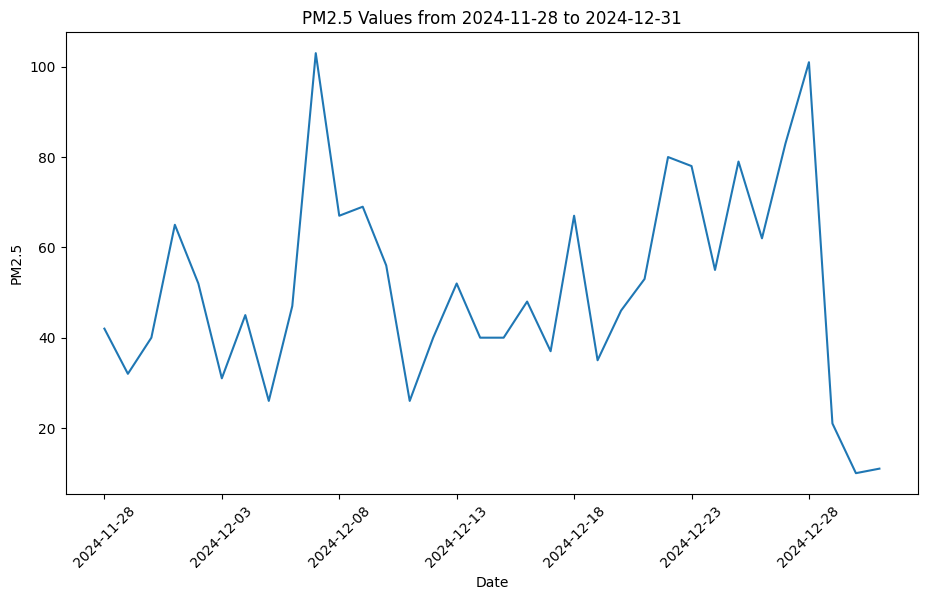

In [ ]:
# y_test pm2.5's values from 2024-11-28 to 2024-12-31
# data['pm25'].loc[ pd.to_datetime('2024-11-28').date() : pd.to_datetime('2024-12-31').date()]
plt.figure(figsize=(11, 6))
data['pm25'].loc['2024-11-28'  : '2024-12-31'].plot()
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.title('PM2.5 Values from 2024-11-28 to 2024-12-31')
plt.show()

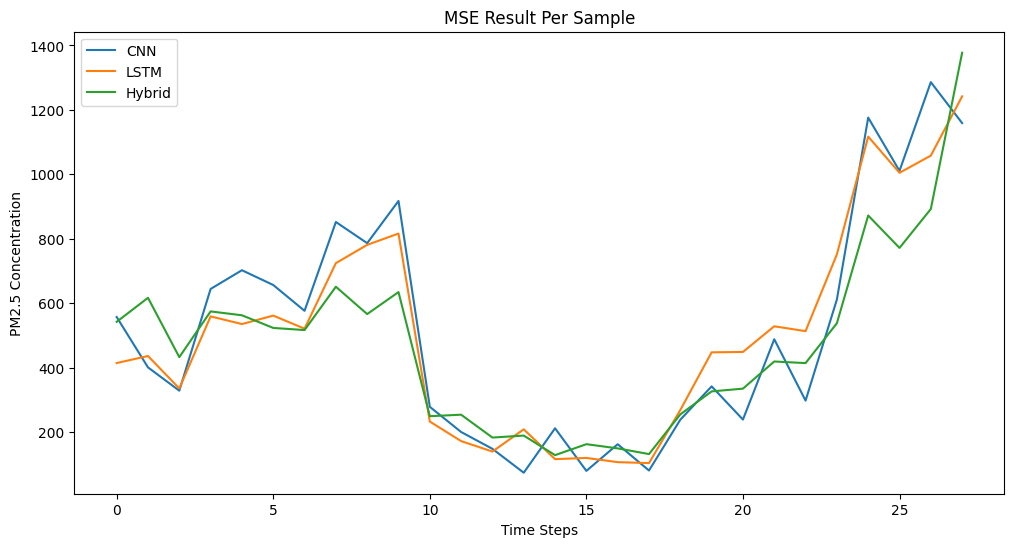

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(cnn_eval_per_sample['MSE'], label='CNN')
plt.plot(lstm_eval_per_sample['MSE'], label='LSTM')
plt.plot(hybrid_eval_per_sample['MSE'], label='Hybrid')
plt.title('MSE Result Per Sample')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.show()

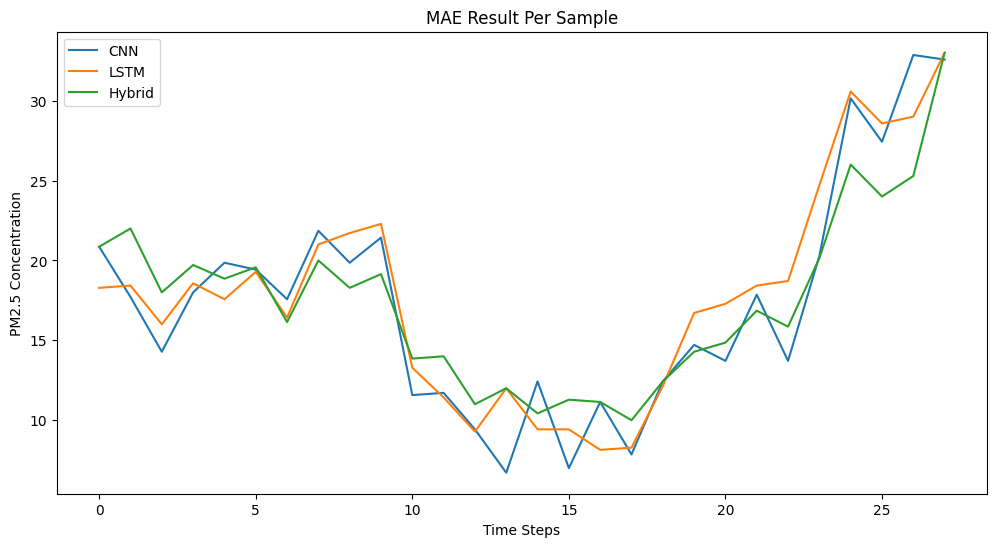

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(cnn_eval_per_sample['MAE'], label='CNN')
plt.plot(lstm_eval_per_sample['MAE'], label='LSTM')
plt.plot(hybrid_eval_per_sample['MAE'], label='Hybrid')
plt.title('MAE Result Per Sample')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.show()

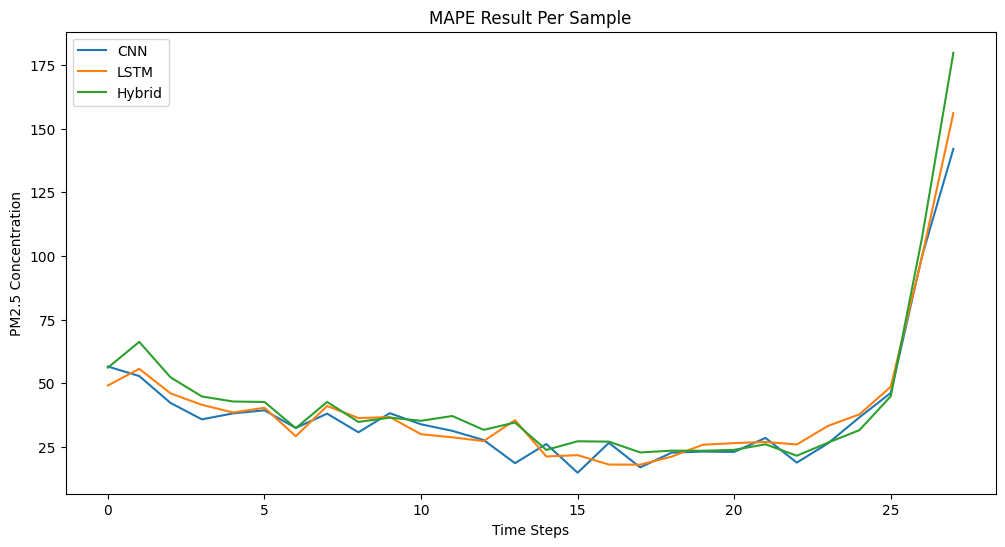

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(cnn_eval_per_sample['MAPE'], label='CNN')
plt.plot(lstm_eval_per_sample['MAPE'], label='LSTM')
plt.plot(hybrid_eval_per_sample['MAPE'], label='Hybrid')
plt.title('MAPE Result Per Sample')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.show()

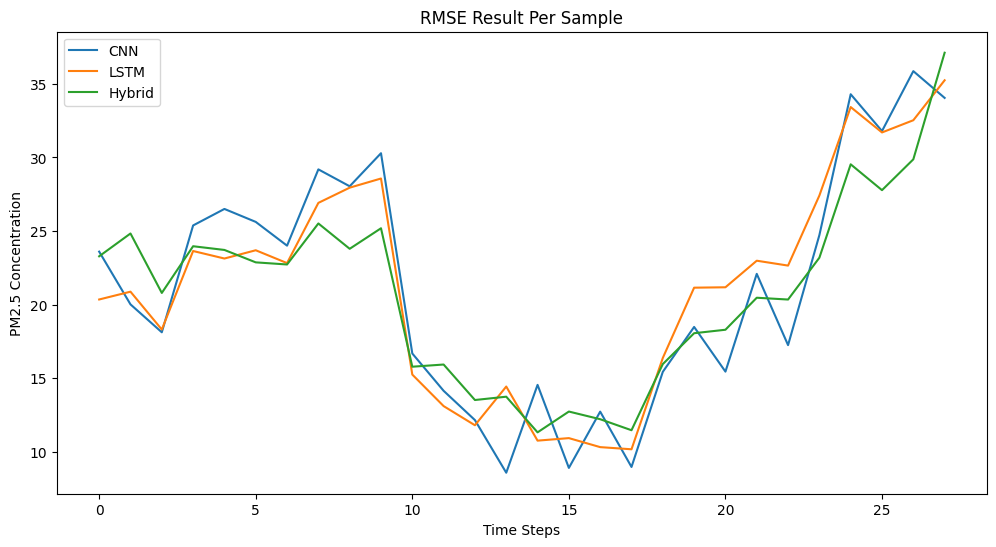

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(cnn_eval_per_sample['RMSE'], label='CNN')
plt.plot(lstm_eval_per_sample['RMSE'], label='LSTM')
plt.plot(hybrid_eval_per_sample['RMSE'], label='Hybrid')
plt.title('RMSE Result Per Sample')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.show()

# Plot CNN on test set per sample

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[0], label='Actual PM2.5')
plt.plot(y_pred_cnn[0], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 on Test Set with CNN (First Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[6], label='Actual PM2.5')
plt.plot(y_pred_cnn[6], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 over Test Set')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[13], label='Actual PM2.5')
plt.plot(y_pred_cnn[13], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 over Test Set with CNN (Middle Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[20], label='Actual PM2.5')
plt.plot(y_pred_cnn[20], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 over Test Set')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[27], label='Actual PM2.5')
plt.plot(y_pred_cnn[27], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 over Test Set with CNN (Last Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.show()

# Plot LSTM on test set per sample

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[0], label='Actual PM2.5')
plt.plot(y_pred_lstm[0], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 on Test Set with LSTM (First Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[13], label='Actual PM2.5')
plt.plot(y_pred_lstm[13], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 on Test Set with LSTM (Middle Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[27], label='Actual PM2.5')
plt.plot(y_pred_lstm[27], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 on Test Set with LSTM (Last Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

# Plot CNN-LSTM (Hybrid) on test set per sample

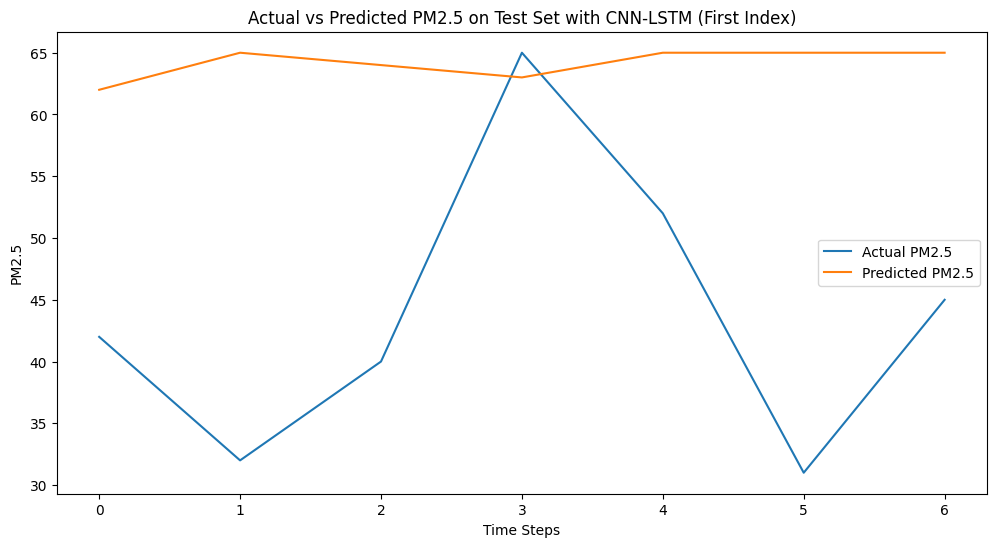

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[0], label='Actual PM2.5')
plt.plot(y_pred_hybrid[0], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 on Test Set with CNN-LSTM (First Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

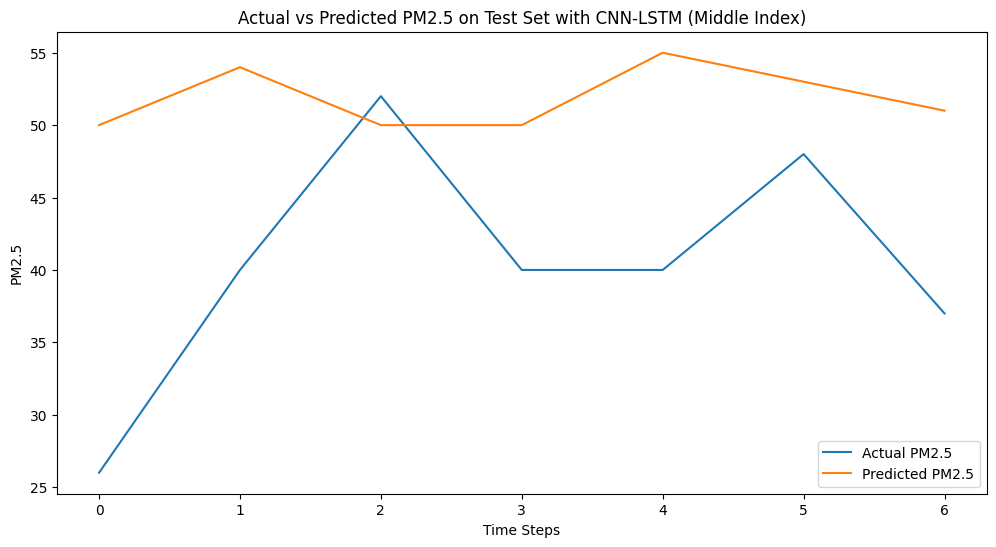

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[13], label='Actual PM2.5')
plt.plot(y_pred_hybrid[13], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 on Test Set with CNN-LSTM (Middle Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

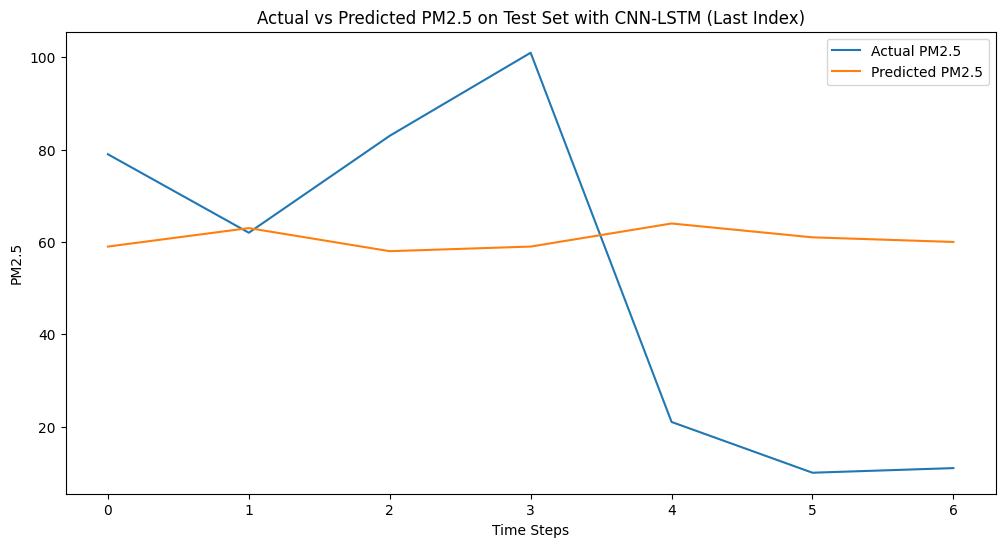

In [ ]:
# prompt: make visualization of y_test and y_pred
plt.figure(figsize=(12, 6))
plt.plot(inversed_y_test[27], label='Actual PM2.5')
plt.plot(y_pred_hybrid[27], label='Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 on Test Set with CNN-LSTM (Last Index)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

In [ ]:
inversed_y_test[24], y_pred_hybrid[24]

(array([ 80.,  78.,  55.,  79.,  62.,  83., 101.]),
 array([50., 53., 48., 50., 54., 51., 50.], dtype=float32))

In [ ]:
inversed_y_test[25], y_pred_hybrid[25]

(array([ 78.,  55.,  79.,  62.,  83., 101.,  21.]),
 array([53., 56., 51., 53., 57., 54., 53.], dtype=float32))

In [ ]:
inversed_y_test[26], y_pred_hybrid[26]

(array([ 55.,  79.,  62.,  83., 101.,  21.,  10.]),
 array([56., 60., 55., 56., 61., 57., 57.], dtype=float32))

In [ ]:
inversed_y_test[27], y_pred_hybrid[27]

(array([ 79.,  62.,  83., 101.,  21.,  10.,  11.]),
 array([59., 63., 58., 59., 64., 61., 60.], dtype=float32))